## Notebook con el proyecto final del grupo Condores

A lo largo de este notebook se desarrollarán análisis, exploración de información y datos, así como el modelo en Machine Learning para predecir las licitaciones futuras que se van a presentar en las licitaciones que realiza el gobierno de Chile mediante su sistema CHILECOMPRA, nuestro modelo lo hemos denominado ChileCompraEficiente

# Fase 1 - Analisis exploratorio de datos (EDA)

## DataFrame — Estados de licitación y etapas.
Esta información es fundamental para entender los diferentes estados en los que una licitación puede encontrarse, más adelante veremos que únicamente trabajaremos con licitaciones de un tipo en particular de estos.

In [181]:
# =========================================================
# CATALOGO OFICIAL ESTADOS DE LICITACION (CHILECOMPRA API)
# =========================================================

import pandas as pd

data_estados = {
    "CodigoEstado": [
        5, 6, 7, 8, 18, 19
    ],

    "Estado": [
        "Publicada",
        "Cerrada",
        "Desierta",
        "Adjudicada",
        "Revocada",
        "Suspendida"
    ],

    "Descripcion": [
        "Licitación publicada y abierta a recepción de ofertas",
        "Licitación cerrada (fin de recepción de ofertas)",
        "Licitación sin ofertas válidas",
        "Licitación adjudicada a un proveedor",
        "Licitación revocada por el organismo comprador",
        "Licitación suspendida temporalmente"
    ],

    # 👇 MUY IMPORTANTE PARA ANALITICA
    "GrupoEstado": [
        "Activa",
        "Cerrada",
        "Cerrada",
        "Cerrada",
        "Cerrada",
        "Activa"
    ]
}

df_estados_licitacion = pd.DataFrame(data_estados)

display(df_estados_licitacion)

,CodigoEstado,Estado,Descripcion,GrupoEstado
0,5,Publicada,Licitación publicada y abierta a recepción de ...,Activa
1,6,Cerrada,Licitación cerrada (fin de recepción de ofertas),Cerrada
2,7,Desierta,Licitación sin ofertas válidas,Cerrada
3,8,Adjudicada,Licitación adjudicada a un proveedor,Cerrada
4,18,Revocada,Licitación revocada por el organismo comprador,Cerrada
5,19,Suspendida,Licitación suspendida temporalmente,Activa


## Tipos de Licitación

Es complementaria al estado y nos indica los diferentes tipos de licitaciones que pueden existir, igual es relevante esta información porque más adelante trabajaremos únicamente con un tipo de licitación en particular.

In [182]:
# =========================================================
# CATALOGO OFICIAL TIPOS DE LICITACION (CHILECOMPRA)
# =========================================================

import pandas as pd

data_tipos = {
    "codigo_tipo": [
        "L1", "LE", "LP", "LQ", "LR",
        "E2", "CO", "B2", "H2", "I2",
        "LS"
    ],

    "tipo_licitacion": [
        "Licitación Pública Menor a 100 UTM",
        "Licitación Pública entre 100 y 1.000 UTM",
        "Licitación Pública entre 1.000 y 2.000 UTM",
        "Licitación Pública entre 2.000 y 5.000 UTM",
        "Licitación Pública Mayor a 5.000 UTM",
        "Licitación Privada Menor a 100 UTM",
        "Licitación Privada entre 100 y 1.000 UTM",
        "Licitación Privada entre 1.000 y 2.000 UTM",
        "Licitación Privada entre 2.000 y 5.000 UTM",
        "Licitación Privada Mayor a 5.000 UTM",
        "Licitación Servicios Personales Especializados"
    ],

    # 👇 CLAVE PARA TU PROYECTO
    "tipo_base": [
        "Publica","Publica","Publica","Publica","Publica",
        "Privada","Privada","Privada","Privada","Privada",
        "Especial"
    ],

    # 👇 SEGMENTACIÓN POR MONTO (MUY UTIL PARA ML)
    "rango_monto": [
        "<100 UTM",
        "100-1000 UTM",
        "1000-2000 UTM",
        "2000-5000 UTM",
        ">5000 UTM",
        "<100 UTM",
        "100-1000 UTM",
        "1000-2000 UTM",
        "2000-5000 UTM",
        ">5000 UTM",
        "N/A"
    ]
}

df_tipos_licitacion = pd.DataFrame(data_tipos)

display(df_tipos_licitacion)

,codigo_tipo,tipo_licitacion,tipo_base,rango_monto
0,L1,Licitación Pública Menor a 100 UTM,Publica,<100 UTM
1,LE,Licitación Pública entre 100 y 1.000 UTM,Publica,100-1000 UTM
2,LP,Licitación Pública entre 1.000 y 2.000 UTM,Publica,1000-2000 UTM
3,LQ,Licitación Pública entre 2.000 y 5.000 UTM,Publica,2000-5000 UTM
4,LR,Licitación Pública Mayor a 5.000 UTM,Publica,>5000 UTM
5,E2,Licitación Privada Menor a 100 UTM,Privada,<100 UTM
6,CO,Licitación Privada entre 100 y 1.000 UTM,Privada,100-1000 UTM
7,B2,Licitación Privada entre 1.000 y 2.000 UTM,Privada,1000-2000 UTM
8,H2,Licitación Privada entre 2.000 y 5.000 UTM,Privada,2000-5000 UTM
9,I2,Licitación Privada Mayor a 5.000 UTM,Privada,>5000 UTM


## 📦 Código — Paso 1: Carga dataset

Lectura de la información
Como las fuentes de datos son bastante pesadas
    Licitaciones 42.3MB
se toma la decisión de subir las fuentes a google Drive y desde allí gestionar los permisos de descarga de la información

In [183]:
import os
import requests
import pandas as pd

# Tu nuevo ID de archivo
FILE_ID = '11fA5-HKOX0YmWflZdRFmuK7wKrzX1f05'
URL = f'https://drive.google.com/uc?export=download&id={FILE_ID}'
NOMBRE_LOCAL = 'licitaciones_final.parquet'

print("--- DESCARGANDO DESDE TU DRIVE ---")

try:
    # Descarga directa
    response = requests.get(URL, stream=True)
    with open(NOMBRE_LOCAL, "wb") as f:
        for chunk in response.iter_content(chunk_size=32768):
            if chunk: f.write(chunk)

    # Verificación de integridad
    peso_mb = os.path.getsize(NOMBRE_LOCAL) / (1024 * 1024)
    print(f"Archivo descargado: {peso_mb:.2f} MB")

    if peso_mb > 1.0:
        df_licitaciones = pd.read_parquet(NOMBRE_LOCAL, engine='pyarrow')
        print(f"¡ÉXITO! Licitaciones cargadas: {df_licitaciones.shape} filas.")
        display(df_licitaciones.head())
    else:
        print("El archivo sigue siendo demasiado pequeño. Revisa que el permiso sea 'Cualquier persona con el enlace'.")

except Exception as e:
    print(f"Error: {e}")


--- DESCARGANDO DESDE TU DRIVE ---
Archivo descargado: 42.33 MB
¡ÉXITO! Licitaciones cargadas: (826238, 4) filas.


,CodigoExterno,Nombre,CodigoEstado,FechaCierre
0,564162-187-L119,(id.48430) Particulas para Depto de Física,7,2020-01-01T17:04:01.527
1,1058134-381-L119,Medicamentos Enero 2020,7,2020-01-01T15:04:01.643
2,1663-111-L119,SERVICIO DE LABORATORIO DENTAL PARA PRÓTESIS M...,7,2020-01-01T21:44:01.157
3,2713-290-L119,CLASES DIRIGIDAS,7,2020-01-01T19:29:01.22
4,1058133-15-LR19,Convenio de Suministro Farmacos Inyectables Red,8,2019-11-04T15:01:00


In [184]:
# Columnas del dataset
print("\n==============================")
print("COLUMNAS")
print("==============================")

print(df_licitaciones.columns.tolist())


COLUMNAS
['CodigoExterno', 'Nombre', 'CodigoEstado', 'FechaCierre']


In [185]:
# Tipos de datos

print("\n==============================")
print("TIPOS DE DATOS")
print("==============================")

display(df_licitaciones.dtypes)


TIPOS DE DATOS


,0
CodigoExterno,object
Nombre,object
CodigoEstado,int64
FechaCierre,object


In [186]:
# Información general del Dataset

df_licitaciones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 826238 entries, 0 to 826237
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   CodigoExterno  826238 non-null  object
 1   Nombre         826238 non-null  object
 2   CodigoEstado   826238 non-null  int64 
 3   FechaCierre    826237 non-null  object
dtypes: int64(1), object(3)
memory usage: 25.2+ MB


In [187]:
# Valores nulos por columna

nulls = df_licitaciones.isnull().sum().sort_values(ascending=False)

display(nulls.head(20))

,0
FechaCierre,1
CodigoExterno,0
Nombre,0
CodigoEstado,0


In [188]:
# Registros duplicados

duplicados = df_licitaciones.duplicated().sum()

print("Total duplicados:", duplicados)


Total duplicados: 0


In [189]:
# Uso de memoria

memoria = df_licitaciones.memory_usage(deep=True).sum() / 1024**2

print(f"Memoria utilizada: {memoria:.2f} MB")

Memoria utilizada: 228.47 MB


In [190]:
# Último vistazo al dataframe

df_licitaciones.head()

,CodigoExterno,Nombre,CodigoEstado,FechaCierre
0,564162-187-L119,(id.48430) Particulas para Depto de Física,7,2020-01-01T17:04:01.527
1,1058134-381-L119,Medicamentos Enero 2020,7,2020-01-01T15:04:01.643
2,1663-111-L119,SERVICIO DE LABORATORIO DENTAL PARA PRÓTESIS M...,7,2020-01-01T21:44:01.157
3,2713-290-L119,CLASES DIRIGIDAS,7,2020-01-01T19:29:01.22
4,1058133-15-LR19,Convenio de Suministro Farmacos Inyectables Red,8,2019-11-04T15:01:00


## 📦 Código — Paso 2: Embudo Licitaciones.

Este paso es fundamental en nuestro proyecto ya que únicamente vamos a trabajar con licitaciones de tipo ***"adjudicadas"*** que en el campo CodigoEstado corresponden al estado número 8

In [191]:
# Filtrar licitaciones adjudicadas

df_licitaciones_adjudicadas = df_licitaciones[
    df_licitaciones["CodigoEstado"] == 8
].copy()

print("Total licitaciones adjudicadas:", len(df_licitaciones_adjudicadas))

display(df_licitaciones_adjudicadas.head())

Total licitaciones adjudicadas: 604561


,CodigoExterno,Nombre,CodigoEstado,FechaCierre
4,1058133-15-LR19,Convenio de Suministro Farmacos Inyectables Red,8,2019-11-04T15:01:00
5,1058133-19-LR19,Conv.Sum Farmacos trastornos Cardiovasculares RED,8,2019-11-11T15:01:00
8,1523-97-LP19,Propuesta Pública Nº 101/19 “SUMINISTRO DE INS...,8,2019-12-02T15:30:00
9,2097-88-LE19,MEDICAMENTO SOLICITUD DE COMPRA SIABI N 4270 -...,8,2019-12-12T16:00:00
13,2436-575-LE19,Contrato de Suministro Servicio de arriendo am...,8,2019-12-26T16:00:00


In [192]:
df_licitaciones_adjudicadas.info()

<class 'pandas.core.frame.DataFrame'>
Index: 604561 entries, 4 to 826237
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   CodigoExterno  604561 non-null  object
 1   Nombre         604561 non-null  object
 2   CodigoEstado   604561 non-null  int64 
 3   FechaCierre    604561 non-null  object
dtypes: int64(1), object(3)
memory usage: 23.1+ MB


El siguiente paso consiste en descomponer el CodigoExterno, el cual internamente contiene información relevante y necesaria

In [193]:
# =========================================================
# DESCOMPONER CodigoExterno COMPLETO
# =========================================================

df = df_licitaciones_adjudicadas.copy()

# separar partes
df[["codigo_organismo", "correlativo", "tipo_anio"]] = (
    df["CodigoExterno"].str.split("-", expand=True)
)

# tipo
df["codigo_tipo"] = df["tipo_anio"].str.replace(r"\d+", "", regex=True)

# año
df["anio_licitacion"] = df["tipo_anio"].str.extract(r"(\d+)").astype('Int64') # Changed to 'Int64' to handle NaN values

display(df.head())

,CodigoExterno,Nombre,CodigoEstado,FechaCierre,codigo_organismo,correlativo,tipo_anio,codigo_tipo,anio_licitacion
4,1058133-15-LR19,Convenio de Suministro Farmacos Inyectables Red,8,2019-11-04T15:01:00,1058133,15,LR19,LR,19
5,1058133-19-LR19,Conv.Sum Farmacos trastornos Cardiovasculares RED,8,2019-11-11T15:01:00,1058133,19,LR19,LR,19
8,1523-97-LP19,Propuesta Pública Nº 101/19 “SUMINISTRO DE INS...,8,2019-12-02T15:30:00,1523,97,LP19,LP,19
9,2097-88-LE19,MEDICAMENTO SOLICITUD DE COMPRA SIABI N 4270 -...,8,2019-12-12T16:00:00,2097,88,LE19,LE,19
13,2436-575-LE19,Contrato de Suministro Servicio de arriendo am...,8,2019-12-26T16:00:00,2436,575,LE19,LE,19


In [194]:
# Verificamos que con la descomposición no hayamos perdidos registros

df["CodigoEstado"].value_counts()

,count
CodigoEstado,
8,604561


In [195]:
# =========================================================
# EXTRAER CODIGO TIPO CORRECTAMENTE
# =========================================================

df["tipo_raw"] = df["CodigoExterno"].str.split("-").str[-1]

# tomar SOLO los primeros 2 caracteres
df["codigo_tipo"] = df["tipo_raw"].str[:2]

display(df[["CodigoExterno", "tipo_raw", "codigo_tipo"]].head())

,CodigoExterno,tipo_raw,codigo_tipo
4,1058133-15-LR19,LR19,LR
5,1058133-19-LR19,LR19,LR
8,1523-97-LP19,LP19,LP
9,2097-88-LE19,LE19,LE
13,2436-575-LE19,LE19,LE


Luego revisamos los tipos de licitaciones que más cantidad de adjudicaciones tuvieron, este ranking es clave porque nos permite visualizar las ordenes con la que más adelante trabajaremos

In [196]:
# Ranging por tipo de licitación

ranking_tipos = (
    df.groupby("codigo_tipo")
    .size()
    .reset_index(name="cantidad_adjudicadas")
    .sort_values(by="cantidad_adjudicadas", ascending=False)
    .reset_index(drop=True)
)

ranking_tipos["ranking"] = ranking_tipos.index + 1

display(ranking_tipos)

print("Suma total:", ranking_tipos["cantidad_adjudicadas"].sum())

,codigo_tipo,cantidad_adjudicadas,ranking
0,LE,266632,1
1,L1,199890,2
2,LP,44798,3
3,LQ,44144,4
4,LR,24585,5
5,R1,13293,6
6,O1,6181,7
7,CO,2378,8
8,E2,842,9
9,R2,581,10


Suma total: 604561


In [197]:
# Recordemos el df de los tipos de licitaciones
df_tipos_licitacion.head()

,codigo_tipo,tipo_licitacion,tipo_base,rango_monto
0,L1,Licitación Pública Menor a 100 UTM,Publica,<100 UTM
1,LE,Licitación Pública entre 100 y 1.000 UTM,Publica,100-1000 UTM
2,LP,Licitación Pública entre 1.000 y 2.000 UTM,Publica,1000-2000 UTM
3,LQ,Licitación Pública entre 2.000 y 5.000 UTM,Publica,2000-5000 UTM
4,LR,Licitación Pública Mayor a 5.000 UTM,Publica,>5000 UTM


Vamos a agregar un clasificación adicional a las licitaciones, si son públicas, privadas o especiales

In [198]:
# =========================================================
# AGREGAR TIPO BASE (PUBLICA / PRIVADA / ESPECIAL)
# =========================================================

# Clean up potentially existing suffixed columns from previous runs
columns_to_drop = [col for col in ['tipo_base_x', 'tipo_base_y', 'tipo_base'] if col in df.columns]
if columns_to_drop:
    df = df.drop(columns=columns_to_drop)

df = df.merge(
    df_tipos_licitacion[["codigo_tipo", "tipo_base"]],
    on="codigo_tipo",
    how="left"
)

In [199]:
display(df.head())

,CodigoExterno,Nombre,CodigoEstado,FechaCierre,codigo_organismo,correlativo,tipo_anio,codigo_tipo,anio_licitacion,tipo_raw,tipo_base
0,1058133-15-LR19,Convenio de Suministro Farmacos Inyectables Red,8,2019-11-04T15:01:00,1058133,15,LR19,LR,19,LR19,Publica
1,1058133-19-LR19,Conv.Sum Farmacos trastornos Cardiovasculares RED,8,2019-11-11T15:01:00,1058133,19,LR19,LR,19,LR19,Publica
2,1523-97-LP19,Propuesta Pública Nº 101/19 “SUMINISTRO DE INS...,8,2019-12-02T15:30:00,1523,97,LP19,LP,19,LP19,Publica
3,2097-88-LE19,MEDICAMENTO SOLICITUD DE COMPRA SIABI N 4270 -...,8,2019-12-12T16:00:00,2097,88,LE19,LE,19,LE19,Publica
4,2436-575-LE19,Contrato de Suministro Servicio de arriendo am...,8,2019-12-26T16:00:00,2436,575,LE19,LE,19,LE19,Publica


Con esta nueva clasificación vamos a revisar cuales tipos (pública, privada, especial) de licitación son las que más se realizan

In [200]:
# =========================================================
# PORCENTAJE DE CADA TIPO DE BASE
# =========================================================

tabla_tipo_base = (
    df
    .groupby("tipo_base")
    .size()
    .reset_index(name="cantidad_licitaciones")
)

total_licitaciones = tabla_tipo_base["cantidad_licitaciones"].sum()

tabla_tipo_base["porcentaje"] = (
    tabla_tipo_base["cantidad_licitaciones"] / total_licitaciones * 100
)

tabla_tipo_base = tabla_tipo_base.sort_values("cantidad_licitaciones", ascending=False).reset_index(drop=True)

display(tabla_tipo_base)

,tipo_base,cantidad_licitaciones,porcentaje
0,Publica,580049,99.259212
1,Privada,4220,0.722135
2,Especial,109,0.018652


El resultado es contundente en que las liciaciones publicas representan el 99.2% del total de licitaciones, por lo tanto, únicamente seguiremos trabajando con las "Publicas"

In [201]:
# =========================================================
# FILTRAR DATAFRAME POR TIPO DE BASE 'PUBLICAS'
# =========================================================

df_publicas = df[df["tipo_base"] == "Publica"].copy()

print("Total de licitaciones públicas:", len(df_publicas))
display(df_publicas.head())

Total de licitaciones públicas: 580049


,CodigoExterno,Nombre,CodigoEstado,FechaCierre,codigo_organismo,correlativo,tipo_anio,codigo_tipo,anio_licitacion,tipo_raw,tipo_base
0,1058133-15-LR19,Convenio de Suministro Farmacos Inyectables Red,8,2019-11-04T15:01:00,1058133,15,LR19,LR,19,LR19,Publica
1,1058133-19-LR19,Conv.Sum Farmacos trastornos Cardiovasculares RED,8,2019-11-11T15:01:00,1058133,19,LR19,LR,19,LR19,Publica
2,1523-97-LP19,Propuesta Pública Nº 101/19 “SUMINISTRO DE INS...,8,2019-12-02T15:30:00,1523,97,LP19,LP,19,LP19,Publica
3,2097-88-LE19,MEDICAMENTO SOLICITUD DE COMPRA SIABI N 4270 -...,8,2019-12-12T16:00:00,2097,88,LE19,LE,19,LE19,Publica
4,2436-575-LE19,Contrato de Suministro Servicio de arriendo am...,8,2019-12-26T16:00:00,2436,575,LE19,LE,19,LE19,Publica


In [202]:
df_publicas.info()

<class 'pandas.core.frame.DataFrame'>
Index: 580049 entries, 0 to 604559
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   CodigoExterno     580049 non-null  object
 1   Nombre            580049 non-null  object
 2   CodigoEstado      580049 non-null  int64 
 3   FechaCierre       580049 non-null  object
 4   codigo_organismo  580049 non-null  object
 5   correlativo       580049 non-null  object
 6   tipo_anio         580049 non-null  object
 7   codigo_tipo       580049 non-null  object
 8   anio_licitacion   580049 non-null  Int64 
 9   tipo_raw          580049 non-null  object
 10  tipo_base         580049 non-null  object
dtypes: Int64(1), int64(1), object(9)
memory usage: 53.7+ MB


Teniendo únicamente licitaciones públicas, ahora revisaremos el tipo "codigo_tipo" las cuales tienen que ver con el monto licitado "UTM"

In [203]:
# =========================================================
# PARTICIPACION (%) POR CODIGO_TIPO
# =========================================================

participacion_tipos = (
    df_publicas
    .groupby("codigo_tipo")
    .size()
    .reset_index(name="cantidad")
)

# Total
total = participacion_tipos["cantidad"].sum()

# Calcular %
participacion_tipos["participacion_%"] = (
    participacion_tipos["cantidad"] / total * 100
)

# Ordenar
participacion_tipos = participacion_tipos.sort_values(
    by="participacion_%", ascending=False
).reset_index(drop=True)

display(participacion_tipos)

,codigo_tipo,cantidad,participacion_%
0,LE,266632,45.967151
1,L1,199890,34.460882
2,LP,44798,7.723141
3,LQ,44144,7.610392
4,LR,24585,4.238435


Las licitaciones de tipo LE corresponden a: "Licitación Pública entre 100 y 1.000 UTM", como se ve representan el 46% del total de licitaciones, por lo que decidimos continuar trabajando con este tipo de licitaciones.

In [204]:
# =========================================================
# FILTRAR LE + AÑO ENTRE 20 Y 25
# =========================================================

df_publicas_le = df_publicas[
    (df_publicas["codigo_tipo"] == "LE") &
    (df_publicas["anio_licitacion"] >= 20) &
    (df_publicas["anio_licitacion"] <= 25)
].copy()

print("Total de licitaciones públicas tipo 'LE' (2020-2025):", len(df_publicas_le))
display(df_publicas_le.head())

Total de licitaciones públicas tipo 'LE' (2020-2025): 263454


,CodigoExterno,Nombre,CodigoEstado,FechaCierre,codigo_organismo,correlativo,tipo_anio,codigo_tipo,anio_licitacion,tipo_raw,tipo_base
1442,3568-2-LE20,CONVENIO SUMINISTRO DE MATERIALES DE FERRETERIA,8,2020-01-08T09:05:00,3568,2,LE20,LE,20,LE20,Publica
1481,525512-3-LE20,ADQUISICIÓN DE INSUMOS PARA PROGRAMA MUNICIPAL,8,2020-01-09T10:01:00,525512,3,LE20,LE,20,LE20,Publica
1700,3293-3-LE20,Administración Red Eléctrica Municipal Chaitén...,8,2020-01-08T09:00:00,3293,3,LE20,LE,20,LE20,Publica
1857,3796-1-LE20,Ferias Costumbristas verano 2020,8,2020-01-08T15:00:00,3796,1,LE20,LE,20,LE20,Publica
1905,525512-2-LE20,SERVICIO Y PRODUCCIÓN DE EVENTOS PARA PROGRAMA...,8,2020-01-09T20:00:00,525512,2,LE20,LE,20,LE20,Publica


In [205]:
df_publicas_le.info()

<class 'pandas.core.frame.DataFrame'>
Index: 263454 entries, 1442 to 604559
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   CodigoExterno     263454 non-null  object
 1   Nombre            263454 non-null  object
 2   CodigoEstado      263454 non-null  int64 
 3   FechaCierre       263454 non-null  object
 4   codigo_organismo  263454 non-null  object
 5   correlativo       263454 non-null  object
 6   tipo_anio         263454 non-null  object
 7   codigo_tipo       263454 non-null  object
 8   anio_licitacion   263454 non-null  Int64 
 9   tipo_raw          263454 non-null  object
 10  tipo_base         263454 non-null  object
dtypes: Int64(1), int64(1), object(9)
memory usage: 24.4+ MB


## 📦 Código — Paso 3: Analisis de Organismos.

In [206]:
df_publicas_le.head()

,CodigoExterno,Nombre,CodigoEstado,FechaCierre,codigo_organismo,correlativo,tipo_anio,codigo_tipo,anio_licitacion,tipo_raw,tipo_base
1442,3568-2-LE20,CONVENIO SUMINISTRO DE MATERIALES DE FERRETERIA,8,2020-01-08T09:05:00,3568,2,LE20,LE,20,LE20,Publica
1481,525512-3-LE20,ADQUISICIÓN DE INSUMOS PARA PROGRAMA MUNICIPAL,8,2020-01-09T10:01:00,525512,3,LE20,LE,20,LE20,Publica
1700,3293-3-LE20,Administración Red Eléctrica Municipal Chaitén...,8,2020-01-08T09:00:00,3293,3,LE20,LE,20,LE20,Publica
1857,3796-1-LE20,Ferias Costumbristas verano 2020,8,2020-01-08T15:00:00,3796,1,LE20,LE,20,LE20,Publica
1905,525512-2-LE20,SERVICIO Y PRODUCCIÓN DE EVENTOS PARA PROGRAMA...,8,2020-01-09T20:00:00,525512,2,LE20,LE,20,LE20,Publica


In [207]:
df_publicas_le.info()

<class 'pandas.core.frame.DataFrame'>
Index: 263454 entries, 1442 to 604559
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   CodigoExterno     263454 non-null  object
 1   Nombre            263454 non-null  object
 2   CodigoEstado      263454 non-null  int64 
 3   FechaCierre       263454 non-null  object
 4   codigo_organismo  263454 non-null  object
 5   correlativo       263454 non-null  object
 6   tipo_anio         263454 non-null  object
 7   codigo_tipo       263454 non-null  object
 8   anio_licitacion   263454 non-null  Int64 
 9   tipo_raw          263454 non-null  object
 10  tipo_base         263454 non-null  object
dtypes: Int64(1), int64(1), object(9)
memory usage: 24.4+ MB


Verificamos que los datos únicamente tengan licitaciones públicas y de tipo "LE"

In [208]:
print(df_publicas_le['codigo_tipo'].unique())
print(df_publicas_le['tipo_base'].unique())

['LE']
['Publica']


Contamos el número de organismos distintos.

In [209]:
conteo_org = df_publicas_le.groupby('codigo_organismo')['CodigoExterno'].count()
conteo_org.head()

,CodigoExterno
codigo_organismo,
1000,164
1000813,128
1001,125
1001048,14
1001546,10


In [210]:
conteo_org.info()


<class 'pandas.core.series.Series'>
Index: 4683 entries, 1000 to 999
Series name: CodigoExterno
Non-Null Count  Dtype
--------------  -----
4683 non-null   int64
dtypes: int64(1)
memory usage: 73.2+ KB


Filtramos los organismos con licitaciones de 150 a más entre el 2020 y 2025.

In [211]:
org_validos = conteo_org[conteo_org >= 150].index
print (f"Existe en total {org_validos.nunique()} organismos con 150 a más licitaciones.")

Existe en total 451 organismos con 150 a más licitaciones.


In [212]:
# Aplicamos el filtro SOBRE EL MISMO DATASET
df_filtrado = df_publicas_le[
    df_publicas_le['codigo_organismo'].isin(org_validos)
].copy()

En el siguiente script se presenta de manera resumida como la cantidad de registros la vamos reduciendo de acuerdo con los diferentes filtros y segmentos que hemos ido definiendo.

In [213]:
print("Total de licitaciones adjudicadas inicialmente:", len(df_licitaciones_adjudicadas))
print("Total de licitaciones después de procesar (df):", len(df))
print("Total de licitaciones después de procesar Públicas:", len(df_publicas))
print("Total de licitaciones después de procesar Públicas + LE + rango 2020 al 2025:", len(df_publicas_le))

print("="*85)

print("Total de licitaciones con un mínimo de 150 licitaciones presentadas:", len(df_filtrado))
print("Total organismos válidos:", len(org_validos))


Total de licitaciones adjudicadas inicialmente: 604561
Total de licitaciones después de procesar (df): 604561
Total de licitaciones después de procesar Públicas: 580049
Total de licitaciones después de procesar Públicas + LE + rango 2020 al 2025: 263454
Total de licitaciones con un mínimo de 150 licitaciones presentadas: 128849
Total organismos válidos: 451


Actualizamos la data filtrada para quedarnos solo con los 451 organismos.

In [214]:
org_validos = conteo_org[conteo_org >= 150].index
df_filtrado = df_publicas_le[df_publicas_le['codigo_organismo'].isin(org_validos)]

In [215]:
df_filtrado.head()

,CodigoExterno,Nombre,CodigoEstado,FechaCierre,codigo_organismo,correlativo,tipo_anio,codigo_tipo,anio_licitacion,tipo_raw,tipo_base
2180,2345-3-LE20,ARRIENDO BUSES PARA TRASLADOS HACIA IX REGION,8,2020-01-08T17:10:00,2345,3,LE20,LE,20,LE20,Publica
2188,4993-1-LE20,CONVENIO SUMINISTRO SERVICIO DE MANTENCION Y R...,8,2020-01-10T15:00:00,4993,1,LE20,LE,20,LE20,Publica
2236,4414-1-LE20,JUEGOS INFLABLES Y ACUATICOS VERANO 2020,8,2020-01-13T15:00:00,4414,1,LE20,LE,20,LE20,Publica
2242,1464-1-LE20,Laboratorio 2020,8,2020-01-10T12:25:00,1464,1,LE20,LE,20,LE20,Publica
2289,3794-3-LE20,PASAJES AEREOS EN EL TRAMO ISLA ROBINSON CRUSO...,8,2020-01-13T15:00:00,3794,3,LE20,LE,20,LE20,Publica


Finalmente decidimos trabajar con los organismos que tuvieran mínimamente 150 licitaciones en el periodo 2020-2025, consideramos que son los datos y organismos que valen la pena analizar y modelar. De esta segmentción llegamos al resultado que son 451 organismos los que cumplen esta condición.

In [216]:
print("Shape df_filtrado:", df_filtrado.shape)
print("Tipo dataset:", "df_publicas_le")

Shape df_filtrado: (128849, 11)
Tipo dataset: df_publicas_le


In [217]:
print("Total organismos válidos:", len(org_validos))
print("Total registros filtrados:", len(df_filtrado))

# Validar mínimo real
check = df_filtrado['codigo_organismo'].value_counts().min()
print("Mínimo licitaciones por organismo:", check)

Total organismos válidos: 451
Total registros filtrados: 128849
Mínimo licitaciones por organismo: 150


In [218]:
df_filtrado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 128849 entries, 2180 to 604557
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   CodigoExterno     128849 non-null  object
 1   Nombre            128849 non-null  object
 2   CodigoEstado      128849 non-null  int64 
 3   FechaCierre       128849 non-null  object
 4   codigo_organismo  128849 non-null  object
 5   correlativo       128849 non-null  object
 6   tipo_anio         128849 non-null  object
 7   codigo_tipo       128849 non-null  object
 8   anio_licitacion   128849 non-null  Int64 
 9   tipo_raw          128849 non-null  object
 10  tipo_base         128849 non-null  object
dtypes: Int64(1), int64(1), object(9)
memory usage: 11.9+ MB


In [219]:
# =========================================================
# RANKING DE ORGANISMOS POR CANTIDAD DE LICITACIONES
# =========================================================

# Paso 1: Agrupar por organismo y contar licitaciones
df_ranking = (
    df_filtrado
    .groupby('codigo_organismo')
    .size()
    .reset_index(name='cantidad_licitaciones')
)

# Paso 2: Ordenar de mayor a menor
df_ranking = df_ranking.sort_values(by='cantidad_licitaciones', ascending=False)

# Paso 3: Crear ranking (manejo de empates tipo "dense")
df_ranking['ranking'] = (
    df_ranking['cantidad_licitaciones']
    .rank(method='dense', ascending=False)
    .astype(int)
)

# Paso 4: Calcular percentil (útil para segmentación futura)
df_ranking['percentil'] = (
    df_ranking['cantidad_licitaciones']
    .rank(pct=True)
)

# Paso 5: Orden final y selección de columnas
df_ranking = df_ranking[
    ['ranking', 'codigo_organismo', 'cantidad_licitaciones', 'percentil']
].sort_values(by='ranking')

# Mostrar resultado
display(df_ranking.head(20))

,ranking,codigo_organismo,cantidad_licitaciones,percentil
43,1,1075963,1570,1.000000
17,2,1057489,1369,0.997783
414,3,729,1198,0.995565
23,4,1057501,1176,0.993348
8,5,1057049,973,0.991131
392,6,5586,967,0.988914
36,7,1057547,963,0.986696
97,8,1725,941,0.984479
111,9,2080,891,0.982262
94,10,1658,882,0.980044


### A continuación realizaremos un análisis gráfico que ayuda a comprender mejor los datos y hacen parte del EDA.

In [220]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aseguramos que sea un objeto independiente en memoria
df_filtrado = df_filtrado.copy()

# Ahora la conversión no dará error
df_filtrado['FechaCierre'] = pd.to_datetime(df_filtrado['FechaCierre'])


/tmp/ipykernel_118711/3187709086.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(x=totales_anio.index, y=totales_anio.values, palette='viridis')


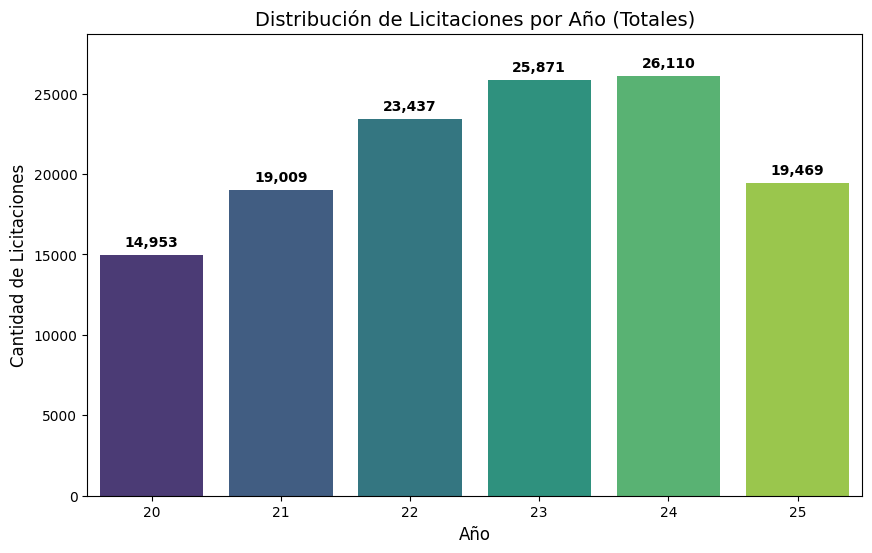

In [221]:
# 1. Agrupar los datos para tener los totales exactos
totales_anio = df_filtrado['anio_licitacion'].value_counts().sort_index()

# 2. Crear el gráfico
plt.figure(figsize=(10, 6))
plot = sns.barplot(x=totales_anio.index, y=totales_anio.values, palette='viridis')

# 3. AÑADIR LAS ETIQUETAS SOBRE LAS BARRAS
for p in plot.patches:
    plot.annotate(format(p.get_height(), ',.0f'), # Formato con separador de miles
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points',
                   fontsize=10, fontweight='bold')

# 4. Estética del gráfico
plt.title('Distribución de Licitaciones por Año (Totales)', fontsize=14)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Cantidad de Licitaciones', fontsize=12)
plt.ylim(0, totales_anio.max() * 1.1) # Damos espacio arriba para las etiquetas
plt.show()


/tmp/ipykernel_118711/2079823751.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=meses_nombres, y=conteo_mensual.values, palette='coolwarm')


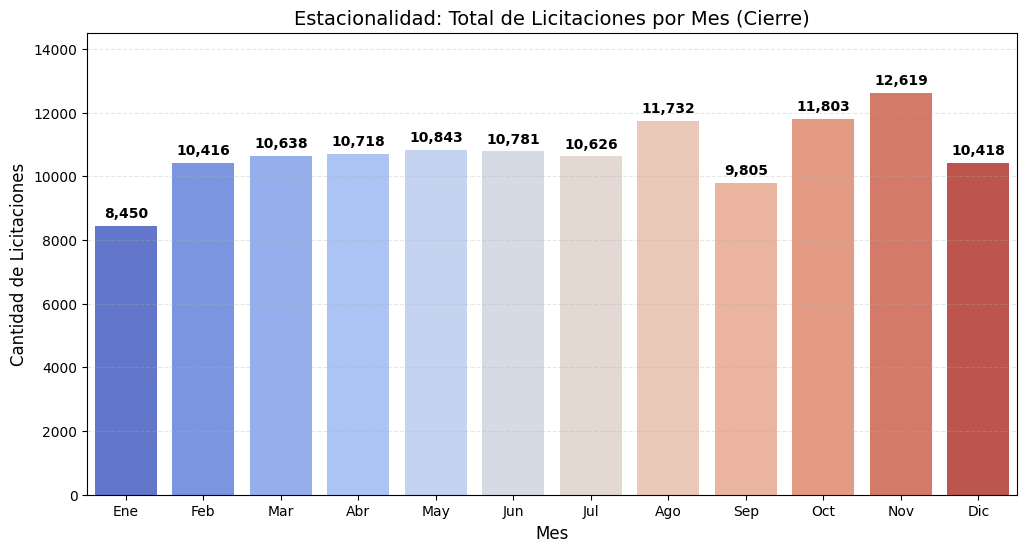

In [222]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Convertir FechaCierre a datetime (si aún no lo está)
fechas = pd.to_datetime(df_filtrado['FechaCierre'])

# 2. Contar por mes (del 1 al 12)
conteo_mensual = fechas.dt.month.value_counts().sort_index()
conteo_mensual = conteo_mensual.reindex(range(1, 13), fill_value=0)

# 3. Graficar
meses_nombres = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=meses_nombres, y=conteo_mensual.values, palette='coolwarm')

# Etiquetas de datos
for p in ax.patches:
    ax.annotate(format(p.get_height(), ',.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=10, fontweight='bold')

plt.title('Estacionalidad: Total de Licitaciones por Mes (Cierre)', fontsize=14)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Cantidad de Licitaciones', fontsize=12)
plt.ylim(0, conteo_mensual.max() * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()





/tmp/ipykernel_118711/1903882306.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax_top = sns.barplot(x=top_10.values, y=top_10.index.astype(str), palette='magma')


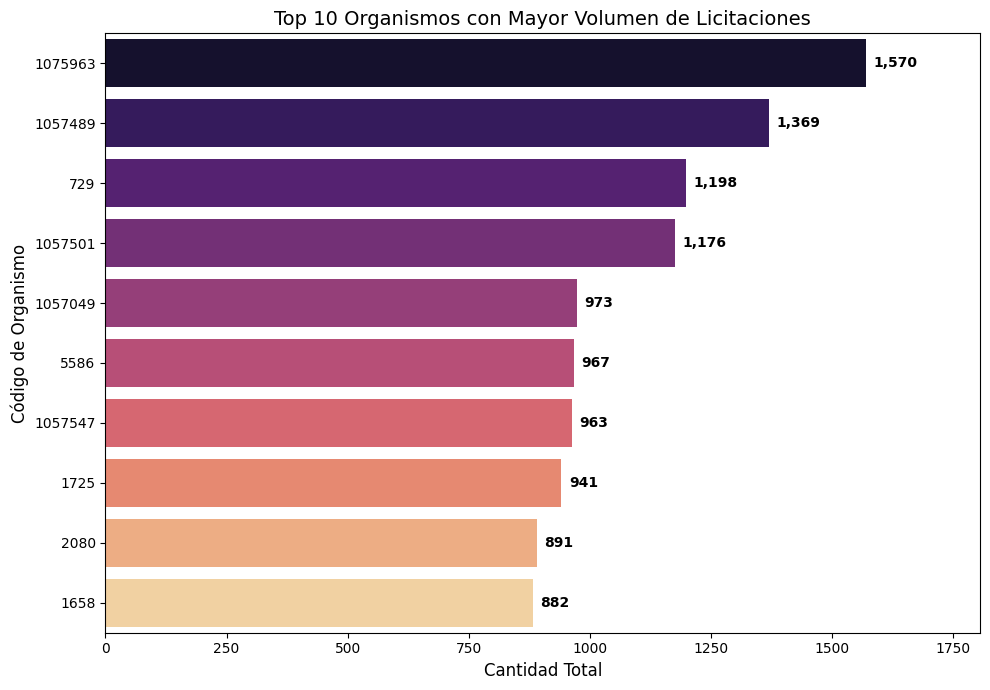

In [223]:
plt.figure(figsize=(10, 7))
top_10 = df_filtrado['codigo_organismo'].value_counts().head(10)

# Crear el gráfico de barras horizontales
ax_top = sns.barplot(x=top_10.values, y=top_10.index.astype(str), palette='magma')

# Añadir etiquetas a la derecha de cada barra
for i, v in enumerate(top_10.values):
    ax_top.text(v + (top_10.max() * 0.01), i, # Posición X un poco a la derecha del final de la barra
                format(v, ',.0f'),
                va='center', fontsize=10, fontweight='bold')

plt.title('Top 10 Organismos con Mayor Volumen de Licitaciones', fontsize=14)
plt.xlabel('Cantidad Total', fontsize=12)
plt.ylabel('Código de Organismo', fontsize=12)
plt.xlim(0, top_10.max() * 1.15) # Espacio a la derecha para los números
plt.tight_layout()
plt.show()



In [224]:
# 1. Preparar el Top 10 y su peso relativo
top_10 = df_filtrado['codigo_organismo'].value_counts().head(10).reset_index()
top_10.columns = ['Organismo', 'Cantidad']
total_general = len(df_filtrado)

# 2. Cálculo de representatividad
suma_top_10 = top_10['Cantidad'].sum()
porcentaje = (suma_top_10 / total_general) * 100

print(f"- El Top 10 de organismos suma {suma_top_10:,} licitaciones.")
print(f"- Esto representa solo el {porcentaje:.2f}% del volumen total de la muestra.")



- El Top 10 de organismos suma 10,930 licitaciones.
- Esto representa solo el 8.48% del volumen total de la muestra.


Se evidencia una desagregación de los organismos, no cumplen la Ley de  Pareto (80-20). Vamos a visualizar cómo es el comportamiento de los organismos y las licitaciones

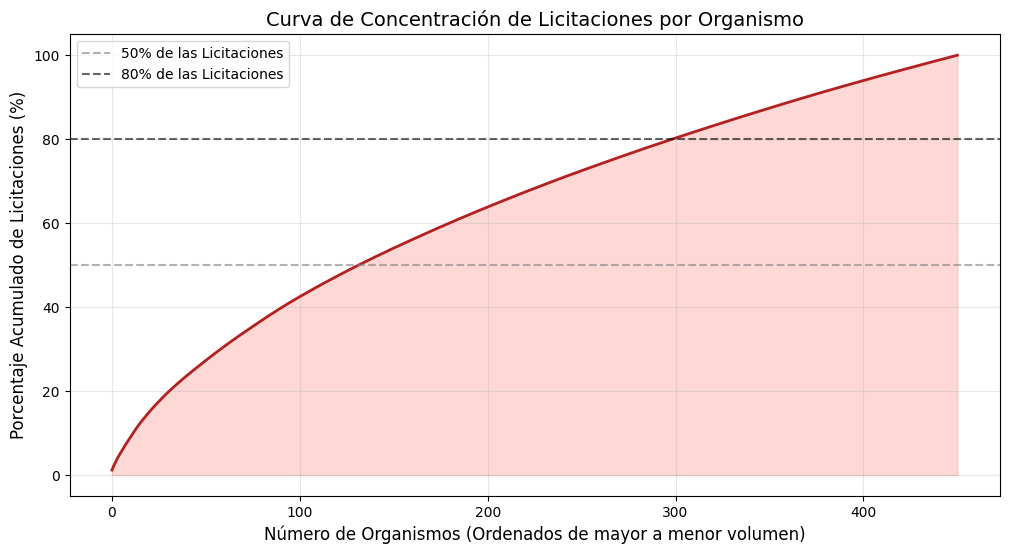

Evidencia: Se necesitan 132 organismos distintos para alcanzar el 50% del volumen total.
Total de organismos únicos: 451


In [225]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Preparar datos
counts = df_filtrado['codigo_organismo'].value_counts()
df_pareto = pd.DataFrame({'Organismo': counts.index, 'Cantidad': counts.values})
df_pareto['Porcentaje_Acumulado'] = df_pareto['Cantidad'].cumsum() / df_pareto['Cantidad'].sum() * 100

# Gráfico
plt.figure(figsize=(12, 6))
plt.plot(range(len(df_pareto)), df_pareto['Porcentaje_Acumulado'], color='firebrick', linewidth=2)
plt.fill_between(range(len(df_pareto)), df_pareto['Porcentaje_Acumulado'], color='salmon', alpha=0.3)

# Referencias visuales
plt.axhline(y=50, color='gray', linestyle='--', alpha=0.6, label='50% de las Licitaciones')
plt.axhline(y=80, color='black', linestyle='--', alpha=0.6, label='80% de las Licitaciones')

plt.title('Curva de Concentración de Licitaciones por Organismo', fontsize=14)
plt.xlabel('Número de Organismos (Ordenados de mayor a menor volumen)', fontsize=12)
plt.ylabel('Porcentaje Acumulado de Licitaciones (%)', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Cálculo para el reporte
n_50 = len(df_pareto[df_pareto['Porcentaje_Acumulado'] <= 50])
print(f"Evidencia: Se necesitan {n_50} organismos distintos para alcanzar el 50% del volumen total.")
print(f"Total de organismos únicos: {len(df_pareto)}")


La curva de Pareto se comporta como una línea diagonal, la fragmentación es total, el 29% de los organismos componen el 50% de las licitaciones.

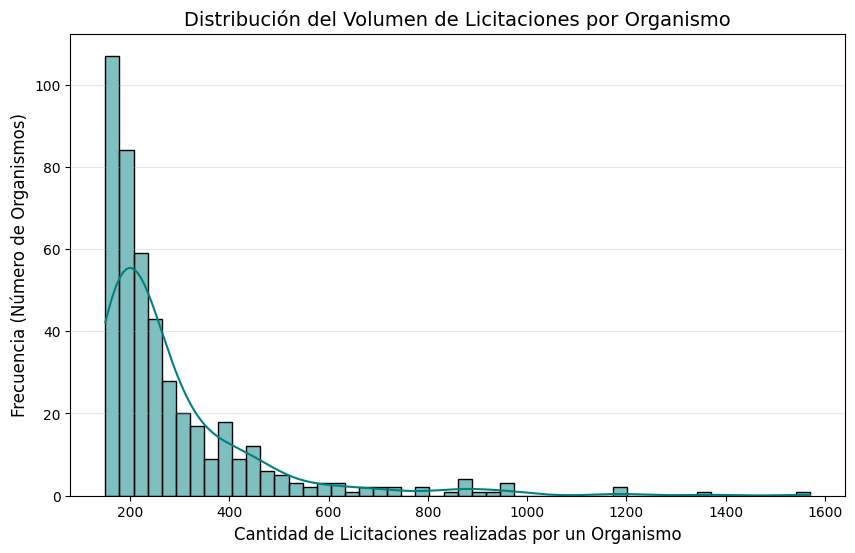

In [226]:
plt.figure(figsize=(10, 6))
counts = df_filtrado['codigo_organismo'].value_counts()

# Histograma con escala logarítmica si la dispersión es muy alta
sns.histplot(counts, bins=50, kde=True, color='teal')

plt.title('Distribución del Volumen de Licitaciones por Organismo', fontsize=14)
plt.xlabel('Cantidad de Licitaciones realizadas por un Organismo', fontsize=12)
plt.ylabel('Frecuencia (Número de Organismos)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()


El histograma está muy cargado a la izquierda, lo que significa que la gran mayoria de los organismos son "compradores ocasionales"

In [227]:
import numpy as np

def calcular_gini(array):
    """Calcula el coeficiente de Gini para una serie de valores."""
    array = array.flatten().astype(float)
    if np.amin(array) < 0:
        array -= np.amin(array) # Valores deben ser no negativos
    array += 0.0000001 # Evitar división por cero
    array = np.sort(array)
    index = np.arange(1, array.shape[0] + 1)
    n = array.shape[0]
    return ((np.sum((2 * index - n - 1) * array)) / (n * np.sum(array)))

# Obtener las cuentas por organismo
counts = df_filtrado['codigo_organismo'].value_counts().values
gini_score = calcular_gini(counts)

print(f"--- ANÁLISIS DE CONCENTRACIÓN ---")
print(f"Índice de Gini: {gini_score:.4f}")
print(f"Interpretación: {'Alta Concentración' if gini_score > 0.7 else 'Distribución Fragmentada/Equitativa'}")


--- ANÁLISIS DE CONCENTRACIÓN ---
Índice de Gini: 0.2769
Interpretación: Distribución Fragmentada/Equitativa


El coeficiente de Gini aparte de medir de la desigualdad de ingresos o riqueza dentro de una población, también sirve para medir matemáticamente la desigualdad en poblaciones de datos. Un indice cercano a cero "0" significa que todos los organismos licitan por igual (mercado equitativo), mientras que cercano a uno "1" indicaría que un solo organismo hace casi todas las licitaciones (mercado concentrado).
El resultado de 0.2769, que es menor al 0.4 confirma que el sistema de licitaciones está "atomizado", que existen miles de pequeños compradores.

In [228]:
# =========================================================
# VALIDACIÓN PRE-PASO 4: CALIDAD DE VARIABLES
# =========================================================

import pandas as pd

print("========================================")
print("1. VALIDACIÓN GENERAL")
print("========================================")

print("Shape:", df_filtrado.shape)
print("\nTipos de datos:")
print(df_filtrado.dtypes)

# ---------------------------------------------------------
# 2. VALIDAR VARIABLES CRÍTICAS
# ---------------------------------------------------------
print("\n========================================")
print("2. VALIDACIÓN VARIABLES CLAVE")
print("========================================")

columnas_clave = [
    "CodigoExterno",
    "codigo_organismo",
    "FechaCierre",
    "anio_licitacion"
]

for col in columnas_clave:
    assert col in df_filtrado.columns, f"Falta columna crítica: {col}"

print("Columnas críticas presentes")

# ---------------------------------------------------------
# 3. VALIDAR FECHAS (CLAVE PARA CICLICIDAD)
# ---------------------------------------------------------
print("\n========================================")
print("3. VALIDACIÓN FECHAS")
print("========================================")

# Convertir si es necesario
df_filtrado["FechaCierre"] = pd.to_datetime(df_filtrado["FechaCierre"], errors="coerce")

nulos_fecha = df_filtrado["FechaCierre"].isna().sum()

print(f"Fechas nulas: {nulos_fecha}")

assert nulos_fecha == 0, "Existen fechas inválidas"

# Crear variables temporales (si no existen)
df_filtrado["anio"] = df_filtrado["FechaCierre"].dt.year
df_filtrado["mes"] = df_filtrado["FechaCierre"].dt.month

print("Fechas correctamente formateadas")

# ---------------------------------------------------------
# 4. VALIDAR ORGANISMO
# ---------------------------------------------------------
print("\n========================================")
print("4. VALIDACIÓN ORGANISMO")
print("========================================")

nulos_org = df_filtrado["codigo_organismo"].isna().sum()

print(f"Organismos nulos: {nulos_org}")

assert nulos_org == 0, "Existen organismos nulos"

# tipo consistente
df_filtrado["codigo_organismo"] = df_filtrado["codigo_organismo"].astype(str)

print("codigo_organismo OK")

# ---------------------------------------------------------
# 5. VALIDAR DISTRIBUCIÓN TEMPORAL
# ---------------------------------------------------------
print("\n========================================")
print("5. VALIDACIÓN DISTRIBUCIÓN TEMPORAL")
print("========================================")

print("Años disponibles:")
print(sorted(df_filtrado["anio"].unique()))

print("\nMeses disponibles:")
print(sorted(df_filtrado["mes"].unique()))

# ---------------------------------------------------------
# 6. VALIDACIÓN FINAL
# ---------------------------------------------------------
print("\n========================================")
print("VALIDACIÓN FINAL")
print("========================================")

assert df_filtrado["mes"].between(1,12).all(), "Meses fuera de rango"

print("DATASET LISTO PARA PASO 4 (PATRONES CÍCLICOS)")

1. VALIDACIÓN GENERAL
Shape: (128849, 11)

Tipos de datos:
CodigoExterno               object
Nombre                      object
CodigoEstado                 int64
FechaCierre         datetime64[ns]
codigo_organismo            object
correlativo                 object
tipo_anio                   object
codigo_tipo                 object
anio_licitacion              Int64
tipo_raw                    object
tipo_base                   object
dtype: object

2. VALIDACIÓN VARIABLES CLAVE
Columnas críticas presentes

3. VALIDACIÓN FECHAS
Fechas nulas: 0
Fechas correctamente formateadas

4. VALIDACIÓN ORGANISMO
Organismos nulos: 0
codigo_organismo OK

5. VALIDACIÓN DISTRIBUCIÓN TEMPORAL
Años disponibles:
[np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]

Meses disponibles:
[np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]

VALIDACIÓN FIN

In [229]:
df_filtrado.head()

,CodigoExterno,Nombre,CodigoEstado,FechaCierre,codigo_organismo,correlativo,tipo_anio,codigo_tipo,anio_licitacion,tipo_raw,tipo_base,anio,mes
2180,2345-3-LE20,ARRIENDO BUSES PARA TRASLADOS HACIA IX REGION,8,2020-01-08 17:10:00,2345,3,LE20,LE,20,LE20,Publica,2020,1
2188,4993-1-LE20,CONVENIO SUMINISTRO SERVICIO DE MANTENCION Y R...,8,2020-01-10 15:00:00,4993,1,LE20,LE,20,LE20,Publica,2020,1
2236,4414-1-LE20,JUEGOS INFLABLES Y ACUATICOS VERANO 2020,8,2020-01-13 15:00:00,4414,1,LE20,LE,20,LE20,Publica,2020,1
2242,1464-1-LE20,Laboratorio 2020,8,2020-01-10 12:25:00,1464,1,LE20,LE,20,LE20,Publica,2020,1
2289,3794-3-LE20,PASAJES AEREOS EN EL TRAMO ISLA ROBINSON CRUSO...,8,2020-01-13 15:00:00,3794,3,LE20,LE,20,LE20,Publica,2020,1


## 📦 Código — Paso 4: Identificacion de Patrones cíclicos de licitación por codigo_organismo.

Eliminamos la columna mes que se creó para las graficas.

In [230]:
# Eliminar columnas específicas de forma permanente en el mismo dataframe
df_filtrado.drop(columns=['mes'], inplace=True, errors='ignore')

# Verificar las columnas presentes
print(f"Columnas presentes: {df_filtrado.columns.tolist()}")

Columnas presentes: ['CodigoExterno', 'Nombre', 'CodigoEstado', 'FechaCierre', 'codigo_organismo', 'correlativo', 'tipo_anio', 'codigo_tipo', 'anio_licitacion', 'tipo_raw', 'tipo_base', 'anio']


In [231]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [232]:
# =========================================================
# PREPARACIÓN DE DATOS
# =========================================================

df2 = df_filtrado.copy()

df2['FechaCierre'] = pd.to_datetime(df2['FechaCierre'], errors='coerce')
df2 = df2.dropna(subset=['FechaCierre'])

df2['mes'] = df2['FechaCierre'].dt.month
df2['anio'] = df2['FechaCierre'].dt.year
df2['dow'] = df2['FechaCierre'].dt.dayofweek
df2['trimestre'] = df2['FechaCierre'].dt.quarter

In [233]:
df2.head()

,CodigoExterno,Nombre,CodigoEstado,FechaCierre,codigo_organismo,correlativo,tipo_anio,codigo_tipo,anio_licitacion,tipo_raw,tipo_base,anio,mes,dow,trimestre
2180,2345-3-LE20,ARRIENDO BUSES PARA TRASLADOS HACIA IX REGION,8,2020-01-08 17:10:00,2345,3,LE20,LE,20,LE20,Publica,2020,1,2,1
2188,4993-1-LE20,CONVENIO SUMINISTRO SERVICIO DE MANTENCION Y R...,8,2020-01-10 15:00:00,4993,1,LE20,LE,20,LE20,Publica,2020,1,4,1
2236,4414-1-LE20,JUEGOS INFLABLES Y ACUATICOS VERANO 2020,8,2020-01-13 15:00:00,4414,1,LE20,LE,20,LE20,Publica,2020,1,0,1
2242,1464-1-LE20,Laboratorio 2020,8,2020-01-10 12:25:00,1464,1,LE20,LE,20,LE20,Publica,2020,1,4,1
2289,3794-3-LE20,PASAJES AEREOS EN EL TRAMO ISLA ROBINSON CRUSO...,8,2020-01-13 15:00:00,3794,3,LE20,LE,20,LE20,Publica,2020,1,0,1


### 4.1 Construcción matriz mensual.

Construye la distribución de licitaciones por mes para cada organismo.
Normaliza para comparar patrones independientes del volumen.
Permite ver en qué meses concentra actividad cada organismo.
Sirve como base para calcular métricas de ciclicidad.

In [234]:
# =========================================================
# IDENTIFICACIÓN DE PATRONES CÍCLICOS (VERSIÓN PRO)
# =========================================================

# =========================================================
# 4.1 MATRIZ MENSUAL POR ORGANISMO (VERSIÓN FINAL)
# =========================================================

pivot = df2.groupby(['codigo_organismo','mes']).size().unstack(fill_value=0)

# Normalización (distribución mensual)
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)

print('Pivot (counts):')
display(pivot.head())
print('\nPivot Normalizado (porcentajes):')
display(pivot_norm.head())

Pivot (counts):


mes,1,2,3,4,5,6,7,8,9,10,11,12
codigo_organismo,,,,,,,,,,,,
1000,0,1,6,19,14,16,12,15,16,25,26,14
1002,11,9,11,11,21,9,19,13,25,30,26,5
1002588,4,26,15,25,22,19,29,21,28,46,26,18
1002772,12,17,15,22,19,23,23,21,15,18,23,5
1019,3,14,27,22,38,26,28,27,27,31,45,21



Pivot Normalizado (porcentajes):


mes,1,2,3,4,5,6,7,8,9,10,11,12
codigo_organismo,,,,,,,,,,,,
1000,0.000000,0.006098,0.036585,0.115854,0.085366,0.097561,0.073171,0.091463,0.097561,0.152439,0.158537,0.085366
1002,0.057895,0.047368,0.057895,0.057895,0.110526,0.047368,0.100000,0.068421,0.131579,0.157895,0.136842,0.026316
1002588,0.014337,0.093190,0.053763,0.089606,0.078853,0.068100,0.103943,0.075269,0.100358,0.164875,0.093190,0.064516
1002772,0.056338,0.079812,0.070423,0.103286,0.089202,0.107981,0.107981,0.098592,0.070423,0.084507,0.107981,0.023474
1019,0.009709,0.045307,0.087379,0.071197,0.122977,0.084142,0.090615,0.087379,0.087379,0.100324,0.145631,0.067961


### 4.2 Métricas de ciclicidad.

Calcula indicadores de concentración y variabilidad (CV, entropía, HHI).
Mide qué tan predecible o concentrado es el comportamiento mensual.
Transforma datos en señales cuantificables de estacionalidad.
Alimenta el score que resume la ciclicidad.

In [235]:
# =========================================================
# 4.2 MÉTRICAS DE CICLICIDAD (VERSIÓN AJUSTADA)
# =========================================================

df_metrics = pd.DataFrame(index=pivot_norm.index)

# ---------------------------------------------------------
# 1. Coeficiente de variación (CORREGIDO)
# ---------------------------------------------------------
df_metrics['cv'] = pivot_norm.std(axis=1) / (pivot_norm.mean(axis=1) + 1e-9)

# ---------------------------------------------------------
# 2. Peso del mes dominante
# ---------------------------------------------------------
df_metrics['peso_mes_dominante'] = pivot_norm.max(axis=1)

# ---------------------------------------------------------
# 3. Entropía (inversa)
# ---------------------------------------------------------
df_metrics['entropia'] = -np.sum(
    pivot_norm * np.log(pivot_norm + 1e-9),
    axis=1
)

df_metrics['entropia_inv'] = 1 / (df_metrics['entropia'] + 1e-9)

# ---------------------------------------------------------
# 4. HHI (concentración)
# ---------------------------------------------------------
df_metrics['hhi'] = (pivot_norm**2).sum(axis=1)

# ---------------------------------------------------------
# 5. OUTPUT DE CONTROL
# ---------------------------------------------------------

print("\nPrimeras filas:")
display(df_metrics.head())


Primeras filas:


,cv,peso_mes_dominante,entropia,entropia_inv,hhi
codigo_organismo,,,,,
1000,0.596349,0.158537,2.264907,0.441519,0.110500
1002,0.508720,0.157895,2.367183,0.422443,0.103102
1002588,0.426623,0.164875,2.394514,0.417621,0.097237
1002772,0.305876,0.107981,2.433920,0.410860,0.090480
1019,0.414023,0.145631,2.389855,0.418435,0.096428


### 4.3 Estabilidad Interanual.

Identifica si el mes dominante se repite en distintos años.
Diferencia patrones reales vs eventos puntuales.
Aumenta la robustez del análisis temporal.
Se usa para validar consistencia del comportamiento. Esto separa: patrones reales vs eventos puntuales

In [236]:
# =========================================================
# 4.3 ESTABILIDAD INTERANUAL (VERSIÓN AJUSTADA)
# =========================================================

# ---------------------------------------------------------
# 1. Conteo mensual por organismo-año
# ---------------------------------------------------------
df_year_month = (
    df2
    .groupby(['codigo_organismo', 'anio', 'mes'])
    .size()
    .reset_index(name='count')
)

# ---------------------------------------------------------
# 2. Mes dominante por año
# ---------------------------------------------------------
idx = df_year_month.groupby(['codigo_organismo', 'anio'])['count'].idxmax()
mes_dom_anual = df_year_month.loc[idx]

# ---------------------------------------------------------
# 3. Frecuencia del mes dominante más repetido
# ---------------------------------------------------------
freq_mes_dom = (
    mes_dom_anual
    .groupby(['codigo_organismo', 'mes'])
    .size()
    .groupby(level=0)
    .max()
)

# ---------------------------------------------------------
# 4. TOTAL DE AÑOS POR ORGANISMO
# ---------------------------------------------------------
total_anios = mes_dom_anual.groupby('codigo_organismo')['anio'].nunique()

# ---------------------------------------------------------
# 5. ESTABILIDAD NORMALIZADA (CLAVE)
# ---------------------------------------------------------
estabilidad_norm = freq_mes_dom / total_anios

# ---------------------------------------------------------
# 6. INCORPORAR AL DATAFRAME
# ---------------------------------------------------------
df_metrics['estabilidad'] = estabilidad_norm
df_metrics['estabilidad'] = df_metrics['estabilidad'].fillna(0)

### 4.4 CICLICIDAD RELATIVA AL MERCADO.

Compara cada organismo contra el patrón del mercado total.
Detecta comportamientos “especiales” o desviaciones relevantes.
Evita falsos positivos de estacionalidad general.
Mejora la discriminación entre organismos.

In [237]:
# =========================================================
# 4.4 CICLICIDAD RELATIVA AL MERCADO (VERSIÓN FINAL)
# =========================================================

# ---------------------------------------------------------
# 1. DISTRIBUCIÓN DEL MERCADO
# ---------------------------------------------------------
market_counts = df2.groupby('mes').size()

# Asegurar meses 1–12
market_counts = market_counts.reindex(range(1,13), fill_value=0)

market_dist = market_counts / market_counts.sum()

# Validación: suma debe ser 1
assert np.isclose(market_dist.sum(), 1.0), "Error en distribución del mercado"

# ---------------------------------------------------------
# 2. CICLICIDAD RELATIVA (ESCALADA 0–1)
# ---------------------------------------------------------
df_metrics['ciclicidad_relativa'] = (
    pivot_norm
    .sub(market_dist, axis=1)
    .abs()
    .sum(axis=1) / 2
)

### 4.5 NORMALIZACIÓN

Escala todas las métricas a un rango comparable (0–1).
Evita que una variable domine el análisis.
Permite combinar métricas de forma equilibrada.
Prepara los datos para clustering y scoring.

In [238]:
# =========================================================
# 4.5 NORMALIZACIÓN DE FEATURES (VERSIÓN FINAL)
# =========================================================

from sklearn.preprocessing import MinMaxScaler

# ---------------------------------------------------------
# 1. COLUMNAS A NORMALIZAR
# ---------------------------------------------------------
cols = [
    'cv',
    'peso_mes_dominante',
    'entropia_inv',
    'hhi',
    'estabilidad',
    'ciclicidad_relativa'
]

# Validación: columnas existen
for col in cols:
    assert col in df_metrics.columns, f"Falta columna: {col}"

# ---------------------------------------------------------
# 2. NORMALIZACIÓN
# ---------------------------------------------------------
scaler = MinMaxScaler()

df_metrics[cols] = scaler.fit_transform(df_metrics[cols])

En la normalización se escala todas las métricas a un rango comparable (0–1). Evita que una variable domine el análisis. Permite combinar métricas de forma equilibrada. Prepara los datos para clustering y scoring.

### 4.6 SCORE FINAL

Combina todas las métricas en un indicador único de ciclicidad.
Resume el comportamiento de cada organismo en un valor.
Facilita ranking y comparación directa.
Es la base para identificar organismos estratégicos.

In [239]:
# =========================================================
# 4.6 SCORE FINAL DE CICLICIDAD (VERSIÓN COMPLETA)
# =========================================================

df_metrics['score_final'] = (
    df_metrics['cv'] * 0.1 +
    df_metrics['peso_mes_dominante'] * 0.25 +
    df_metrics['entropia_inv'] * 0.1 +
    df_metrics['hhi'] * 0.15 +
    df_metrics['estabilidad'] * 0.25 +
    df_metrics['ciclicidad_relativa'] * 0.15
)

## Métricas de Ciclicidad por Organismo

Aquí se explican las métricas clave derivadas para entender los patrones cíclicos de licitación de cada organismo:

1. cv (Coeficiente de Variación): Mide la variabilidad de licitaciones de un mes a otro, con un peso del 15%.

2. peso_mes_dominante: Indica la proporción de licitaciones en el mes de mayor actividad, con un peso del 25%.

3. entropia_inv (Entropía Inversa): Mide la predecibilidad de la distribución mensual de licitaciones, con un peso del 15%.

4. hhi (Índice Herfindahl-Hirschman): Evalúa la concentración de las licitaciones en ciertos meses, con un peso del 15%.

5. estabilidad: Cuantifica qué tan consistente es el mes dominante a lo largo de los años, con un peso del 15%.

6. ciclicidad_relativa: Compara el patrón del organismo con el patrón general del mercado, con un peso del 15%.

Estas métricas combinadas nos permiten cuantificar la estacionalidad de cada organismo y clasificar su comportamiento cíclico.


### 4.7 VALIDACIÓN DE CLUSTERS.

Evalúa distintas cantidades de clusters con silhouette score.
Permite elegir el número óptimo de segmentaciones.
Evita segmentaciones arbitrarias.
Asegura mayor calidad en el clustering. Eliges el mejor k

Evaluación silhouette:
k=2 -> silhouette=0.5931
k=3 -> silhouette=0.4205
k=4 -> silhouette=0.4298
k=5 -> silhouette=0.3691
k=6 -> silhouette=0.4213
k=7 -> silhouette=0.4276


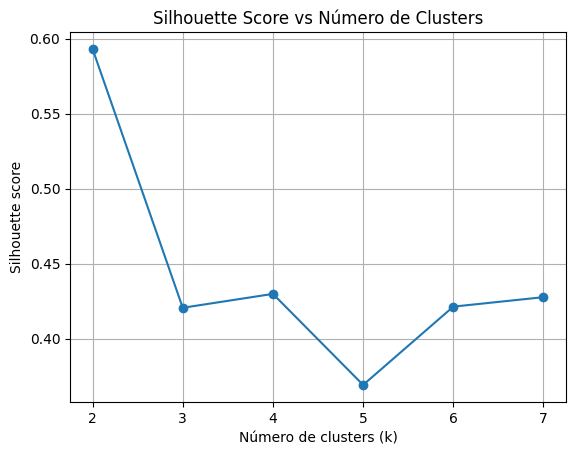


Mejor K según silhouette: 2


In [240]:
# =========================================================
# 4.7 VALIDACIÓN DE NÚMERO DE CLUSTERS (VERSIÓN FINAL)
# =========================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. MATRIZ DE FEATURES
# ---------------------------------------------------------
X = df_metrics[cols]

# ---------------------------------------------------------
# 2. EVALUACIÓN SILHOUETTE
# ---------------------------------------------------------
scores = []
k_values = list(range(2, 8))

print("Evaluación silhouette:")
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    scores.append(score)
    print(f"k={k} -> silhouette={score:.4f}")

# ---------------------------------------------------------
# 3. VISUALIZACIÓN
# ---------------------------------------------------------
plt.figure()
plt.plot(k_values, scores, marker='o')
plt.title("Silhouette Score vs Número de Clusters")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette score")
plt.grid()
plt.show()

# ---------------------------------------------------------
# 4. MEJOR K SEGÚN MÉTRICA
# ---------------------------------------------------------
best_k = k_values[scores.index(max(scores))]
print(f"\nMejor K según silhouette: {best_k}")

In [241]:
# ---------------------------------------------------------
# 5. SELECCIÓN FINAL (CRITERIO DE NEGOCIO)
# ---------------------------------------------------------
# Aunque k=2 maximiza el silhouette score,
# se selecciona k=4 para lograr mayor granularidad analítica

K_OPTIMO = 4

print(f"K_OPTIMO seleccionado (criterio final): {K_OPTIMO}")

K_OPTIMO seleccionado (criterio final): 4


**Selección del número óptimo de clusters**

Para determinar el número óptimo de clusters, se utilizó la métrica Silhouette Score, que evalúa la cohesión interna de los clusters y su separación respecto a otros grupos.

Los resultados obtenidos muestran que:

El valor máximo de silhouette se alcanza en k = 2, indicando una separación muy clara entre dos grandes grupos.
Sin embargo, valores de k entre 3 y 7 presentan resultados relativamente cercanos, lo que sugiere que el dataset admite segmentaciones más granulares sin una pérdida significativa de calidad.

**Decisión final**

Se selecciona k = 4 como número óptimo de clusters, debido a que:

Permite una segmentación más rica e interpretable del mercado.
Facilita la identificación de distintos niveles de ciclicidad (bajo, medio-bajo, medio-alto, alto).
Mantiene una calidad de clustering aceptable según la métrica silhouette.
Mejora la aplicabilidad del modelo en términos de análisis estratégico y toma de decisiones.

### 4.8 CLUSTERING FINAL

Agrupa organismos según su comportamiento de licitación.
Identifica patrones similares entre ellos.
Segmenta el mercado en perfiles claros.
Permite análisis estratégico por grupo.

In [242]:
# =========================================================
# 4.8 CLUSTERING FINAL (VERSIÓN COMPLETA)
# =========================================================

from sklearn.cluster import KMeans

# ---------------------------------------------------------
# 1. VALIDACIÓN INPUT
# ---------------------------------------------------------
assert 'score_final' in df_metrics.columns, "Falta score_final"
assert len(df_metrics) > 0, "df_metrics vacío"

# ---------------------------------------------------------
# 2. CLUSTERING
# ---------------------------------------------------------
kmeans = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10)
df_metrics['cluster'] = kmeans.fit_predict(X)

# ---------------------------------------------------------
# 3. DISTRIBUCIÓN DE CLUSTERS
# ---------------------------------------------------------
print("\nCantidad de organismos por cluster:")
cluster_counts = (
    df_metrics['cluster']
    .value_counts()
    .sort_index()
    .reset_index()
    .rename(columns={'index': 'cluster', 'cluster': 'cantidad'})
)

display(cluster_counts)

# ---------------------------------------------------------
# 4. PERFIL PROMEDIO POR CLUSTER
# ---------------------------------------------------------
cluster_summary = (
    df_metrics
    .groupby('cluster')[cols + ['score_final']]
    .mean()
)

print("\nPerfil promedio por cluster:")
display(cluster_summary)

# ---------------------------------------------------------
# 5. ORDENAR CLUSTERS POR CICLICIDAD
# ---------------------------------------------------------
cluster_summary = cluster_summary.sort_values('score_final', ascending=False)

print("\nClusters ordenados por score_final:")
display(cluster_summary)


Cantidad de organismos por cluster:


,cantidad,count
0,0,257
1,1,19
2,2,85
3,3,90



Perfil promedio por cluster:


,cv,peso_mes_dominante,entropia_inv,hhi,estabilidad,ciclicidad_relativa,score_final
cluster,,,,,,,
0,0.147223,0.087001,0.047655,0.042530,0.201751,0.166887,0.123088
1,0.626692,0.591465,0.417067,0.444572,0.756579,0.673796,0.609142
2,0.334659,0.225479,0.171824,0.148434,0.317941,0.394244,0.267905
3,0.207742,0.159297,0.076993,0.072285,0.558333,0.227110,0.252790



Clusters ordenados por score_final:


,cv,peso_mes_dominante,entropia_inv,hhi,estabilidad,ciclicidad_relativa,score_final
cluster,,,,,,,
1,0.626692,0.591465,0.417067,0.444572,0.756579,0.673796,0.609142
2,0.334659,0.225479,0.171824,0.148434,0.317941,0.394244,0.267905
3,0.207742,0.159297,0.076993,0.072285,0.558333,0.227110,0.252790
0,0.147223,0.087001,0.047655,0.042530,0.201751,0.166887,0.123088


###4.9 IDENTIFICAR CLUSTER ESTRATÉGICO

Identifica el cluster con mayor score de ciclicidad.
Define automáticamente el segmento más relevante.
Evita selección arbitraria (ej: “cluster 4”).
Base para focalizar análisis y decisiones.

In [243]:
# =========================================================
# 4.9 IDENTIFICACIÓN DEL CLUSTER ESTRATÉGICO (VERSIÓN FINAL)
# =========================================================

# ---------------------------------------------------------
# 1. RESUMEN POR CLUSTER
# ---------------------------------------------------------
cluster_summary = (
    df_metrics
    .groupby('cluster')[cols + ['score_final']]
    .mean()
)

print("\nResumen clusters:")
display(cluster_summary)

cluster_estrategico = cluster_summary['score_final'].idxmax()

print(f"\nCluster estratégico identificado: {cluster_estrategico}")


Resumen clusters:


,cv,peso_mes_dominante,entropia_inv,hhi,estabilidad,ciclicidad_relativa,score_final
cluster,,,,,,,
0,0.147223,0.087001,0.047655,0.042530,0.201751,0.166887,0.123088
1,0.626692,0.591465,0.417067,0.444572,0.756579,0.673796,0.609142
2,0.334659,0.225479,0.171824,0.148434,0.317941,0.394244,0.267905
3,0.207742,0.159297,0.076993,0.072285,0.558333,0.227110,0.252790



Cluster estratégico identificado: 1


### 4.10 DATASET FINAL

🔹 4.10.A Filtrado cluster

Extrae sólo los organismos del cluster estratégico.
Reduce el universo a los más relevantes.
Permite análisis enfocado y accionable.
Prepara datos para ranking final.

In [244]:
# =========================================================
# CONSTRUCCIÓN DATASET ESTRATÉGICO (VERSIÓN FINAL)
# =========================================================

# ---------------------------------------------------------
# 1. VALIDACIÓN INICIAL
# ---------------------------------------------------------
assert 'cluster' in df_metrics.columns, "Falta cluster"
assert cluster_estrategico in df_metrics['cluster'].unique(), "Cluster estratégico inválido"

print("Validaciones iniciales OK")

# ---------------------------------------------------------
# 2. FILTRAR CLUSTER ESTRATÉGICO
# ---------------------------------------------------------
df_cluster_target = df_metrics[
    df_metrics['cluster'] == cluster_estrategico
].copy()

print(f"Organismos estratégicos: {len(df_cluster_target)}")

# ---------------------------------------------------------
# 3. ASEGURAR INDEX = codigo_organismo
# ---------------------------------------------------------
df_cluster_target.index.name = 'codigo_organismo'

Validaciones iniciales OK
Organismos estratégicos: 19


🔹 4.10.B Volumen

Incorpora cantidad de licitaciones por organismo.
Mide peso real en el mercado.
Complementa ciclicidad con impacto.
Se usa para priorización estratégica.

In [245]:
# =========================================================
# INCORPORAR VOLUMEN
# =========================================================

volumen = df2['codigo_organismo'].value_counts()

df_cluster_target['volumen'] = df_cluster_target.index.map(volumen)

# manejar posibles nulos
df_cluster_target['volumen'] = df_cluster_target['volumen'].fillna(0)

# ---------------------------------------------------------
# 1. NORMALIZAR VOLUMEN
# ---------------------------------------------------------
max_vol = df_cluster_target['volumen'].max()

assert max_vol > 0, "Volumen máximo inválido"

df_cluster_target['volumen_norm'] = df_cluster_target['volumen'] / max_vol

# ---------------------------------------------------------
# 2. VALIDACIONES
# ---------------------------------------------------------
assert df_cluster_target['volumen'].notna().all(), "Error en volumen"
assert (df_cluster_target['volumen_norm'] <= 1).all(), "Normalización incorrecta"

### 4.11 RANKING FINAL

Combina ciclicidad y volumen en un score único.
Ordena organismos por relevancia estratégica.
Define prioridades de análisis o negocio.
Entrega lista accionable.

In [246]:
# =========================================================
# 4.11 RANKING ESTRATÉGICO (VERSIÓN FINAL)
# =========================================================

# ---------------------------------------------------------
# 1. VALIDACIÓN INPUTS
# ---------------------------------------------------------
assert 'score_final' in df_cluster_target.columns, "Falta score_final"
assert 'volumen_norm' in df_cluster_target.columns, "Falta volumen_norm"

print("Inputs validados")

# ---------------------------------------------------------
# 2. CÁLCULO RANKING SCORE
# ---------------------------------------------------------
df_cluster_target['ranking_score'] = (
    df_cluster_target['score_final'] * 0.7 +
    df_cluster_target['volumen_norm'] * 0.3
)

# ---------------------------------------------------------
# 3. ORDENAR
# ---------------------------------------------------------
df_cluster_target = df_cluster_target.sort_values(
    'ranking_score',
    ascending=False
)

# ---------------------------------------------------------
# 4. GENERAR RANKING
# ---------------------------------------------------------
df_cluster_target['ranking'] = range(1, len(df_cluster_target) + 1)

# ---------------------------------------------------------
# 5. VALIDACIONES
# ---------------------------------------------------------
assert df_cluster_target['ranking_score'].between(0,1).all(), "Ranking fuera de rango"
assert df_cluster_target['ranking'].is_unique, "Ranking duplicado"

# ---------------------------------------------------------
# 6. OUTPUT CLAVE
# ---------------------------------------------------------
print("\n Top 19 organismos estratégicos:")
display(df_cluster_target.head(19))

# ---------------------------------------------------------
# 7. TOP 1 (CLAVE NEGOCIO)
# ---------------------------------------------------------
top_organismo = df_cluster_target.head(1)

print("\n Organismo más estratégico:")
display(top_organismo[['ranking_score', 'score_final', 'volumen']])

print("\n Dataset final de ranking listo")

Inputs validados

 Top 19 organismos estratégicos:


,cv,peso_mes_dominante,entropia,entropia_inv,hhi,estabilidad,ciclicidad_relativa,score_final,cluster,volumen,volumen_norm,ranking_score,ranking
codigo_organismo,,,,,,,,,,,,,
3510,1.000000,1.000000,1.788695,1.000000,1.000000,1.000,1.000000,1.000000,1,202,0.428875,0.828662,1
3863,0.847811,0.890647,2.007205,0.608896,0.737543,1.000,0.841867,0.855244,1,253,0.537155,0.759817,2
4857,0.874274,0.899668,1.926421,0.743151,0.780337,1.000,0.870662,0.884309,1,160,0.339703,0.720927,3
3656,0.490293,0.438550,2.261081,0.249425,0.276720,0.750,0.595669,0.501968,1,471,1.000000,0.651377,4
1660,0.616511,0.665481,2.204854,0.321901,0.414459,1.000,0.590948,0.661022,1,276,0.585987,0.638512,5
2196,0.664329,0.649604,2.126787,0.428884,0.473753,0.750,0.725251,0.639073,1,184,0.390658,0.564548,6
3794,0.626664,0.403936,2.085982,0.487989,0.426722,0.500,0.884320,0.534106,1,279,0.592357,0.551581,7
3960,0.760720,0.575192,2.022297,0.585004,0.605159,0.500,0.904735,0.629854,1,166,0.352442,0.546631,8
2564,0.567133,0.593016,2.230548,0.288328,0.357331,1.000,0.582781,0.624817,1,156,0.331210,0.536735,9



 Organismo más estratégico:


,ranking_score,score_final,volumen
codigo_organismo,,,
3510,0.828662,1.0,202



 Dataset final de ranking listo


In [247]:
# ---------------------------------------------------------
# 8. OUTPUT FINAL
# ---------------------------------------------------------

print("\nTop 19 organismos estratégicos:")
display(df_cluster_target.head(19))


Top 19 organismos estratégicos:


,cv,peso_mes_dominante,entropia,entropia_inv,hhi,estabilidad,ciclicidad_relativa,score_final,cluster,volumen,volumen_norm,ranking_score,ranking
codigo_organismo,,,,,,,,,,,,,
3510,1.000000,1.000000,1.788695,1.000000,1.000000,1.000,1.000000,1.000000,1,202,0.428875,0.828662,1
3863,0.847811,0.890647,2.007205,0.608896,0.737543,1.000,0.841867,0.855244,1,253,0.537155,0.759817,2
4857,0.874274,0.899668,1.926421,0.743151,0.780337,1.000,0.870662,0.884309,1,160,0.339703,0.720927,3
3656,0.490293,0.438550,2.261081,0.249425,0.276720,0.750,0.595669,0.501968,1,471,1.000000,0.651377,4
1660,0.616511,0.665481,2.204854,0.321901,0.414459,1.000,0.590948,0.661022,1,276,0.585987,0.638512,5
2196,0.664329,0.649604,2.126787,0.428884,0.473753,0.750,0.725251,0.639073,1,184,0.390658,0.564548,6
3794,0.626664,0.403936,2.085982,0.487989,0.426722,0.500,0.884320,0.534106,1,279,0.592357,0.551581,7
3960,0.760720,0.575192,2.022297,0.585004,0.605159,0.500,0.904735,0.629854,1,166,0.352442,0.546631,8
2564,0.567133,0.593016,2.230548,0.288328,0.357331,1.000,0.582781,0.624817,1,156,0.331210,0.536735,9


In [248]:
df_cluster_target.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19 entries, 3510 to 1057503
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   cv                   19 non-null     float64
 1   peso_mes_dominante   19 non-null     float64
 2   entropia             19 non-null     float64
 3   entropia_inv         19 non-null     float64
 4   hhi                  19 non-null     float64
 5   estabilidad          19 non-null     float64
 6   ciclicidad_relativa  19 non-null     float64
 7   score_final          19 non-null     float64
 8   cluster              19 non-null     int32  
 9   volumen              19 non-null     int64  
 10  volumen_norm         19 non-null     float64
 11  ranking_score        19 non-null     float64
 12  ranking              19 non-null     int64  
dtypes: float64(10), int32(1), int64(2)
memory usage: 2.0+ KB


## Ranking — Organismos Estratégicos

El ranking identifica organismos del cluster 1, caracterizados por presentar los mayores niveles de ciclicidad, concentración y consistencia temporal en sus patrones de licitación. Los primeros lugares (ej: 3510, 3863, 4857) destacan por valores máximos en CV, peso del mes dominante, HHI y estabilidad, lo que indica procesos altamente predecibles y concentrados en períodos específicos del año.

Adicionalmente, el ranking incorpora volumen de licitaciones, permitiendo priorizar organismos que no solo son cíclicos, sino también relevantes en términos de impacto de mercado (ej: 3656).

En conjunto, los organismos seleccionados representan el segmento con mayor potencial estratégico, ya que combinan predictibilidad, recurrencia y volumen, lo que los convierte en candidatos ideales para anticipación de licitaciones y generación de oportunidades de negocio.

In [249]:
# ---------------------------------------------------------
# 9. FILTRAR LICITACIONES DE ORGANISMOS ESTRATÉGICOS
# ---------------------------------------------------------

# Obtener la lista de los codigo_organismo de df_cluster_target (los 19 organismos estratégicos)
lista_org_cluster_estrategico = df_cluster_target.index.tolist()

# Filtrar df_filtrado para incluir solo las licitaciones de estos organismos
df_licitaciones_organismos_estrategicos = df_filtrado[
    df_filtrado['codigo_organismo'].isin(lista_org_cluster_estrategico)
].copy()

print("Total de licitaciones asociadas a los organismos estratégicos:", len(df_licitaciones_organismos_estrategicos))

Total de licitaciones asociadas a los organismos estratégicos: 4031


In [250]:
# ---------------------------------------------------------
# 10. AGREGAR INFORMACIÓN DE RANKING
# ---------------------------------------------------------

# df_cluster_target ya tiene 'ranking' como columna y 'codigo_organismo' como índice.

# Crear un DataFrame auxiliar solo con el codigo_organismo y el ranking
ranking_info = df_cluster_target[['ranking']].reset_index()
ranking_info.rename(columns={'ranking': 'ranking_estrategico'}, inplace=True)

# Unir el ranking al DataFrame de licitaciones filtradas
df_licitaciones_organismos_estrategicos = df_licitaciones_organismos_estrategicos.merge(
    ranking_info,
    on='codigo_organismo',
    how='left'
)

print("Primeras filas de las licitaciones con el ranking estratégico:")
display(df_licitaciones_organismos_estrategicos.head())

Primeras filas de las licitaciones con el ranking estratégico:


,CodigoExterno,Nombre,CodigoEstado,FechaCierre,codigo_organismo,correlativo,tipo_anio,codigo_tipo,anio_licitacion,tipo_raw,tipo_base,anio,ranking_estrategico
0,3794-3-LE20,PASAJES AEREOS EN EL TRAMO ISLA ROBINSON CRUSO...,8,2020-01-13 15:00:00,3794,3,LE20,LE,20,LE20,Publica,2020,7
1,3656-1-LE20,SERVICIO DE ASEO DIFERENTES DEPENDENCIAS MUNIC...,8,2020-01-13 15:01:00,3656,1,LE20,LE,20,LE20,Publica,2020,4
2,3656-2-LE20,PRODUCCIÓN TÉCNICA Y ARTISTICA SEMANA LIRIANA,8,2020-01-13 16:00:00,3656,2,LE20,LE,20,LE20,Publica,2020,4
3,3794-5-LE20,FLETE INTERNACIONAL MENAJE BOGOTÁ (COLOMBIA)–B...,8,2020-01-20 15:00:00,3794,5,LE20,LE,20,LE20,Publica,2020,7
4,1509-2-LE20,MANTENCION EQUIPOS DE CLIMATIZACION HCTT,8,2020-01-17 11:10:00,1509,2,LE20,LE,20,LE20,Publica,2020,16


In [251]:
# ---------------------------------------------------------
# 11. VERIFICAR LOS ORGANISMOS EN EL NUEVO DATAFRAME
# ---------------------------------------------------------

print("Cantidad de organismos únicos en el nuevo DataFrame:", df_licitaciones_organismos_estrategicos['codigo_organismo'].nunique())
print("Lista de organismos únicos en el nuevo DataFrame (primeros 5):")
display(df_licitaciones_organismos_estrategicos['codigo_organismo'].unique()[:5])

Cantidad de organismos únicos en el nuevo DataFrame: 19
Lista de organismos únicos en el nuevo DataFrame (primeros 5):


array(['3794', '3656', '1509', '3508', '3960'], dtype=object)

In [252]:
df_licitaciones_organismos_estrategicos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4031 entries, 0 to 4030
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CodigoExterno        4031 non-null   object        
 1   Nombre               4031 non-null   object        
 2   CodigoEstado         4031 non-null   int64         
 3   FechaCierre          4031 non-null   datetime64[ns]
 4   codigo_organismo     4031 non-null   object        
 5   correlativo          4031 non-null   object        
 6   tipo_anio            4031 non-null   object        
 7   codigo_tipo          4031 non-null   object        
 8   anio_licitacion      4031 non-null   Int64         
 9   tipo_raw             4031 non-null   object        
 10  tipo_base            4031 non-null   object        
 11  anio                 4031 non-null   int32         
 12  ranking_estrategico  4031 non-null   int64         
dtypes: Int64(1), datetime64[ns](1), i

## Actualización de data antes de exportación

Debido a la gran cantidad de información que implica tener las ordenes de compra adjudicadas (cada año alrededor de 90MB y consolidado 2020-2025 más de 550MB), decidimos trabajar con esa data por fuera del notebook. Allí lo que hicimos fue conseguir el nombre y ubicación de los organismos filtrados que al final decidimos con los que trabajaremos (19). A continuación el script para descargar el archivo ya con el cruce y la información de los organismos.

In [253]:
# =========================================================
# ACTIALIZACIÓN DE DATA
# =========================================================

# ---------------------------------------------------------
# 1. DICCIONARIO ORGANISMOS ESTRATÉGICOS
# ---------------------------------------------------------

dict_organismos = df_cluster_target['ranking'].to_dict()

print("Diccionario organismos estratégicos:")
print(dict_organismos)

Diccionario organismos estratégicos:
{'3510': 1, '3863': 2, '4857': 3, '3656': 4, '1660': 5, '2196': 6, '3794': 7, '3960': 8, '2564': 9, '2342': 10, '3589': 11, '979': 12, '1247197': 13, '4809': 14, '3709': 15, '1509': 16, '3928': 17, '3508': 18, '1057503': 19}


In [254]:
# ---------------------------------------------------------
# 2. DESCARGA DE DATA DE NOMBRES DE ORGANISMOS Y REGIONES
# ---------------------------------------------------------

import os
import requests
import pandas as pd

# ID actualizado para el archivo de 5kb
FILE_ID = '18iumJRr-Sp1pRCuhgEukWAPDS26q_6dW'
URL = f'https://drive.google.com/uc?export=download&id={FILE_ID}'
NOMBRE_LOCAL = 'archivo_pequeño.csv'

print("--- DESCARGANDO ARCHIVO PEQUEÑO ---")

try:
    # Descarga directa
    response = requests.get(URL, stream=True)
    with open(NOMBRE_LOCAL, "wb") as f:
        for chunk in response.iter_content(chunk_size=4096): # Chunk más pequeño para archivos livianos
            if chunk: f.write(chunk)

    # Verificación de integridad en Kilobytes (KB)
    peso_kb = os.path.getsize(NOMBRE_LOCAL) / 1024
    print(f"Archivo descargado: {peso_kb:.2f} KB")

    # Bajamos el umbral de validación a 1 KB
    if peso_kb > 1.0:
        df_nombre_org = pd.read_csv(NOMBRE_LOCAL, engine='pyarrow')
        # Eliminamos columna no requerida
        df_nombre_org = df_nombre_org.drop(columns=['total_le_adjudicadas'], errors='ignore')
        # ------------------------------------------------------
        print(f"¡ÉXITO! Datos cargados: {df_nombre_org.shape} filas.")
        display(df_nombre_org.head())
    else:
        print("El archivo es sospechosamente pequeño (< 1KB). Verifica el contenido.")

except Exception as e:
    print(f"Error: {e}")

--- DESCARGANDO ARCHIVO PEQUEÑO ---
Archivo descargado: 1.66 KB
¡ÉXITO! Datos cargados: (19, 4) filas.


,prefijo,codigo_organismo,nombre_organismo,region_unidad
0,3656,116215,I MUNICIPALIDAD DE REQUINOA,Región del Libertador General Bernardo O´Higgins
1,3794,113812,DIRECCION DE LOGISTICA DE CARABINEROS,Región Metropolitana de Santiago
2,1660,7323,SERVICIO SALUD COQUIMBO HOSP DE SALAMANC,Región de Coquimbo
3,3863,117584,I MUNICIPALIDAD DE SANTA CRUZ,Región del Libertador General Bernardo O´Higgins
4,4809,7248,MINISTERIO DE OBRAS PUBLICAS DIREC CION GRAL D...,Región de la Araucanía


In [255]:
df_nombre_org.sort_values(by='prefijo', ascending=True)

,prefijo,codigo_organismo,nombre_organismo,region_unidad
7,979,7248,MINISTERIO DE OBRAS PUBLICAS DIREC CION GRAL D...,Región Metropolitana de Santiago
9,1509,7274,SERVICIO DE SALUD METROPOLITANO NORTE HOSPITAL...,Región Metropolitana de Santiago
2,1660,7323,SERVICIO SALUD COQUIMBO HOSP DE SALAMANC,Región de Coquimbo
10,2196,7427,Hospital Psiquiátrico El Peral,Región Metropolitana de Santiago
18,2342,86548,I MUNICIPALIDAD DE SAN BERNARDO,Región Metropolitana de Santiago
16,2564,92414,I MUNICIPALIDAD DE CHEPICA,Región del Libertador General Bernardo O´Higgins
17,3508,115168,I MUNICIPALIDAD DE CHONCHI,Región de los Lagos
8,3510,115011,I MUNICIPALIDAD DE CALBUCO,Región de los Lagos
11,3589,115294,I MUNICIPALIDAD DE YUNGAY,Región del Ñuble
0,3656,116215,I MUNICIPALIDAD DE REQUINOA,Región del Libertador General Bernardo O´Higgins


In [256]:
df_nombre_org['prefijo'].nunique()

19

En este punto nos percatamos que en la tabla de df_nombre_org los valores de la columna prefijo, son los mismos que los de codigo_organismo de la tabla df_licitaciones_organismos_estrategicos. los conectaremos y agregaremos el nombre_organismo y region_unidad.

In [257]:
# ================================
# 1. LIMPIEZA DE CARACTERES (df_nombre_org)
# ================================
correcciones = {
    'RegiÃ³n': 'Región',
    'Metropolitana de Santiago': 'RM',
    'Ã\xad': 'í', 'Ã¡': 'á', 'Ã©': 'é',
    'Ã³': 'ó', 'Ãº': 'ú', 'Ã±': 'ñ'
}

for col in ['region_unidad', 'nombre_organismo']:
    df_nombre_org[col] = df_nombre_org[col].astype(str)
    for error, correccion in correcciones.items():
        df_nombre_org[col] = df_nombre_org[col].str.replace(error, correccion, regex=False)

print("Caracteres corregidos")

# ================================
# 2. NORMALIZAR CLAVES (CRÍTICO)
# ================================
# Evita fallos por espacios / ceros / tipos
df_licitaciones_organismos_estrategicos['codigo_organismo'] = (
    df_licitaciones_organismos_estrategicos['codigo_organismo']
    .astype(str).str.strip().str.lstrip('0')
)

df_nombre_org['prefijo'] = (
    df_nombre_org['prefijo']
    .astype(str).str.strip().str.lstrip('0')
)

# ================================
# 3. ELIMINAR COLUMNAS ANTIGUAS
# ================================
cols_a_actualizar = ['nombre_organismo', 'region_unidad']

df_licitaciones_organismos_estrategicos = df_licitaciones_organismos_estrategicos.drop(
    columns=[c for c in cols_a_actualizar if c in df_licitaciones_organismos_estrategicos.columns],
    errors='ignore'
)

# ================================
# 4. ELIMINAR DUPLICADOS EN LA TABLA MAESTRA
# ================================
# Si hay prefijos duplicados, el merge se multiplica
df_nombre_org = df_nombre_org.drop_duplicates(subset=['prefijo'])

# ================================
# 5. MERGE CORRECTO + VALIDACIÓN DE CARDINALIDAD
# ================================
df_licitaciones_organismos_estrategicos = df_licitaciones_organismos_estrategicos.merge(
    df_nombre_org[['prefijo', 'nombre_organismo', 'region_unidad']],
    left_on='codigo_organismo',
    right_on='prefijo',
    how='left',
    validate='m:1'  # clave: muchos a uno (detecta errores)
)

# ================================
# 6. LIMPIEZA FINAL
# ================================
df_licitaciones_organismos_estrategicos.drop(columns=['prefijo'], inplace=True)

# ================================
# 7. VALIDACIÓN
# ================================
print("Columnas finales:")
print(df_licitaciones_organismos_estrategicos.columns.tolist())

display(
    df_licitaciones_organismos_estrategicos[
        ['codigo_organismo', 'nombre_organismo', 'region_unidad']
    ].head()
)

print("Regiones únicas:")
print(df_licitaciones_organismos_estrategicos['region_unidad'].dropna().unique())

# ================================
# 8. CONTROL DE CALIDAD
# ================================
nulos = df_licitaciones_organismos_estrategicos['nombre_organismo'].isna().sum()
total = len(df_licitaciones_organismos_estrategicos)

print(f"Filas sin match: {nulos}")
print(f"Porcentaje match: {100 * (1 - nulos/total):.2f}%")

# Impacto por código
print("Códigos sin match (top 20):")
print(
    df_licitaciones_organismos_estrategicos[
        df_licitaciones_organismos_estrategicos['nombre_organismo'].isna()
    ]['codigo_organismo'].value_counts().head(20)
)

# ================================
# 9. DEBUG RÁPIDO (OPCIONAL PERO MUY ÚTIL)
# ================================
# Ver si realmente existen esos códigos en la tabla maestra
sin_match = set(df_licitaciones_organismos_estrategicos['codigo_organismo']) - set(df_nombre_org['prefijo'])
print(f"Códigos únicos sin match: {len(sin_match)}")
print(list(sin_match)[:20])

Caracteres corregidos
Columnas finales:
['CodigoExterno', 'Nombre', 'CodigoEstado', 'FechaCierre', 'codigo_organismo', 'correlativo', 'tipo_anio', 'codigo_tipo', 'anio_licitacion', 'tipo_raw', 'tipo_base', 'anio', 'ranking_estrategico', 'nombre_organismo', 'region_unidad']


,codigo_organismo,nombre_organismo,region_unidad
0,3794,DIRECCION DE LOGISTICA DE CARABINEROS,Región RM
1,3656,I MUNICIPALIDAD DE REQUINOA,Región del Libertador General Bernardo O´Higgins
2,3656,I MUNICIPALIDAD DE REQUINOA,Región del Libertador General Bernardo O´Higgins
3,3794,DIRECCION DE LOGISTICA DE CARABINEROS,Región RM
4,1509,SERVICIO DE SALUD METROPOLITANO NORTE HOSPITAL...,Región RM


Regiones únicas:
['Región RM' 'Región del Libertador General Bernardo O´Higgins'
 'Región de los Lagos' 'Región del Maule' 'Región de Coquimbo'
 'Región del Biobío' 'Región de la Araucanía' 'Región del Ñuble']
Filas sin match: 0
Porcentaje match: 100.00%
Códigos sin match (top 20):
Series([], Name: count, dtype: int64)
Códigos únicos sin match: 0
[]


En este punto de la descarga de nombres y ubicación de organismos nos dimos cuenta de que la columna 'prefijo' tiene los datos de la columna 'codigo_organismo' de nuestra data filtrada y que los datos de la columna 'codigo_organismo' de la descarga son los codigos originales de los organismos. Temporalmente se estuvo usando el prefijo como el codigo de los organismos de la data. Procedemos a corregir dicha información y cruzar los datos de ambas tablas.

In [258]:
df_licitaciones_organismos_estrategicos['codigo_organismo'].nunique()

19

In [259]:
# ---------------------------------------------------------
# 11. EXPORTAR EL DATASET FINAL
# ---------------------------------------------------------

# CSV
df_licitaciones_organismos_estrategicos.to_csv(
    'df_licitaciones_organismos_estrategicos.csv',
    index=False,
    encoding='utf-8-sig'
)

# Parquet
df_licitaciones_organismos_estrategicos.to_parquet(
    'df_licitaciones_organismos_estrategicos.parquet',
    index=False
)

print(" Archivos exportados en entorno local de Colab: df_licitaciones_organismos_estrategicos.csv y .parquet")

 Archivos exportados en entorno local de Colab: df_licitaciones_organismos_estrategicos.csv y .parquet


In [260]:
# ---------------------------------------------------------
# 11. GUARDAMOS EN DRIVE
# ---------------------------------------------------------

from google.colab import drive
drive.mount('/content/drive')

# Definir ruta de guardado en Google Drive
ruta_base = '/content/drive/MyDrive/mercado_publico/outputs/'

# CSV
df_licitaciones_organismos_estrategicos.to_csv(
    ruta_base + 'df_licitaciones_organismos_estrategicos.csv',
    index=False,
    encoding='utf-8-sig'
)

# Parquet
df_licitaciones_organismos_estrategicos.to_parquet(
    ruta_base + 'df_licitaciones_organismos_estrategicos.parquet',
    index=False
)

print(" Archivos guardados en Google Drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


PermissionError: [Errno 1] Operation not permitted: '/content/drive/MyDrive/mercado_publico/outputs/df_licitaciones_organismos_estrategicos.csv'

Conclusión.

Se desarrolló un pipeline completo de análisis y segmentación del mercado público, permitiendo identificar organismos estratégicos en base a su comportamiento cíclico y volumen de actividad.
El resultado es un dataset enriquecido que habilita la anticipación de licitaciones y la priorización de oportunidades de negocio, constituyendo una base sólida para modelos predictivos y toma de decisiones.

### 4.12 Extraccion de informacion para efectos de analisis Fase 2.

In [261]:
# =========================================================
# EXTRACCIÓN DE RESULTADOS CLAVE PARA FASE 2
# =========================================================

print("="*80)
print("1) RESUMEN GENERAL DEL UNIVERSO ANALÍTICO")
print("="*80)

print("Shape df2:", df2.shape)
print("Organismos únicos:", df2['codigo_organismo'].nunique())
print("Años cubiertos:", df2['anio'].min(), "->", df2['anio'].max())
print("Meses presentes:", sorted(df2['mes'].dropna().unique().tolist()))
print("\nLicitaciones por año:")
display(df2.groupby('anio').size().reset_index(name='total_licitaciones'))

print("\n" + "="*80)
print("2) K ÓPTIMO Y RESUMEN DE CLUSTERS")
print("="*80)

try:
    print("K_OPTIMO seleccionado:", K_OPTIMO)
except:
    print("K_OPTIMO no está definido en memoria")

print("\ncluster_summary:")
display(cluster_summary)

print("\nCluster estratégico identificado:")
try:
    print("cluster_estrategico =", cluster_estrategico)
except:
    print("cluster_estrategico no está definido en memoria")

print("\nCantidad de organismos por cluster:")
if 'cluster' in df_metrics.columns:
    display(df_metrics['cluster'].value_counts().sort_index().reset_index().rename(
        columns={'index':'cluster','cluster':'cantidad_organismos'}
    ))
else:
    print("No existe columna 'cluster' en df_metrics")

print("\n" + "="*80)
print("3) TOP 20 ORGANISMOS DEL CLUSTER ESTRATÉGICO")
print("="*80)

cols_top = [
    'score_final',
    'cluster',
    'volumen',
    'volumen_norm',
    'ranking_score',
    'ranking'
]

cols_top_existentes = [c for c in cols_top if c in df_cluster_target.columns]

print("Top 20 df_cluster_target:")
display(df_cluster_target[cols_top_existentes].head(20))

print("\n" + "="*80)
print("4) DISTRIBUCIÓN MENSUAL GLOBAL DE df2")
print("="*80)

dist_mensual = df2.groupby('mes').size().reset_index(name='total_licitaciones')
dist_mensual['porcentaje'] = dist_mensual['total_licitaciones'] / dist_mensual['total_licitaciones'].sum()
display(dist_mensual)

print("\nPivot anual-mensual del mercado:")
pivot_global = df2.groupby(['anio','mes']).size().unstack(fill_value=0)
display(pivot_global)

print("\n" + "="*80)
print("5) ORGANISMOS MÁS ACTIVOS DEL UNIVERSO df2")
print("="*80)

top_org_df2 = df2['codigo_organismo'].value_counts().head(20).reset_index()
top_org_df2.columns = ['codigo_organismo','total_licitaciones']
display(top_org_df2)

print("\n" + "="*80)
print("6) DISPONIBILIDAD DE CAMPOS DE MONTO")
print("="*80)

posibles_campos_monto = [
    'MontoEstimado',
    'MontoAdjudicado',
    'MontoTotal',
    'monto',
    'monto_total',
    'monto_estimado',
    'monto_adjudicado',
    'Total',
    'total'
]

campos_encontrados = [c for c in posibles_campos_monto if c in df2.columns]

if len(campos_encontrados) == 0:
    print("No se detectaron columnas de monto en df2")
else:
    print("Columnas de monto detectadas:", campos_encontrados)
    for col in campos_encontrados:
        print(f"\nResumen de {col}:")
        display(df2[col].describe())

print("\n" + "="*80)
print("7) VALIDACIÓN DE VARIABLES DISPONIBLES EN df2")
print("="*80)

print("Columnas df2:")
print(df2.columns.tolist())

print("\nValores nulos por columna (top 20):")
display(df2.isna().sum().sort_values(ascending=False).head(20).reset_index().rename(
    columns={'index':'columna', 0:'nulos'}
))

print("\n" + "="*80)
print("8) INSUMO TEMPORAL PARA FASE 2")
print("="*80)

df_tmp = df2.copy()
df_tmp['year_month'] = df_tmp['FechaCierre'].dt.to_period('M').astype(str)

serie_mensual_global = df_tmp.groupby('year_month').size().reset_index(name='total_licitaciones')
print("Serie mensual global:")
display(serie_mensual_global)

serie_mensual_cluster = (
    df_tmp[df_tmp['codigo_organismo'].isin(df_cluster_target.index)]
    .groupby(['year_month','codigo_organismo'])
    .size()
    .reset_index(name='total_licitaciones')
)

print("\nSerie mensual de organismos estratégicos (primeras 30 filas):")
display(serie_mensual_cluster.head(30))

print("\nCantidad de organismos estratégicos en serie mensual:",
      serie_mensual_cluster['codigo_organismo'].nunique())

# Descomentar si se quiere guardar resultados para enviármelos más ordenados
# dist_mensual.to_csv("dist_mensual_global_df2.csv", index=False)
# cluster_summary.to_csv("cluster_summary.csv")
# df_cluster_target[cols_top_existentes].head(20).to_csv("top20_cluster_target.csv")
# serie_mensual_global.to_csv("serie_mensual_global.csv", index=False)
# serie_mensual_cluster.to_csv("serie_mensual_cluster.csv", index=False)

1) RESUMEN GENERAL DEL UNIVERSO ANALÍTICO
Shape df2: (128849, 15)
Organismos únicos: 451
Años cubiertos: 2020 -> 2025
Meses presentes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

Licitaciones por año:


,anio,total_licitaciones
0,2020,14417
1,2021,18909
2,2022,23292
3,2023,25954
4,2024,26319
5,2025,19958



2) K ÓPTIMO Y RESUMEN DE CLUSTERS
K_OPTIMO seleccionado: 4

cluster_summary:


,cv,peso_mes_dominante,entropia_inv,hhi,estabilidad,ciclicidad_relativa,score_final
cluster,,,,,,,
0,0.147223,0.087001,0.047655,0.042530,0.201751,0.166887,0.123088
1,0.626692,0.591465,0.417067,0.444572,0.756579,0.673796,0.609142
2,0.334659,0.225479,0.171824,0.148434,0.317941,0.394244,0.267905
3,0.207742,0.159297,0.076993,0.072285,0.558333,0.227110,0.252790



Cluster estratégico identificado:
cluster_estrategico = 1

Cantidad de organismos por cluster:


...


8) INSUMO TEMPORAL PARA FASE 2
Serie mensual global:


,year_month,total_licitaciones
0,2020-01,854
1,2020-02,1458
2,2020-03,1275
3,2020-04,893
4,2020-05,893
...,...,...
67,2025-08,1740
68,2025-09,1768
69,2025-10,1746
70,2025-11,1579



Serie mensual de organismos estratégicos (primeras 30 filas):


,year_month,codigo_organismo,total_licitaciones
0,2020-01,1509,2
1,2020-01,1660,7
2,2020-01,2342,1
3,2020-01,2564,2
4,2020-01,3508,5
5,2020-01,3589,2
6,2020-01,3656,11
7,2020-01,3794,8
8,2020-01,3863,6
9,2020-01,3928,5



Cantidad de organismos estratégicos en serie mensual: 19


## Conclusión Fase 1 — ChileCompraEficiente

La Fase 1 del proyecto tuvo como objetivo caracterizar el comportamiento del mercado público chileno mediante el análisis de licitaciones, la construcción de métricas de ciclicidad y la segmentación de organismos compradores.

A partir de un dataset de **128.849 licitaciones** correspondientes a **451 organismos** en el periodo 2020–2025, se identificó que el mercado presenta una estructura altamente heterogénea. La mayoría de los organismos exhibe un comportamiento plano o poco predecible, con bajos niveles de concentración temporal y variabilidad.

Sin embargo, el análisis permitió detectar un subconjunto reducido de organismos con patrones significativamente distintos. Mediante la construcción de métricas como coeficiente de variación, peso del mes dominante, entropía inversa, HHI, estabilidad y ciclicidad relativa, se desarrolló un **score de ciclicidad** que permitió cuantificar el comportamiento temporal de cada organismo.

A través de técnicas de clustering, se segmentó el mercado en cuatro grupos, destacando un **cluster estratégico compuesto por 19 organismos y 4.031 registros (≈4% del total)**, caracterizados por:

- Alta variabilidad y concentración temporal  
- Alta consistencia interanual  
- Comportamiento diferenciado respecto al mercado  
- Mayor nivel de predecibilidad  

Este hallazgo constituye el principal resultado de la fase, evidenciando que una pequeña fracción del mercado concentra oportunidades estratégicas relevantes.

Posteriormente, se construyó un **ranking estratégico** integrando el score de ciclicidad con el volumen de licitaciones, permitiendo priorizar organismos no solo por su comportamiento predecible, sino también por su impacto en el mercado. Este enfoque permitió identificar distintos perfiles de organismos, tales como altamente predecibles, balanceados y de alto volumen.

Como resultado, se generó un **dataset final enriquecido**, que contiene únicamente los organismos estratégicos, incorporando su ranking y variables temporales, lo que habilita su uso directo en análisis avanzados y modelos predictivos.

En síntesis, la Fase 1 logró transformar datos históricos en **inteligencia de mercado accionable**, permitiendo identificar, segmentar y priorizar oportunidades dentro del mercado público.

Se reviso también que se contará con información de todos los años para darle mayor heterogeneidad a los datos.

---

**Proyección hacia Fase 2**

Los resultados obtenidos establecen una base sólida para el desarrollo de modelos predictivos orientados a:

- Anticipar la ocurrencia de licitaciones por organismo  
- Detectar patrones estacionales y ventanas de oportunidad  
- Priorizar estrategias comerciales basadas en comportamiento histórico  

De esta manera, la Fase 2 se enfocará en evolucionar desde el análisis descriptivo hacia la **predicción y toma de decisiones basada en datos**, consolidando ChileCompraEficiente como una herramienta de inteligencia predictiva para el mercado público.

# Fase 2 — Generacion de Modelo Predictivo ChileCompraEficiente

### 📦 Código — Paso 0: Revision DataSet Base.

“El modelo no se entrena sobre todo el mercado, sino sobre el subconjunto con comportamiento estructurado, lo que permite mejorar significativamente la capacidad predictiva.”  - Precedir el mercado predecible.

A continuación información y un par de gráficas recordando el dataframe final con el que se desarrollará la fase 2

In [262]:
df_licitaciones_organismos_estrategicos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4031 entries, 0 to 4030
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CodigoExterno        4031 non-null   object        
 1   Nombre               4031 non-null   object        
 2   CodigoEstado         4031 non-null   int64         
 3   FechaCierre          4031 non-null   datetime64[ns]
 4   codigo_organismo     4031 non-null   object        
 5   correlativo          4031 non-null   object        
 6   tipo_anio            4031 non-null   object        
 7   codigo_tipo          4031 non-null   object        
 8   anio_licitacion      4031 non-null   Int64         
 9   tipo_raw             4031 non-null   object        
 10  tipo_base            4031 non-null   object        
 11  anio                 4031 non-null   int32         
 12  ranking_estrategico  4031 non-null   int64         
 13  nombre_organismo     4031 non-nul

In [263]:
df_licitaciones_organismos_estrategicos.head()

,CodigoExterno,Nombre,CodigoEstado,FechaCierre,codigo_organismo,correlativo,tipo_anio,codigo_tipo,anio_licitacion,tipo_raw,tipo_base,anio,ranking_estrategico,nombre_organismo,region_unidad
0,3794-3-LE20,PASAJES AEREOS EN EL TRAMO ISLA ROBINSON CRUSO...,8,2020-01-13 15:00:00,3794,3,LE20,LE,20,LE20,Publica,2020,7,DIRECCION DE LOGISTICA DE CARABINEROS,Región RM
1,3656-1-LE20,SERVICIO DE ASEO DIFERENTES DEPENDENCIAS MUNIC...,8,2020-01-13 15:01:00,3656,1,LE20,LE,20,LE20,Publica,2020,4,I MUNICIPALIDAD DE REQUINOA,Región del Libertador General Bernardo O´Higgins
2,3656-2-LE20,PRODUCCIÓN TÉCNICA Y ARTISTICA SEMANA LIRIANA,8,2020-01-13 16:00:00,3656,2,LE20,LE,20,LE20,Publica,2020,4,I MUNICIPALIDAD DE REQUINOA,Región del Libertador General Bernardo O´Higgins
3,3794-5-LE20,FLETE INTERNACIONAL MENAJE BOGOTÁ (COLOMBIA)–B...,8,2020-01-20 15:00:00,3794,5,LE20,LE,20,LE20,Publica,2020,7,DIRECCION DE LOGISTICA DE CARABINEROS,Región RM
4,1509-2-LE20,MANTENCION EQUIPOS DE CLIMATIZACION HCTT,8,2020-01-17 11:10:00,1509,2,LE20,LE,20,LE20,Publica,2020,16,SERVICIO DE SALUD METROPOLITANO NORTE HOSPITAL...,Región RM


In [264]:
df_final = df_licitaciones_organismos_estrategicos.copy()

In [265]:
# =========================================================
# ASEGURAR FORMATO DATETIME
# =========================================================
df_final['FechaCierre'] = pd.to_datetime(df_final['FechaCierre'], errors='coerce')

# =========================================================
# CREAR VARIABLES
# =========================================================
df_final['anio'] = df_final['FechaCierre'].dt.year.astype('int32')
df_final['mes'] = df_final['FechaCierre'].dt.month.astype('int32')

# =========================================================
# REORDENAR COLUMNAS (CLAVE)
# =========================================================
cols = list(df_final.columns)

# quitar anio y mes para reinsertar
cols.remove('anio')
cols.remove('mes')

# ubicar posición de tipo_base
idx = cols.index('tipo_base')

# insertar justo después de tipo_base
cols = cols[:idx+1] + ['anio', 'mes'] + cols[idx+1:]

# aplicar nuevo orden
df_final = df_final[cols]

print("✅ Columnas 'anio' y 'mes' creadas y ubicadas correctamente")

df_final.info()

✅ Columnas 'anio' y 'mes' creadas y ubicadas correctamente
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4031 entries, 0 to 4030
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CodigoExterno        4031 non-null   object        
 1   Nombre               4031 non-null   object        
 2   CodigoEstado         4031 non-null   int64         
 3   FechaCierre          4031 non-null   datetime64[ns]
 4   codigo_organismo     4031 non-null   object        
 5   correlativo          4031 non-null   object        
 6   tipo_anio            4031 non-null   object        
 7   codigo_tipo          4031 non-null   object        
 8   anio_licitacion      4031 non-null   Int64         
 9   tipo_raw             4031 non-null   object        
 10  tipo_base            4031 non-null   object        
 11  anio                 4031 non-null   int32         
 12  mes                  4031 non-n

In [266]:
display(df_final.head())

,CodigoExterno,Nombre,CodigoEstado,FechaCierre,codigo_organismo,correlativo,tipo_anio,codigo_tipo,anio_licitacion,tipo_raw,tipo_base,anio,mes,ranking_estrategico,nombre_organismo,region_unidad
0,3794-3-LE20,PASAJES AEREOS EN EL TRAMO ISLA ROBINSON CRUSO...,8,2020-01-13 15:00:00,3794,3,LE20,LE,20,LE20,Publica,2020,1,7,DIRECCION DE LOGISTICA DE CARABINEROS,Región RM
1,3656-1-LE20,SERVICIO DE ASEO DIFERENTES DEPENDENCIAS MUNIC...,8,2020-01-13 15:01:00,3656,1,LE20,LE,20,LE20,Publica,2020,1,4,I MUNICIPALIDAD DE REQUINOA,Región del Libertador General Bernardo O´Higgins
2,3656-2-LE20,PRODUCCIÓN TÉCNICA Y ARTISTICA SEMANA LIRIANA,8,2020-01-13 16:00:00,3656,2,LE20,LE,20,LE20,Publica,2020,1,4,I MUNICIPALIDAD DE REQUINOA,Región del Libertador General Bernardo O´Higgins
3,3794-5-LE20,FLETE INTERNACIONAL MENAJE BOGOTÁ (COLOMBIA)–B...,8,2020-01-20 15:00:00,3794,5,LE20,LE,20,LE20,Publica,2020,1,7,DIRECCION DE LOGISTICA DE CARABINEROS,Región RM
4,1509-2-LE20,MANTENCION EQUIPOS DE CLIMATIZACION HCTT,8,2020-01-17 11:10:00,1509,2,LE20,LE,20,LE20,Publica,2020,1,16,SERVICIO DE SALUD METROPOLITANO NORTE HOSPITAL...,Región RM


Licitaciones por año:


,anio,total_licitaciones
0,2020,494
1,2021,566
2,2022,686
3,2023,761
4,2024,829
5,2025,695


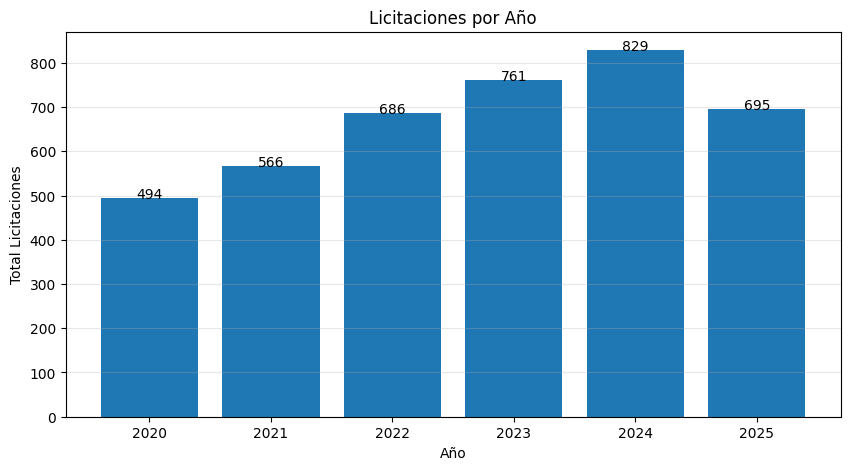

In [267]:
# =========================================================
# LICITACIONES POR AÑO + GRÁFICOS
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. PREPARACIÓN
# ---------------------------------------------------------
df_anual = df_final.copy()

# asegurar formato fecha
df_anual['FechaCierre'] = pd.to_datetime(df_anual['FechaCierre'])

# extraer año
df_anual['anio'] = df_anual['FechaCierre'].dt.year

# ---------------------------------------------------------
# 2. AGRUPACIÓN
# ---------------------------------------------------------
licitaciones_por_anio = (
    df_anual
    .groupby('anio')
    .size()
    .reset_index(name='total_licitaciones')
    .sort_values('anio')
)

print("Licitaciones por año:")
display(licitaciones_por_anio)

# ---------------------------------------------------------
# 3. GRÁFICO LICITACIONES POR AÑO
# ---------------------------------------------------------
plt.figure(figsize=(10,5))

plt.bar(
    licitaciones_por_anio['anio'],
    licitaciones_por_anio['total_licitaciones']
)

# valores arriba de cada barra
for x, y in zip(
    licitaciones_por_anio['anio'],
    licitaciones_por_anio['total_licitaciones']
):
    plt.text(x, y, f"{y}", ha='center', fontsize=10)

plt.title("Licitaciones por Año")
plt.xlabel("Año")
plt.ylabel("Total Licitaciones")

plt.grid(axis='y', alpha=0.3)

plt.show()

In [268]:
# ---------------------------------------------------------
# 4. REORDENAMOS LAS COLUMNAS
# ---------------------------------------------------------

# 1. Obtenemos la lista de todas las columnas
cols = df_final.columns.tolist()

# 2. Reorganizamos la lista:
# [0:5] son los primeros 4 campos (índices 0, 1, 2, 3, 4)
# [14:] son tus campos objetivo (índices 14, 15, 16)
# [4:14] son el resto de los campos intermedios
new_order = cols[:5] + cols[14:] + cols[5:14]

# 3. Aplicamos el nuevo orden al dataframe
df_final = df_final[new_order]


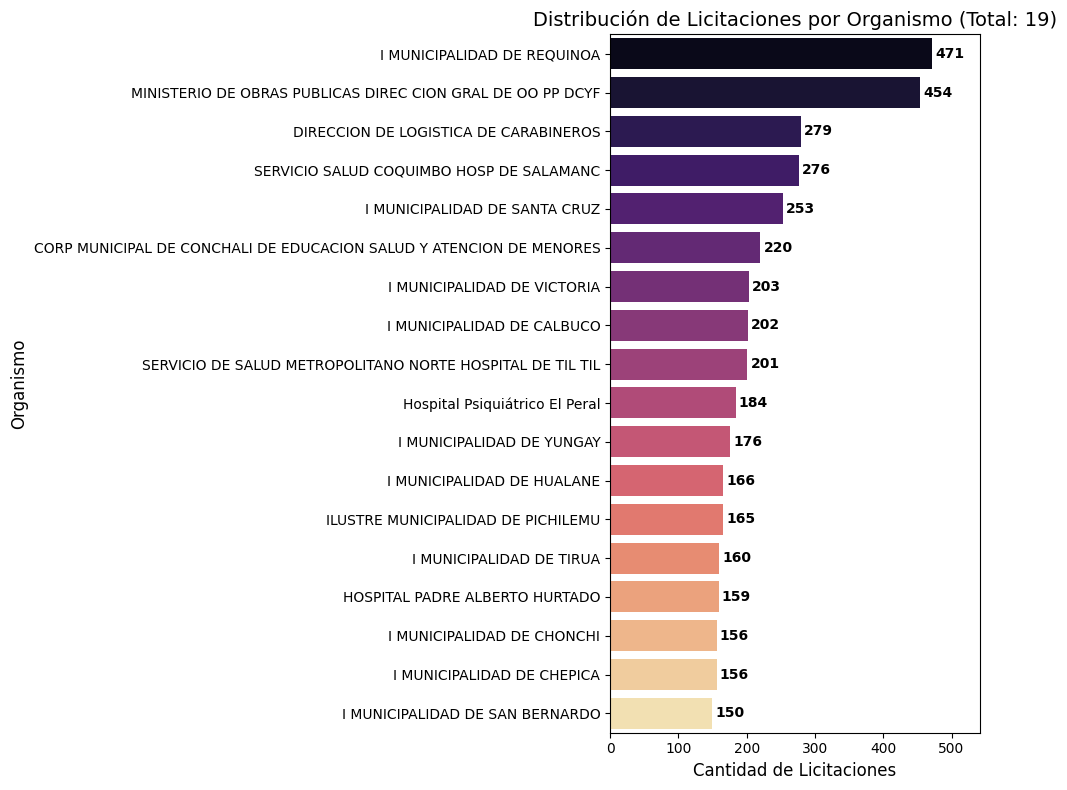

In [269]:
# ---------------------------------------------------------
# 5. GRAFICO DE DISTRIBUCIÓN DE LICITACIONES POR ORGANISMO
# ---------------------------------------------------------

import seaborn as sns

# 1. Obtener la cuenta de todos los organismos (sin nulos)
conteo_organismos = df_final['nombre_organismo'].dropna().value_counts()

# 2. Configurar el tamaño (ajusté la altura a 8 para que los 19 nombres quepan)
plt.figure(figsize=(10, 8))

# 3. Crear el gráfico de barras horizontales
ax = sns.barplot(x=conteo_organismos.values,
                 y=conteo_organismos.index.astype(str),
                 hue=conteo_organismos.index.astype(str),
                 palette='magma',
                 legend=False)

# 4. Añadir etiquetas con el valor exacto al final de cada barra
for i, v in enumerate(conteo_organismos.values):
    ax.text(v + (conteo_organismos.max() * 0.01), i,
            format(v, ',.0f'),
            va='center', fontsize=10, fontweight='bold')

# 5. Personalización de títulos y ejes
plt.title('Distribución de Licitaciones por Organismo (Total: 19)', fontsize=14)
plt.xlabel('Cantidad de Licitaciones', fontsize=12)
plt.ylabel('Organismo', fontsize=12)

# Dejamos un 15% de margen extra a la derecha para que el número no se corte
plt.xlim(0, conteo_organismos.max() * 1.15)

plt.tight_layout()
plt.show()



## 📦 Código — Paso 1: Modelo Base (Regresión Lineal)

### Desarrollo de la regresión lineal.

In [270]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [271]:
# =========================================================
# MODELO 1 — REGRESION LINEAL (SERIE TEMPORAL)
# =========================================================

# ---------------------------------------------------------
# 1. COPIA DEL DATASET
# ---------------------------------------------------------
df_model_m1 = df_final.copy()

# ---------------------------------------------------------
# 2. CREACIÓN DE VARIABLE TEMPORAL (AÑO-MES)
# ---------------------------------------------------------
df_model_m1['year_month'] = df_model_m1['FechaCierre'].dt.to_period('M')

# ---------------------------------------------------------
# 3. AGREGACIÓN MENSUAL
# ---------------------------------------------------------
serie_m1 = (
    df_model_m1
    .groupby('year_month')
    .size()
    .reset_index(name='licitaciones')
)

# ---------------------------------------------------------
# 4. CONVERSIÓN A TIMESTAMP
# ---------------------------------------------------------
serie_m1['year_month'] = serie_m1['year_month'].dt.to_timestamp()

# ---------------------------------------------------------
# 5. ASEGURAR CONTINUIDAD TEMPORAL
# ---------------------------------------------------------
serie_m1 = (
    serie_m1
    .set_index('year_month')
    .asfreq('MS')  # Monthly Start
    .fillna(0)
    .reset_index()
)

# ---------------------------------------------------------
# 6. VALIDACIÓN
# ---------------------------------------------------------
print("Serie temporal creada correctamente:")
print(f"Total registros: {len(serie_m1)}")
print(f"Rango: {serie_m1['year_month'].min()} → {serie_m1['year_month'].max()}")

display(serie_m1.head())

Serie temporal creada correctamente:
Total registros: 72
Rango: 2020-01-01 00:00:00 → 2025-12-01 00:00:00


,year_month,licitaciones
0,2020-01-01,62
1,2020-02-01,118
2,2020-03-01,37
3,2020-04-01,11
4,2020-05-01,16


Nota: Este código prepara los datos para un modelo de regresión lineal convirtiendo el dataset original en una serie temporal mensual. Primero copia los datos y transforma la fecha de cierre en formato año-mes. Luego agrupa las licitaciones por mes y cuenta cuántas ocurren en cada período. Finalmente, convierte la variable temporal a formato fecha para que pueda ser utilizada en modelos y visualizaciones. En esencia, transforma datos individuales en una estructura agregada lista para análisis predictivo.

In [272]:
df_model_m1.head()

,CodigoExterno,Nombre,CodigoEstado,FechaCierre,codigo_organismo,nombre_organismo,region_unidad,correlativo,tipo_anio,codigo_tipo,anio_licitacion,tipo_raw,tipo_base,anio,mes,ranking_estrategico,year_month
0,3794-3-LE20,PASAJES AEREOS EN EL TRAMO ISLA ROBINSON CRUSO...,8,2020-01-13 15:00:00,3794,DIRECCION DE LOGISTICA DE CARABINEROS,Región RM,3,LE20,LE,20,LE20,Publica,2020,1,7,2020-01
1,3656-1-LE20,SERVICIO DE ASEO DIFERENTES DEPENDENCIAS MUNIC...,8,2020-01-13 15:01:00,3656,I MUNICIPALIDAD DE REQUINOA,Región del Libertador General Bernardo O´Higgins,1,LE20,LE,20,LE20,Publica,2020,1,4,2020-01
2,3656-2-LE20,PRODUCCIÓN TÉCNICA Y ARTISTICA SEMANA LIRIANA,8,2020-01-13 16:00:00,3656,I MUNICIPALIDAD DE REQUINOA,Región del Libertador General Bernardo O´Higgins,2,LE20,LE,20,LE20,Publica,2020,1,4,2020-01
3,3794-5-LE20,FLETE INTERNACIONAL MENAJE BOGOTÁ (COLOMBIA)–B...,8,2020-01-20 15:00:00,3794,DIRECCION DE LOGISTICA DE CARABINEROS,Región RM,5,LE20,LE,20,LE20,Publica,2020,1,7,2020-01
4,1509-2-LE20,MANTENCION EQUIPOS DE CLIMATIZACION HCTT,8,2020-01-17 11:10:00,1509,SERVICIO DE SALUD METROPOLITANO NORTE HOSPITAL...,Región RM,2,LE20,LE,20,LE20,Publica,2020,1,16,2020-01


In [273]:
df_model_m1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4031 entries, 0 to 4030
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CodigoExterno        4031 non-null   object        
 1   Nombre               4031 non-null   object        
 2   CodigoEstado         4031 non-null   int64         
 3   FechaCierre          4031 non-null   datetime64[ns]
 4   codigo_organismo     4031 non-null   object        
 5   nombre_organismo     4031 non-null   object        
 6   region_unidad        4031 non-null   object        
 7   correlativo          4031 non-null   object        
 8   tipo_anio            4031 non-null   object        
 9   codigo_tipo          4031 non-null   object        
 10  anio_licitacion      4031 non-null   Int64         
 11  tipo_raw             4031 non-null   object        
 12  tipo_base            4031 non-null   object        
 13  anio                 4031 non-nul

In [274]:
print("Serie temporal:")
display(serie_m1.head())

Serie temporal:


,year_month,licitaciones
0,2020-01-01,62
1,2020-02-01,118
2,2020-03-01,37
3,2020-04-01,11
4,2020-05-01,16


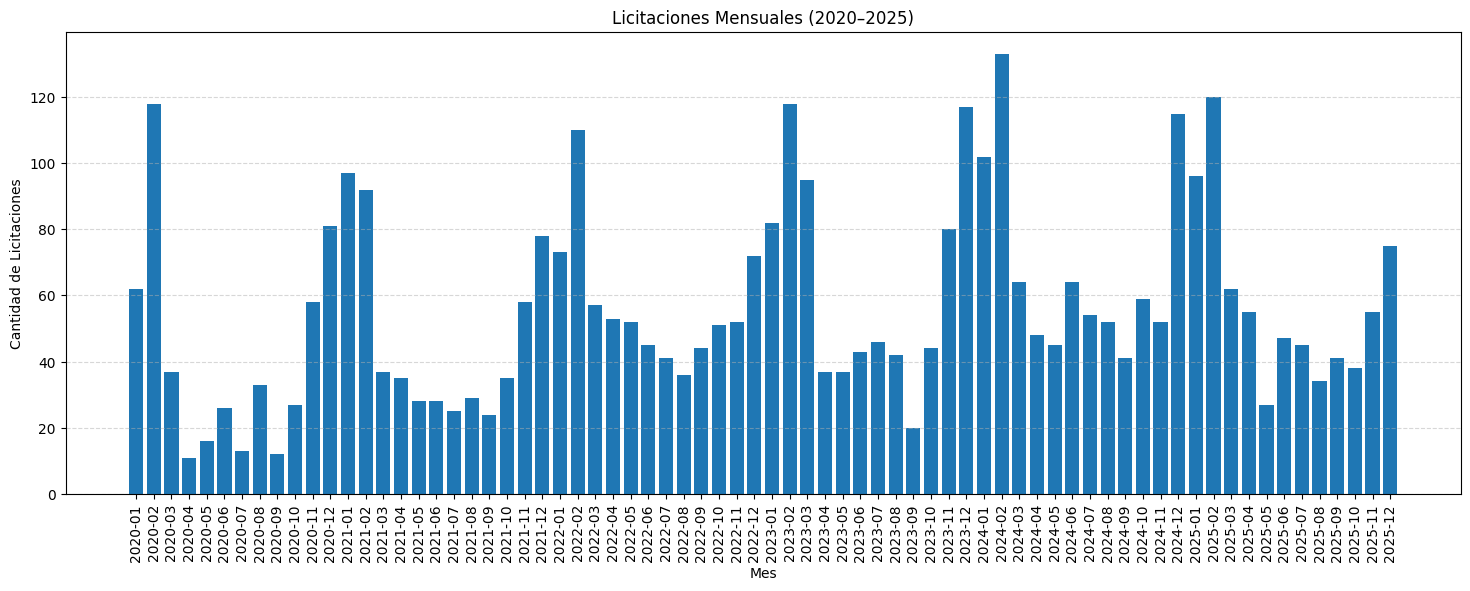

In [275]:
# =========================================================
# GRÁFICO DE BARRAS — LICITACIONES MENSUALES (2020–2025)
# =========================================================

import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------------------------------------
# FILTRO ROBUSTO (MEJORA APLICADA)
# ---------------------------------------------------------
start = pd.Timestamp('2020-01-01')
end = pd.Timestamp('2025-12-01')

serie_plot = serie_m1[
    (serie_m1['year_month'] >= start) &
    (serie_m1['year_month'] <= end)
].copy()

# crear etiqueta tipo YYYY-MM
serie_plot['label'] = serie_plot['year_month'].dt.strftime('%Y-%m')

# gráfico
plt.figure(figsize=(18,6))
plt.bar(serie_plot['label'], serie_plot['licitaciones'])

plt.title("Licitaciones Mensuales (2020–2025)")
plt.xlabel("Mes")
plt.ylabel("Cantidad de Licitaciones")

plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [276]:
# =========================================================
# 2. FEATURE ENGINEERING (SIN LEAKAGE)
# =========================================================

# ---------------------------------------------------------
# 1. COPIA BASE
# ---------------------------------------------------------
serie_feat_m1 = serie_m1.copy()

# ---------------------------------------------------------
# 2. VARIABLES TEMPORALES
# ---------------------------------------------------------
serie_feat_m1['mes'] = serie_feat_m1['year_month'].dt.month
serie_feat_m1['anio'] = serie_feat_m1['year_month'].dt.year
serie_feat_m1['trend'] = np.arange(len(serie_feat_m1))

# ---------------------------------------------------------
# 3. LAGS (SOLO PASADO)
# ---------------------------------------------------------
serie_feat_m1['lag_1'] = serie_feat_m1['licitaciones'].shift(1)
serie_feat_m1['lag_2'] = serie_feat_m1['licitaciones'].shift(2)
serie_feat_m1['lag_3'] = serie_feat_m1['licitaciones'].shift(3)

# ---------------------------------------------------------
# 4. ROLLING (SOLO PASADO)
# ---------------------------------------------------------
serie_feat_m1['rolling_3'] = (
    serie_feat_m1['licitaciones']
    .shift(1)
    .rolling(3)
    .mean()
)

print("Antes dropna:", len(serie_feat_m1))

# ---------------------------------------------------------
# 5. DATASET LIMPIO (SIN SOBRESCRIBIR)
# ---------------------------------------------------------
serie_model_m1 = serie_feat_m1.dropna().reset_index(drop=True)

print("Después dropna:", len(serie_model_m1))

print("\nDataset modelable:")
display(serie_model_m1.head())

Antes dropna: 72
Después dropna: 69

Dataset modelable:


,year_month,licitaciones,mes,anio,trend,lag_1,lag_2,lag_3,rolling_3
0,2020-04-01,11,4,2020,3,37.0,118.0,62.0,72.333333
1,2020-05-01,16,5,2020,4,11.0,37.0,118.0,55.333333
2,2020-06-01,26,6,2020,5,16.0,11.0,37.0,21.333333
3,2020-07-01,13,7,2020,6,26.0,16.0,11.0,17.666667
4,2020-08-01,33,8,2020,7,13.0,26.0,16.0,18.333333


In [277]:
# =========================================================
# 3. TRAIN / TEST (TEMPORAL)
# =========================================================

# ---------------------------------------------------------
# 1. SPLIT TEMPORAL
# ---------------------------------------------------------
train_m1 = serie_model_m1.iloc[:-12]
test_m1 = serie_model_m1.iloc[-12:]

# ---------------------------------------------------------
# 2. FEATURES / TARGET
# ---------------------------------------------------------
X_train_m1 = train_m1.drop(['licitaciones', 'year_month'], axis=1)
y_train_m1 = train_m1['licitaciones']

X_test_m1 = test_m1.drop(['licitaciones', 'year_month'], axis=1)
y_test_m1 = test_m1['licitaciones']

# ---------------------------------------------------------
# 3. VALIDACIÓN
# ---------------------------------------------------------
print(f"Train: {len(train_m1)} | Test: {len(test_m1)}")

Train: 57 | Test: 12


In [278]:
print("Antes dropna:", len(serie_feat_m1))

serie_feat_m1 = serie_feat_m1.dropna().reset_index(drop=True)

print("Después dropna:", len(serie_feat_m1))

Antes dropna: 72
Después dropna: 69


NOTA: Este código crea variables que ayudan al modelo a entender el comportamiento de las licitaciones en el tiempo usando solo información pasada. Por ejemplo, si en enero hubo 100, febrero 120 y marzo 90 licitaciones, al predecir abril (110), el modelo usa lag_1=90, lag_2=120 y lag_3=100, es decir, los valores de meses anteriores. También calcula un promedio móvil (rolling_3 ≈ 103) con esos meses para captar la tendencia reciente. Además, incorpora variables como mes, año y una tendencia general del tiempo. Finalmente, elimina los primeros registros que no tienen historial suficiente, dejando el dataset listo para entrenar sin usar datos del futuro.

JUSTIFICACION DE HORIZONTE DE 3 MESES: Se definió una ventana de 3 meses (lags y rolling) porque el objetivo del modelo es predecir el comportamiento operativo de corto plazo de las licitaciones, donde la evidencia muestra que la actividad reciente tiene mayor capacidad predictiva que información más antigua. En el mercado público, si bien existe una estacionalidad anual asociada al ciclo presupuestario, las decisiones reales de licitación responden a ajustes mensuales, urgencias administrativas y ritmos de ejecución que se manifiestan en horizontes cortos. Utilizar 3 meses permite capturar esta dinámica de forma eficiente, reducir ruido histórico, evitar sobreajuste y mantener un mayor volumen de datos útiles para el entrenamiento. La estacionalidad anual no se pierde, ya que se incorpora mediante variables como el mes y el año. En este contexto, la elección de 3 meses representa el mejor equilibrio entre capacidad predictiva, robustez del modelo y coherencia con la lógica operativa del negocio.

“Se utilizó una partición temporal del dataset, reservando los últimos 12 meses como conjunto de validación, simulando condiciones reales de predicción futura.”

In [279]:
# =========================================================
# 4. MODELO
# =========================================================

# validar features
print("Features utilizadas:")
print(X_train_m1.columns)

# entrenamiento
lr_model_m1 = LinearRegression()
lr_model_m1.fit(X_train_m1, y_train_m1)

print("\nModelo entrenado correctamente")

Features utilizadas:
Index(['mes', 'anio', 'trend', 'lag_1', 'lag_2', 'lag_3', 'rolling_3'], dtype='object')

Modelo entrenado correctamente


In [280]:
# =========================================================
# 5. PREDICCIÓN
# =========================================================

pred_lr_m1 = lr_model_m1.predict(X_test_m1)

# control de negocio: no valores negativos
pred_lr_m1 = np.clip(pred_lr_m1, a_min=0, a_max=None)

# convertir a serie (mejor trazabilidad)
pred_lr_m1 = pd.Series(pred_lr_m1, index=y_test_m1.index)

print("Predicciones generadas correctamente")

Predicciones generadas correctamente


In [281]:
# =========================================================
# 6. MÉTRICAS
# =========================================================

mae_lr_m1 = mean_absolute_error(y_test_m1, pred_lr_m1)
rmse_lr_m1 = np.sqrt(mean_squared_error(y_test_m1, pred_lr_m1))
mape_lr_m1 = np.mean(np.abs((y_test_m1 - pred_lr_m1) / (y_test_m1 + 1e-8))) * 100

print("\n" + "="*60)
print("MODELO 1 — REGRESIÓN LINEAL")
print("="*60)
print("MAE :", round(mae_lr_m1, 2))
print("RMSE:", round(rmse_lr_m1, 2))
print("MAPE:", round(mape_lr_m1, 2), "%")

print("\nInterpretación:")
print(f"Error promedio: {mae_lr_m1:.2f} licitaciones")
print(f"Error porcentual: {mape_lr_m1:.2f}%")


MODELO 1 — REGRESIÓN LINEAL
MAE : 18.69
RMSE: 21.92
MAPE: 41.64 %

Interpretación:
Error promedio: 18.69 licitaciones
Error porcentual: 41.64%


El modelo presenta un MAE de 18.69, lo que indica un error promedio de ~19 licitaciones por mes. El RMSE de 21.92 confirma que los errores grandes no son extremos, pero sí relevantes. El MAPE de 41.64% evidencia un alto error porcentual, reflejando baja precisión predictiva. En conjunto, los indicadores muestran que el modelo lineal no captura la complejidad del patrón temporal. Esto justifica la necesidad de utilizar modelos más avanzados no lineales.

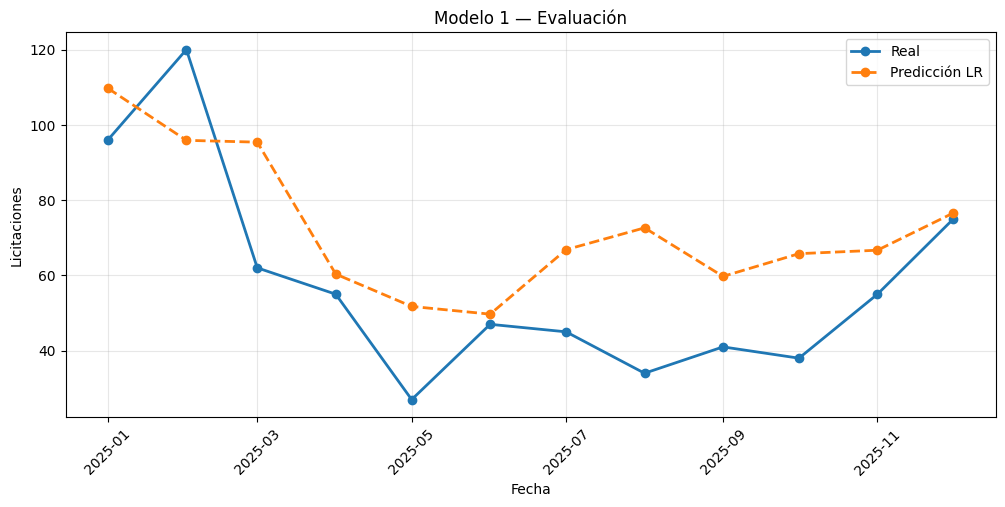

In [282]:
# =========================================================
# 7. VISUALIZACIÓN TEST
# =========================================================

plt.figure(figsize=(12,5))

# real
plt.plot(
    test_m1['year_month'],
    y_test_m1,
    label='Real',
    marker='o',
    linewidth=2
)

# predicción
plt.plot(
    test_m1['year_month'],
    pred_lr_m1,
    label='Predicción LR',
    marker='o',
    linestyle='--',
    linewidth=2
)

# estética
plt.legend()
plt.title("Modelo 1 — Evaluación")
plt.xlabel("Fecha")
plt.ylabel("Licitaciones")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.show()

El modelo lineal muestra una tendencia suavizada respecto a los valores reales, sin capturar bien los picos y caídas. Se observa una subestimación en meses altos (ej. febrero) y sobreestimación en meses bajos (ej. mayo–agosto). La predicción sigue la dirección general, pero pierde variabilidad. Esto confirma que el modelo no captura adecuadamente la estacionalidad ni la volatilidad del mercado. En consecuencia, su capacidad predictiva es limitada para este problema.

In [283]:
# =========================================================
# 8. FORECAST (2026) — VERSIÓN CORREGIDA
# =========================================================

future_m1 = serie_model_m1.copy()

for i in range(12):

    last = future_m1.iloc[-1]

    # crear nuevo registro limpio
    new = {}

    # avanzar mes
    new['year_month'] = last['year_month'] + pd.DateOffset(months=1)

    # variables temporales
    new['mes'] = new['year_month'].month
    new['anio'] = new['year_month'].year
    new['trend'] = last['trend'] + 1

    # lags
    new['lag_1'] = last['licitaciones']
    new['lag_2'] = last['lag_1']
    new['lag_3'] = last['lag_2']

    # rolling
    new['rolling_3'] = np.mean([
        last['licitaciones'],
        last['lag_1'],
        last['lag_2']
    ])

    # convertir a DataFrame
    new_df = pd.DataFrame([new])

    # predicción
    X_new = new_df[X_train_m1.columns]
    pred_val = lr_model_m1.predict(X_new)[0]

    # control negocio
    new_df['licitaciones'] = max(pred_val, 0)

    # append
    future_m1 = pd.concat([future_m1, new_df], ignore_index=True)

# resultado final
forecast_m1 = future_m1.tail(12)

print("\nFORECAST 2026:")
display(forecast_m1[['year_month','licitaciones']])


FORECAST 2026:


,year_month,licitaciones
69,2026-01-01,93.561053
70,2026-02-01,100.558916
71,2026-03-01,98.905886
72,2026-04-01,92.337255
73,2026-05-01,86.131519
74,2026-06-01,82.870907
75,2026-07-01,82.994125
76,2026-08-01,85.173574
77,2026-09-01,87.750488
78,2026-10-01,89.535951


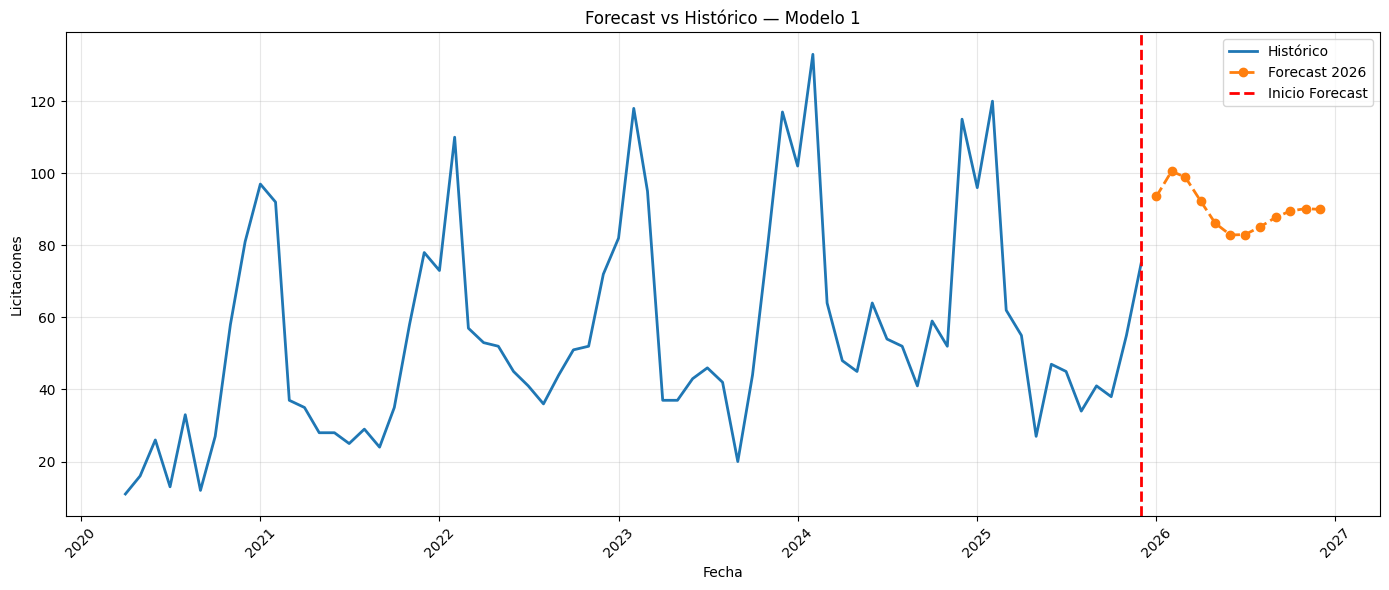

In [284]:
# =========================================================
# 9. VISUALIZACIÓN — HISTÓRICO VS FORECAST
# =========================================================

plt.figure(figsize=(14,6))

# ---------------------------------------------------------
# HISTÓRICO (CONSISTENTE CON MODELO)
# ---------------------------------------------------------
plt.plot(
    serie_model_m1['year_month'],
    serie_model_m1['licitaciones'],
    label='Histórico',
    linewidth=2
)

# ---------------------------------------------------------
# FORECAST (solo 2026)
# ---------------------------------------------------------
plt.plot(
    forecast_m1['year_month'],
    forecast_m1['licitaciones'],
    label='Forecast 2026',
    linewidth=2,
    linestyle='--',
    marker='o'
)

# ---------------------------------------------------------
# LÍNEA DE CORTE
# ---------------------------------------------------------
plt.axvline(
    x=serie_model_m1['year_month'].max(),
    color='red',
    linestyle='--',
    linewidth=2,
    label='Inicio Forecast'
)

# ---------------------------------------------------------
# ESTÉTICA
# ---------------------------------------------------------
plt.title("Forecast vs Histórico — Modelo 1")
plt.xlabel("Fecha")
plt.ylabel("Licitaciones")

plt.legend()
plt.grid(alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [285]:
# =========================================================
# 10. COEFICIENTES
# =========================================================

coef_df_m1 = pd.DataFrame({
    'feature': X_train_m1.columns,
    'coef': lr_model_m1.coef_
})

# importancia absoluta
coef_df_m1['abs_coef'] = coef_df_m1['coef'].abs()

# ordenar por impacto
coef_df_m1 = coef_df_m1.sort_values('abs_coef', ascending=False)

print("\nCoeficientes (ordenados por impacto):")
display(coef_df_m1)

# top variables
print("\nTop variables más influyentes:")
display(coef_df_m1.head(5))


Coeficientes (ordenados por impacto):


,feature,coef,abs_coef
3,lag_1,0.651461,0.651461
2,trend,0.432088,0.432088
5,lag_3,-0.313266,0.313266
0,mes,-0.259140,0.259140
6,rolling_3,0.086889,0.086889
4,lag_2,-0.077528,0.077528
1,anio,0.057602,0.057602



Top variables más influyentes:


,feature,coef,abs_coef
3,lag_1,0.651461,0.651461
2,trend,0.432088,0.432088
5,lag_3,-0.313266,0.313266
0,mes,-0.259140,0.259140
6,rolling_3,0.086889,0.086889


El modelo indica que lo más importante para predecir las licitaciones de un mes es lo que ocurrió el mes anterior (lag_1). Por ejemplo, si en marzo hubo muchas licitaciones, es muy probable que en abril también haya un nivel similar. Además, existe una tendencia general al alza en el tiempo (trend), lo que sugiere que el volumen de licitaciones ha ido creciendo. Algunas variables como el mes (mes) muestran que hay ciertos períodos del año con más o menos actividad, pero su impacto es menor. En resumen, el modelo se basa principalmente en el comportamiento reciente y en una tendencia general, sin capturar patrones más complejos del mercado.
Se usa el coeficiente absoluto para medir la fuerza real de cada variable, independientemente de si aumenta o disminuye el resultado.


**Variables del Modelo de Regresión**

| Variable     | ¿Para qué sirve?                          | ¿Qué representa en este proyecto?                                      |
|-------------|-------------------------------------------|------------------------------------------------------------------------|
| **lag_1**    | Captura el efecto inmediato del pasado    | Licitaciones del mes anterior (principal predictor del modelo)         |
| **lag_2**    | Complementa la memoria temporal           | Licitaciones de hace 2 meses
| **lag_3**    | Captura efectos de mediano plazo          | Licitaciones de hace 3 meses (posibles ciclos operativos)              |
| **trend**    | Modela la tendencia en el tiempo          | Crecimiento o disminución del volumen de licitaciones en el tiempo     |
| **mes**      | Captura estacionalidad                    | Variaciones según el mes (ej: diciembre alto, febrero bajo)            |
| **rolling_3**| Suaviza la serie y muestra tendencia      | Promedio de licitaciones de los últimos 3 meses|                                          
| **anio**     | Captura cambios estructurales             | Diferencias entre años (ej: 2020 vs 2025)     


In [286]:
# =========================================================
# 11. GENERACION DE METRICAS PARA EVALUACIÓN INTEGRAL — MODELO 1 (REGRESIÓN LINEAL)
# =========================================================

# =========================================================
# 1. MÉTRICAS PRINCIPALES
# =========================================================

mae_m1 = np.mean(np.abs(y_test_m1 - pred_lr_m1))
rmse_m1 = np.sqrt(np.mean((y_test_m1 - pred_lr_m1)**2))
mape_m1 = np.mean(np.abs((y_test_m1 - pred_lr_m1) / (y_test_m1 + 1e-8))) * 100

# =========================================================
# 2. MÉTRICAS COMPLEMENTARIAS
# =========================================================

bias_m1 = np.mean(pred_lr_m1 - y_test_m1)
max_error_m1 = np.max(np.abs(y_test_m1 - pred_lr_m1))
std_error_m1 = np.std(y_test_m1 - pred_lr_m1)
cv_error_m1 = std_error_m1 / (np.mean(y_test_m1) + 1e-8)

# =========================================================
# 3. DATAFRAME DE ERRORES
# =========================================================

df_eval_m1 = pd.DataFrame({
    'fecha': test_m1['year_month'],
    'real': y_test_m1,
    'pred': pred_lr_m1
}).reset_index(drop=True)

df_eval_m1['error'] = df_eval_m1['real'] - df_eval_m1['pred']
df_eval_m1['error_abs'] = np.abs(df_eval_m1['error'])
df_eval_m1['error_pct'] = (df_eval_m1['error_abs'] / (df_eval_m1['real'] + 1e-8)) * 100

# =========================================================
# 4. ANÁLISIS DE TENDENCIA
# =========================================================

trend_real_m1 = np.polyfit(range(len(y_test_m1)), y_test_m1, 1)[0]
trend_pred_m1 = np.polyfit(range(len(pred_lr_m1)), pred_lr_m1, 1)[0]

# =========================================================
# 5. IMPRESIÓN RESULTADOS
# =========================================================

print("\n" + "="*70)
print("EVALUACIÓN INTEGRAL — MODELO 1 (REGRESIÓN LINEAL)")
print("="*70)

print("\n MÉTRICAS PRINCIPALES")
print(f"MAE   : {mae_m1:.2f}")
print(f"RMSE  : {rmse_m1:.2f}")
print(f"MAPE  : {mape_m1:.2f}%")

print("\n MÉTRICAS COMPLEMENTARIAS")
print(f"Bias (sesgo)           : {bias_m1:.2f}")
print(f"Error máximo           : {max_error_m1:.2f}")
print(f"Std error              : {std_error_m1:.2f}")
print(f"CV error               : {cv_error_m1:.2f}")

print("\n TENDENCIA")
print(f"Tendencia real         : {trend_real_m1:.2f}")
print(f"Tendencia predicha     : {trend_pred_m1:.2f}")

print("\n DETALLE DE ERRORES:")
display(df_eval_m1)


EVALUACIÓN INTEGRAL — MODELO 1 (REGRESIÓN LINEAL)

 MÉTRICAS PRINCIPALES
MAE   : 18.69
RMSE  : 21.92
MAPE  : 41.64%

 MÉTRICAS COMPLEMENTARIAS
Bias (sesgo)           : 14.67
Error máximo           : 38.63
Std error              : 16.28
CV error               : 0.28

 TENDENCIA
Tendencia real         : -3.62
Tendencia predicha     : -2.65

 DETALLE DE ERRORES:


,fecha,real,pred,error,error_abs,error_pct
0,2025-01-01,96,109.710669,-13.710669,13.710669,14.281947
1,2025-02-01,120,95.886071,24.113929,24.113929,20.094941
2,2025-03-01,62,95.400831,-33.400831,33.400831,53.872309
3,2025-04-01,55,60.345408,-5.345408,5.345408,9.718923
4,2025-05-01,27,51.748913,-24.748913,24.748913,91.662640
5,2025-06-01,47,49.699539,-2.699539,2.699539,5.743700
6,2025-07-01,45,66.830908,-21.830908,21.830908,48.513130
7,2025-08-01,34,72.632186,-38.632186,38.632186,113.624076
8,2025-09-01,41,59.731545,-18.731545,18.731545,45.686696
9,2025-10-01,38,65.770282,-27.770282,27.770282,73.079691


Interpretación de Métricas — Modelo de Regresión Lineal

| Métrica            | ¿Para qué sirve?                                   | ¿Qué representa en este proyecto?                                                                 |
|-------------------|----------------------------------------------------|--------------------------------------------------------------------------------------------------|
| **MAE**            | Mide el error promedio absoluto                    | En promedio, el modelo se equivoca en ~19 licitaciones por mes                                  |
| **RMSE**           | Penaliza errores grandes                           | Confirma que existen meses con errores relevantes (más sensibles a grandes desviaciones)        |
| **MAPE**           | Mide el error en porcentaje                        | El modelo tiene un error de ~42%, lo que indica baja precisión predictiva                       |
| **Bias (sesgo)**   | Indica si el modelo sobre o subestima              | El modelo tiende a sobreestimar en promedio ~15 licitaciones por mes                            |
| **Error máximo**   | Mide el peor error observado                       | En el peor mes, el modelo se equivoca en ~39 licitaciones                                       |
| **Std error**      | Mide la dispersión del error                       | Los errores varían bastante entre meses (alta volatilidad en el desempeño)                      |
| **CV error**       | Relaciona error con el promedio real               | El error equivale al 28% del valor promedio → nivel alto                                         |
| **Tendencia real** | Mide la dirección real de la serie                 | Las licitaciones presentan una tendencia decreciente en el tiempo                               |
| **Tendencia predicha** | Mide la tendencia que capta el modelo         | El modelo detecta la tendencia, pero la suaviza (no capta la magnitud real)                     |
| **Detalle de errores** | Permite análisis mes a mes                    | Identifica en qué meses el modelo falla más (ej: meses de baja actividad con alto error %)      |

In [287]:
print("\n" + "="*60)
print("MODELO 1 — REGRESIÓN LINEAL")
print("="*60)
print("MAE  :", round(mae_lr_m1,2))
print("RMSE :", round(rmse_lr_m1,2))
print("MAPE :", round(mape_lr_m1,2), "%")
print("BIAS :", round(np.mean(pred_lr_m1 - y_test_m1), 2))
print("STD  :", round(np.std(y_test_m1 - pred_lr_m1), 2))


MODELO 1 — REGRESIÓN LINEAL
MAE  : 18.69
RMSE : 21.92
MAPE : 41.64 %
BIAS : 14.67
STD  : 16.28


### Conclusion Modelo 1 / Regresion Lineal - Evaluación de desempeño + diagnóstico del modelo.

Evaluación de desempeño + diagnóstico del modelo

El modelo de regresión lineal fue implementado como una primera aproximación para predecir la evolución mensual de las licitaciones, utilizando variables temporales y rezagos (lags) con el objetivo de capturar la dinámica histórica del sistema.

Desde el punto de vista cuantitativo, el modelo presenta un desempeño limitado. El error absoluto medio (MAE ≈ 18.69) indica desviaciones relevantes en términos operativos, mientras que el RMSE (≈ 21.92) confirma la presencia de errores significativos en ciertos períodos. El MAPE (≈ 41.64%) evidencia una baja precisión predictiva, lo que posiciona al modelo fuera de un estándar aceptable para uso productivo.

A nivel de comportamiento, el modelo muestra una fuerte dependencia del mes anterior (lag_1), lo que confirma que la serie tiene una inercia relevante. Sin embargo, esta dependencia genera una predicción excesivamente suavizada. En la práctica, esto se traduce en un sesgo sistemático: el modelo tiende a sobreestimar los meses de baja actividad y a subestimar los meses de alta actividad, como se observa en errores elevados en meses con menor volumen de licitaciones (superiores incluso al 90% en algunos casos).

El análisis de tendencia muestra que el modelo logra capturar la dirección general del sistema (tendencia decreciente), pero no su magnitud ni su variabilidad. Esto confirma que la regresión lineal no logra adaptarse a cambios bruscos ni a la volatilidad propia del mercado público. Adicionalmente, el esquema de forecast autoregresivo introduce acumulación de errores en el tiempo, reduciendo la confiabilidad de las proyecciones a futuro.

Desde una perspectiva de negocio, el modelo no es adecuado para la toma de decisiones estratégicas, ya que no permite estimar con precisión ni el volumen ni la temporalidad de las licitaciones. No obstante, cumple un rol fundamental como modelo base (baseline), permitiendo validar el pipeline de datos, entender la estructura del problema y evidenciar la necesidad de utilizar modelos más avanzados.

En conclusión, la regresión lineal no logra capturar la complejidad del mercado público, caracterizado por comportamientos no lineales, estacionalidad y alta variabilidad. Su principal valor radica en servir como punto de comparación inicial y en justificar la transición hacia modelos más robustos, como Random Forest, XGBoost o enfoques híbridos que integren lógica de negocio con técnicas de machine learning.

## 📦 Código — Paso 2: Modelo Random Forest.

### Desarrollo del Modelo Random Forest.

In [288]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

In [289]:
# =========================================================
# 1. DATASET TEMPORAL (df_final)
# =========================================================

# ---------------------------------------------------------
# 1. COPIA DEL DATASET
# ---------------------------------------------------------
df_model_m2 = df_final.copy()

# ---------------------------------------------------------
# 2. CREACIÓN VARIABLE TEMPORAL (AÑO-MES)
# ---------------------------------------------------------
df_model_m2['year_month'] = df_model_m2['FechaCierre'].dt.to_period('M')

# ---------------------------------------------------------
# 3. AGREGACIÓN MENSUAL
# ---------------------------------------------------------
serie_m2 = (
    df_model_m2
    .groupby('year_month')
    .size()
    .reset_index(name='licitaciones')
)

# ---------------------------------------------------------
# 4. CONVERSIÓN A TIMESTAMP
# ---------------------------------------------------------
serie_m2['year_month'] = serie_m2['year_month'].dt.to_timestamp()

# ---------------------------------------------------------
# 5. ASEGURAR CONTINUIDAD TEMPORAL (CLAVE)
# ---------------------------------------------------------
serie_m2 = (
    serie_m2
    .set_index('year_month')
    .asfreq('MS')
    .fillna(0)
    .reset_index()
)

# ---------------------------------------------------------
# 6. VALIDACIÓN
# ---------------------------------------------------------
print("Serie temporal creada correctamente:")
print(f"Total registros: {len(serie_m2)}")
print(f"Rango: {serie_m2['year_month'].min()} → {serie_m2['year_month'].max()}")

display(serie_m2.head())

Serie temporal creada correctamente:
Total registros: 72
Rango: 2020-01-01 00:00:00 → 2025-12-01 00:00:00


,year_month,licitaciones
0,2020-01-01,62
1,2020-02-01,118
2,2020-03-01,37
3,2020-04-01,11
4,2020-05-01,16


Se construyó una serie temporal mensual continua a partir de los datos transaccionales, asegurando consistencia temporal y evitando discontinuidades que puedan afectar el modelado.

In [290]:
# =========================================================
# 2. FEATURE ENGINEERING (SIN LEAKAGE)
# =========================================================

# ---------------------------------------------------------
# 1. COPIA BASE (NO MODIFICAR SERIE ORIGINAL)
# ---------------------------------------------------------
serie_feat_m2 = serie_m2.copy()

# ---------------------------------------------------------
# 2. VARIABLES TEMPORALES
# ---------------------------------------------------------
serie_feat_m2['mes'] = serie_feat_m2['year_month'].dt.month
serie_feat_m2['anio'] = serie_feat_m2['year_month'].dt.year
serie_feat_m2['trimestre'] = serie_feat_m2['year_month'].dt.quarter
serie_feat_m2['trend'] = np.arange(len(serie_feat_m2))

# ---------------------------------------------------------
# 3. LAGS (SOLO PASADO)
# ---------------------------------------------------------
serie_feat_m2['lag_1'] = serie_feat_m2['licitaciones'].shift(1)
serie_feat_m2['lag_2'] = serie_feat_m2['licitaciones'].shift(2)
serie_feat_m2['lag_3'] = serie_feat_m2['licitaciones'].shift(3)

# ---------------------------------------------------------
# 4. ROLLING (SIN LEAKAGE)
# ---------------------------------------------------------
serie_feat_m2['rolling_3'] = (
    serie_feat_m2['licitaciones']
    .shift(1)
    .rolling(3)
    .mean()
)

# ---------------------------------------------------------
# 5. DATASET MODELABLE (SIN SOBRESCRIBIR)
# ---------------------------------------------------------
print("Antes dropna:", len(serie_feat_m2))

serie_model_m2 = serie_feat_m2.dropna().reset_index(drop=True)

print("Después dropna:", len(serie_model_m2))

print("\nDataset modelable:")
display(serie_model_m2.head())

Antes dropna: 72
Después dropna: 69

Dataset modelable:


,year_month,licitaciones,mes,anio,trimestre,trend,lag_1,lag_2,lag_3,rolling_3
0,2020-04-01,11,4,2020,2,3,37.0,118.0,62.0,72.333333
1,2020-05-01,16,5,2020,2,4,11.0,37.0,118.0,55.333333
2,2020-06-01,26,6,2020,2,5,16.0,11.0,37.0,21.333333
3,2020-07-01,13,7,2020,3,6,26.0,16.0,11.0,17.666667
4,2020-08-01,33,8,2020,3,7,13.0,26.0,16.0,18.333333


Se generó un dataset intermedio con variables temporales y de memoria histórica, y posteriormente se definió un dataset modelable eliminando registros sin información suficiente, manteniendo trazabilidad completa del proceso.

In [291]:
# =========================================================
# 3. TRAIN / TEST (TEMPORAL)
# =========================================================

# ---------------------------------------------------------
# 1. SPLIT TEMPORAL (USAR DATASET MODELABLE)
# ---------------------------------------------------------
train_m2 = serie_model_m2.iloc[:-12]
test_m2 = serie_model_m2.iloc[-12:]

# ---------------------------------------------------------
# 2. FEATURES / TARGET
# ---------------------------------------------------------
X_train_m2 = train_m2.drop(['licitaciones', 'year_month'], axis=1)
y_train_m2 = train_m2['licitaciones']

X_test_m2 = test_m2.drop(['licitaciones', 'year_month'], axis=1)
y_test_m2 = test_m2['licitaciones']

# ---------------------------------------------------------
# 3. VALIDACIÓN
# ---------------------------------------------------------
print(f"Train: {len(train_m2)} | Test: {len(test_m2)}")

Train: 57 | Test: 12


In [292]:
# =========================================================
# 4. MODELO RANDOM FOREST
# =========================================================

# validar features
print("Features utilizadas:")
print(X_train_m2.columns)

# modelo
rf_model_m2 = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

# entrenamiento
rf_model_m2.fit(X_train_m2, y_train_m2)

print("\nModelo Random Forest entrenado correctamente")

Features utilizadas:
Index(['mes', 'anio', 'trimestre', 'trend', 'lag_1', 'lag_2', 'lag_3',
       'rolling_3'],
      dtype='object')

Modelo Random Forest entrenado correctamente


Se utiliza Random Forest como modelo base no lineal, permitiendo capturar relaciones complejas entre variables temporales y mejorar la capacidad predictiva respecto a modelos lineales.

In [293]:
# =========================================================
# 5. PREDICCIÓN
# =========================================================

pred_rf_m2 = rf_model_m2.predict(X_test_m2)

# control de negocio: no negativos
pred_rf_m2 = np.clip(pred_rf_m2, a_min=0, a_max=None)

# convertir a serie (mejor trazabilidad)
pred_rf_m2 = pd.Series(pred_rf_m2, index=y_test_m2.index)

print("Predicciones RF generadas correctamente")

Predicciones RF generadas correctamente


Se generan predicciones sobre el conjunto de test, incorporando una restricción de negocio que evita valores negativos y asegurando alineación con la serie real para facilitar el análisis posterior.

In [294]:
# =========================================================
# 6. MÉTRICAS
# =========================================================

mae_m2 = mean_absolute_error(y_test_m2, pred_rf_m2)
rmse_m2 = np.sqrt(mean_squared_error(y_test_m2, pred_rf_m2))
mape_m2 = np.mean(np.abs((y_test_m2 - pred_rf_m2) / (y_test_m2 + 1e-8))) * 100

# NUEVO
bias_m2 = np.mean(pred_rf_m2 - y_test_m2)
std_error_m2 = np.std(y_test_m2 - pred_rf_m2)
max_error_m2 = np.max(np.abs(y_test_m2 - pred_rf_m2))
cv_error_m2 = std_error_m2 / (np.mean(y_test_m2) + 1e-8)

print("\n" + "="*60)
print("MODELO 2 — RANDOM FOREST")
print("="*60)
print(f"MAE  : {round(mae_m2,2)}")
print(f"RMSE : {round(rmse_m2,2)}")
print(f"MAPE : {round(mape_m2,2)} %")
print(f"BIAS : {round(bias_m2,2)}")
print(f"STD  : {round(std_error_m2,2)}")
print(f"MAX error : {round(max_error_m2,2)}")
print(f"CV : {round(cv_error_m2,2)}")

print("\nInterpretación:")
print(f"Error promedio: {mae_m2:.2f} licitaciones")
print(f"Error porcentual: {mape_m2:.2f}%")


MODELO 2 — RANDOM FOREST
MAE  : 10.77
RMSE : 13.72
MAPE : 26.32 %
BIAS : 9.71
STD  : 9.69
MAX error : 29.17
CV : 0.17

Interpretación:
Error promedio: 10.77 licitaciones
Error porcentual: 26.32%


Se utilizan métricas estándar de evaluación (MAE, RMSE y MAPE), incorporando un ajuste numérico en MAPE para evitar inestabilidad en presencia de valores cercanos a cero.

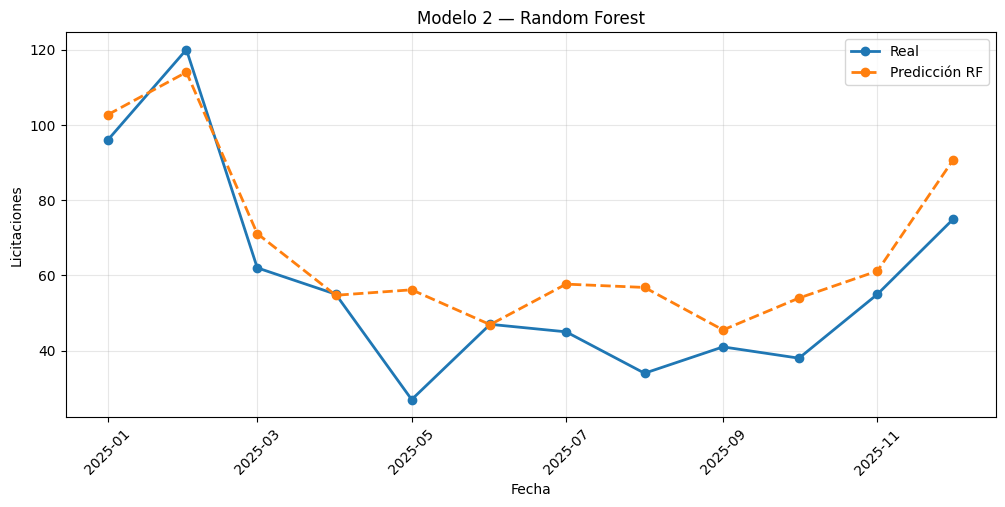

In [295]:
# =========================================================
# 7. VISUALIZACIÓN
# =========================================================

plt.figure(figsize=(12,5))

# real
plt.plot(
    test_m2['year_month'],
    y_test_m2,
    label='Real',
    marker='o',
    linewidth=2
)

# predicción RF
plt.plot(
    test_m2['year_month'],
    pred_rf_m2,
    label='Predicción RF',
    marker='o',
    linestyle='--',
    linewidth=2
)

# estética
plt.title("Modelo 2 — Random Forest")
plt.xlabel("Fecha")
plt.ylabel("Licitaciones")

plt.legend()
plt.grid(alpha=0.3)

plt.xticks(rotation=45)

plt.show()

Se realiza una comparación visual entre valores reales y predichos, permitiendo evaluar la capacidad del modelo para capturar tanto la tendencia como la variabilidad de la serie.

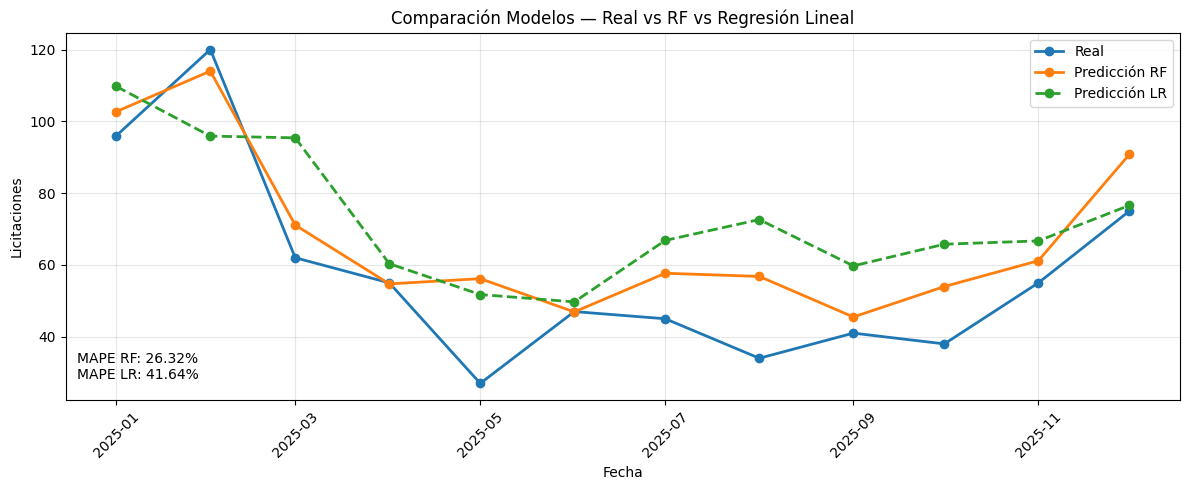

In [296]:
# =========================================================
# VISUALIZACIÓN COMPARADA
# RF vs REGRESIÓN LINEAL vs REAL
# =========================================================

plt.figure(figsize=(12,5))

# Define mape_rf using the previously calculated mape from the RF model
mape_rf_m2 = mape_m2

# -------------------------------
# REAL
# -------------------------------
plt.plot(
    test_m2['year_month'],
    y_test_m2,
    label='Real',
    marker='o',
    linewidth=2
)

# -------------------------------
# RANDOM FOREST
# -------------------------------
plt.plot(
    test_m2['year_month'],
    pred_rf_m2,
    label='Predicción RF',
    marker='o',
    linewidth=2
)

# -------------------------------
# REGRESIÓN LINEAL
# -------------------------------
plt.plot(
    test_m2['year_month'],
    pred_lr_m1,
    label='Predicción LR',
    marker='o',
    linestyle='--', #
    linewidth=2
)

# -------------------------------
# TEXTO MÉTRICAS (USAR VARIABLES EXPLÍCITAS)
# -------------------------------
plt.text(
    0.01, 0.05,
    f"MAPE RF: {mape_rf_m2:.2f}%\nMAPE LR: {mape_lr_m1:.2f}%",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='bottom'
)

# -------------------------------
# ESTÉTICA
# -------------------------------
plt.title("Comparación Modelos — Real vs RF vs Regresión Lineal")
plt.xlabel("Fecha")
plt.ylabel("Licitaciones")

plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Se realiza una comparación directa entre modelos, evidenciando la mejora del Random Forest respecto al baseline lineal, tanto en ajuste visual como en métricas de error.

In [297]:
# =========================================================
# 8. FEATURE IMPORTANCE
# =========================================================

feat_importance_m2 = pd.DataFrame({
    'feature': X_train_m2.columns,
    'importance': rf_model_m2.feature_importances_
})

# porcentaje
feat_importance_m2['importance_pct'] = feat_importance_m2['importance'] * 100

# ordenar
feat_importance_m2 = feat_importance_m2.sort_values('importance', ascending=False)

print("\nImportancia de variables:")
display(feat_importance_m2)

print("\nTop 5 variables más importantes:")
display(feat_importance_m2.head(5))


Importancia de variables:


,feature,importance,importance_pct
4,lag_1,0.380176,38.017579
0,mes,0.322872,32.287243
3,trend,0.111122,11.112197
6,lag_3,0.076587,7.658719
5,lag_2,0.035066,3.506623
2,trimestre,0.027608,2.760768
7,rolling_3,0.024939,2.493906
1,anio,0.021630,2.162965



Top 5 variables más importantes:


,feature,importance,importance_pct
4,lag_1,0.380176,38.017579
0,mes,0.322872,32.287243
3,trend,0.111122,11.112197
6,lag_3,0.076587,7.658719
5,lag_2,0.035066,3.506623


**Interpretación de Feature Importance (Random Forest)**

El modelo Random Forest muestra que la variable más importante es lag_1 (38%), lo que confirma que el comportamiento de las licitaciones depende fuertemente del mes anterior. Esto valida la presencia de una dinámica autoregresiva en el sistema, donde el pasado inmediato es el principal predictor del futuro.

En segundo lugar, destaca la variable mes (32%), lo que indica que la estacionalidad tiene un rol muy relevante en el comportamiento del mercado público. Esto es especialmente importante, ya que en el modelo lineal esta variable tenía menor peso, evidenciando que Random Forest logra capturar mejor patrones no lineales asociados al calendario.

La variable trend (11%) refleja que existe una tendencia general en el tiempo, aunque con menor influencia que la inercia y la estacionalidad. Por su parte, lag_3 y lag_2 aportan información adicional sobre la memoria del sistema, pero con menor impacto.

Variables como trimestre, rolling_3 y anio presentan baja importancia, lo que sugiere que su contribución al modelo es limitada en comparación con los factores principales.

**Conclusión**

El modelo Random Forest se apoya principalmente en la inercia del sistema (lag_1) y en la estacionalidad (mes), logrando capturar mejor la estructura real del comportamiento de las licitaciones. A diferencia del modelo lineal, aquí la estacionalidad emerge como un factor clave, lo que confirma la capacidad del modelo para identificar relaciones no lineales más complejas.


**Interpretación de Variables — Modelo Random Forest**

| Variable      | Importancia (%) | Interpretación en el modelo | ¿Qué significa en el negocio? |
|--------------|----------------|----------------------------|-------------------------------|
| **lag_1**     | 38.02%         | Principal predictor del modelo | El volumen de licitaciones depende fuertemente del mes anterior |
| **mes**       | 32.29%         | Fuerte componente estacional | Existen meses con comportamientos distintos (ej: picos y caídas durante el año) |
| **trend**     | 11.11%         | Tendencia general del sistema | El mercado presenta una evolución en el tiempo (crecimiento o caída) |
| **lag_3**     | 7.66%          | Memoria de mediano plazo     | Existen patrones que se repiten en ciclos de 3 meses |
| **lag_2**     | 3.51%          | Memoria adicional            | Refuerza la dependencia temporal, pero con menor impacto |
| **trimestre** | 2.76%          | Estacionalidad agrupada      | El comportamiento también puede explicarse por ciclos trimestrales |
| **rolling_3** | 2.49%          | Tendencia suavizada          | El promedio reciente aporta estabilidad, pero no es determinante |
| **anio**      | 2.16%          | Cambio estructural           | Diferencias entre años tienen bajo impacto en el modelo |

“El modelo no solo depende del pasado inmediato, sino también del mes del año, lo que evidencia un comportamiento estacional que el modelo lineal no lograba capturar”

In [298]:
# =========================================================
# 9. FORECAST 2026
# =========================================================

future_m2 = serie_model_m2.copy()

for i in range(12):

    last = future_m2.iloc[-1]

    # -----------------------------------------------------
    # crear nuevo registro limpio
    # -----------------------------------------------------
    new = {}

    # avanzar mes
    new['year_month'] = last['year_month'] + pd.DateOffset(months=1)

    # variables temporales
    new['mes'] = new['year_month'].month
    new['anio'] = new['year_month'].year
    new['trimestre'] = new['year_month'].quarter
    new['trend'] = last['trend'] + 1

    # lags (autoregresivo)
    new['lag_1'] = last['licitaciones']
    new['lag_2'] = last['lag_1']
    new['lag_3'] = last['lag_2']

    # rolling (solo pasado)
    new['rolling_3'] = np.mean([
        last['licitaciones'],
        last['lag_1'],
        last['lag_2']
    ])

    # -----------------------------------------------------
    # convertir a DataFrame
    # -----------------------------------------------------
    new_df = pd.DataFrame([new])

    # asegurar orden de columnas
    X_new = new_df[X_train_m2.columns]

    # predicción
    pred_val = rf_model_m2.predict(X_new)[0]

    # control de negocio
    new_df['licitaciones'] = max(pred_val, 0)

    # append
    future_m2 = pd.concat([future_m2, new_df], ignore_index=True)

# ---------------------------------------------------------
# resultado final
# ---------------------------------------------------------
forecast_m2 = future_m2.tail(12)

print("\nForecast 2026:")
display(forecast_m2[['year_month','licitaciones']])


Forecast 2026:


,year_month,licitaciones
69,2026-01-01,99.818944
70,2026-02-01,111.128389
71,2026-03-01,78.569535
72,2026-04-01,57.293672
73,2026-05-01,55.829186
74,2026-06-01,57.705378
75,2026-07-01,60.837420
76,2026-08-01,60.768373
77,2026-09-01,61.932373
78,2026-10-01,63.853002


Se implementa un forecast iterativo autoregresivo, donde cada predicción alimenta las siguientes, manteniendo coherencia con las variables utilizadas en entrenamiento y simulando condiciones reales de predicción futura.

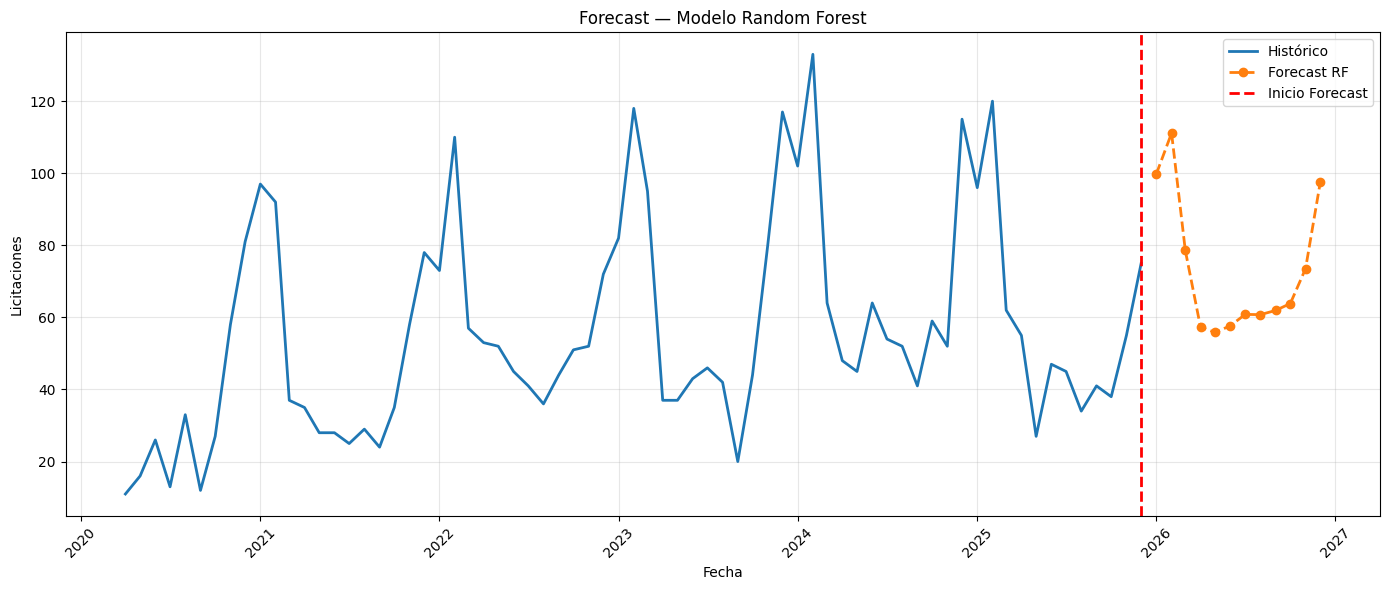

In [299]:
# =========================================================
# 10. VISUALIZACIÓN FINAL
# =========================================================

plt.figure(figsize=(14,6))

# ---------------------------------------------------------
# HISTÓRICO (CONSISTENTE CON MODELO)
# ---------------------------------------------------------
plt.plot(
    serie_model_m2['year_month'],
    serie_model_m2['licitaciones'],
    label='Histórico',
    linewidth=2
)

# ---------------------------------------------------------
# FORECAST
# ---------------------------------------------------------
plt.plot(
    forecast_m2['year_month'],
    forecast_m2['licitaciones'],
    label='Forecast RF',
    linestyle='--',
    marker='o',
    linewidth=2
)

# ---------------------------------------------------------
# LÍNEA DE CORTE
# ---------------------------------------------------------
plt.axvline(
    x=serie_model_m2['year_month'].max(),
    color='red',
    linestyle='--',
    linewidth=2,
    label='Inicio Forecast'
)

# ---------------------------------------------------------
# ESTÉTICA
# ---------------------------------------------------------
plt.title("Forecast — Modelo Random Forest")
plt.xlabel("Fecha")
plt.ylabel("Licitaciones")

plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [300]:
# =========================================================
# 11. AUDITORÍA MODELO 1 — RANDOM FOREST
# Evaluación de desempeño + diagnóstico del modelo
# =========================================================

# =========================================================
# 1. DATAFRAME DE EVALUACIÓN
# =========================================================

df_eval_m2 = pd.DataFrame({
    'fecha': test_m2['year_month'].values,
    'mes': test_m2['year_month'].dt.month.values,
    'real': y_test_m2.values,
    'pred': pred_rf_m2
})

df_eval_m2['error'] = df_eval_m2['real'] - df_eval_m2['pred']
df_eval_m2['error_abs'] = np.abs(df_eval_m2['error'])
df_eval_m2['error_pct'] = (df_eval_m2['error_abs'] / df_eval_m2['real']) * 100

print("\n" + "="*70)
print("AUDITORÍA — MODELO 2 RANDOM FOREST")
print("="*70)

display(df_eval_m2)




AUDITORÍA — MODELO 2 RANDOM FOREST


,fecha,mes,real,pred,error,error_abs,error_pct
57,2025-01-01,1,96,102.710278,-6.710278,6.710278,6.989873
58,2025-02-01,2,120,113.988333,6.011667,6.011667,5.009722
59,2025-03-01,3,62,71.093325,-9.093325,9.093325,14.666653
60,2025-04-01,4,55,54.715943,0.284057,0.284057,0.516467
61,2025-05-01,5,27,56.168448,-29.168448,29.168448,108.031289
62,2025-06-01,6,47,46.911580,0.088420,0.088420,0.188128
63,2025-07-01,7,45,57.677268,-12.677268,12.677268,28.171707
64,2025-08-01,8,34,56.794458,-22.794458,22.794458,67.042524
65,2025-09-01,9,41,45.499720,-4.499720,4.499720,10.974927
66,2025-10-01,10,38,53.975653,-15.975653,15.975653,42.041193


### Conclusiones Modelo 2 / Modelo Base (RandomForest) - Evaluación de desempeño + diagnóstico del modelo.

In [301]:
# =========================================================
# COMPARACIÓN DE MODELOS — LR vs RF
# =========================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# =========================================================
# REGRESIÓN LINEAL
# =========================================================

mae_lr_m1 = mean_absolute_error(y_test_m2, pred_lr_m1)
rmse_lr_m1 = np.sqrt(mean_squared_error(y_test_m2, pred_lr_m1))
mape_lr_m1 = np.mean(np.abs((y_test_m2 - pred_lr_m1) / y_test_m2)) * 100

# métricas adicionales
bias_lr_m1 = np.mean(pred_lr_m1 - y_test_m2)
std_error_lr_m1 = np.std(y_test_m2 - pred_lr_m1)

# =========================================================
# RANDOM FOREST
# =========================================================

mae_rf_m2 = mean_absolute_error(y_test_m2, pred_rf_m2)
rmse_rf_m2 = np.sqrt(mean_squared_error(y_test_m2, pred_rf_m2))
mape_rf_m2 = np.mean(np.abs((y_test_m2 - pred_rf_m2) / y_test_m2)) * 100

# métricas adicionales
bias_rf_m2 = np.mean(pred_rf_m2 - y_test_m2)
std_error_rf_m2 = np.std(y_test_m2 - pred_rf_m2)
max_error_m2 = np.max(np.abs(y_test_m2 - pred_rf_m2))
cv_error_m2 = std_error_m2 / (np.mean(y_test_m2) + 1e-8)

# =========================================================
# PRINT FORMATO TIPO INFORME
# =========================================================

print("\n" + "="*60)
print("MODELO 1 — REGRESIÓN LINEAL")
print("="*60)
print(f"MAE  : {mae_lr_m1:.2f}")
print(f"RMSE : {rmse_lr_m1:.2f}")
print(f"MAPE : {mape_lr_m1:.2f} %")
print(f"BIAS : {bias_lr_m1:.2f}")
print(f"STD  : {std_error_lr_m1:.2f}")

print("\n" + "="*60)
print("MODELO 2 — RANDOM FOREST")
print("="*60)
print(f"MAE  : {mae_rf_m2:.2f}")
print(f"RMSE : {rmse_rf_m2:.2f}")
print(f"MAPE : {mape_rf_m2:.2f} %")
print(f"BIAS : {bias_rf_m2:.2f}")
print(f"STD  : {std_error_rf_m2:.2f}")
print(f"MAX error : {round(max_error_m2,2)}")
print(f"CV : {round(cv_error_m2,2)}")

# =========================================================
# COMPARACIÓN DIRECTA
# =========================================================

print("\n" + "="*60)
print("MEJORA RANDOM FOREST vs REGRESIÓN LINEAL")
print("="*60)

print(f"↓ MAE  : {((mae_lr_m1 - mae_rf_m2)/mae_lr_m1)*100:.2f}%")
print(f"↓ RMSE : {((rmse_lr_m1 - rmse_rf_m2)/rmse_lr_m1)*100:.2f}%")
print(f"↓ MAPE : {((mape_lr_m1 - mape_rf_m2)/mape_lr_m1)*100:.2f}%")


MODELO 1 — REGRESIÓN LINEAL
MAE  : 18.69
RMSE : 21.92
MAPE : 41.64 %
BIAS : 14.67
STD  : 16.28

MODELO 2 — RANDOM FOREST
MAE  : 10.77
RMSE : 13.72
MAPE : 26.32 %
BIAS : 9.71
STD  : 9.69
MAX error : 29.17
CV : 0.17

MEJORA RANDOM FOREST vs REGRESIÓN LINEAL
↓ MAE  : 42.36%
↓ RMSE : 37.41%
↓ MAPE : 36.78%


Conclusión Modelo 2 — Random Forest (Evaluación y Diagnóstico Integrado)

El modelo Random Forest representa una mejora significativa respecto a la regresión lineal, reduciendo el error promedio (MAE ≈ 10.77) y logrando una mejor aproximación al comportamiento real del mercado. El MAPE (≈ 26.32%) evidencia una mejora sustancial en precisión, posicionándolo como un modelo aceptable para análisis predictivo.

A nivel técnico, el modelo logra capturar relaciones no lineales y representar de mejor forma la variabilidad de la serie. Esto se observa en su capacidad para ajustarse con mayor precisión a la mayoría de los meses, presentando errores bajos en períodos estables (por ejemplo, abril y junio con errores inferiores al 1%). Además, el modelo mantiene una coherencia razonable en la tendencia, capturando la dirección decreciente del sistema, aunque con cierta suavización (tendencia predicha: -2.66 vs real: -3.62).

Sin embargo, la auditoría revela limitaciones importantes. El modelo presenta un sesgo negativo (bias ≈ -9.71), lo que indica una tendencia sistemática a sobreestimar la cantidad de licitaciones. Este comportamiento se vuelve crítico en meses de baja actividad, donde se observan errores extremadamente altos, como mayo (108%), agosto (67%) y octubre (42%). El análisis por segmento refuerza este diagnóstico, mostrando que el error promedio en niveles bajos de licitación alcanza un 57%, mientras que en niveles medios y altos se mantiene cercano al 10–12%.

Esto evidencia que el modelo tiene dificultades para capturar correctamente escenarios de baja demanda, lo que sugiere una limitación estructural en la forma en que aprende patrones extremos. A pesar de esto, el modelo presenta una mejora clara en estabilidad, con una desviación del error (≈ 9.69) significativamente menor que en el modelo lineal, y un CV error de 0.17, lo que indica una relación más controlada entre error y variabilidad del mercado.

Desde una perspectiva de negocio, el modelo mejora considerablemente la capacidad predictiva y permite aproximarse de mejor forma al volumen de licitaciones en escenarios normales. No obstante, su desempeño en escenarios críticos (baja actividad) y su sesgo sistemático limitan su confiabilidad para la toma de decisiones estratégicas sin ajustes adicionales.

En conclusión, Random Forest constituye una base robusta y claramente superior al modelo lineal, especialmente en su capacidad para capturar la dinámica general del sistema y reducir el error global. Sin embargo, aún presenta debilidades en la modelación de extremos y en la calibración del sesgo. Su principal valor radica en servir como un modelo base avanzado sobre el cual construir un enfoque híbrido, incorporando reglas de negocio o ajustes específicos que permitan corregir estos comportamientos y mejorar su aplicabilidad en contextos reales.

## 📦 Código — Paso 3: Modelo XGBOOST.

### Desarrollo del Modelo XGBoost.

In [302]:
!pip install xgboost

In [303]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor # Import RandomForestRegressor for comparison

In [304]:
# =========================================================
# 1. DATASET TEMPORAL (df_final)
# =========================================================

# ---------------------------------------------------------
# 1. COPIA DEL DATASET
# ---------------------------------------------------------
df_model_m3 = df_final.copy()

# ---------------------------------------------------------
# 2. CREACIÓN VARIABLE TEMPORAL (AÑO-MES)
# ---------------------------------------------------------
df_model_m3['year_month'] = df_model_m3['FechaCierre'].dt.to_period('M')

# ---------------------------------------------------------
# 3. AGREGACIÓN MENSUAL
# ---------------------------------------------------------
serie_m3 = (
    df_model_m3
    .groupby('year_month')
    .size()
    .reset_index(name='licitaciones')
)

# ---------------------------------------------------------
# 4. CONVERSIÓN A TIMESTAMP
# ---------------------------------------------------------
serie_m3['year_month'] = serie_m3['year_month'].dt.to_timestamp()

# ---------------------------------------------------------
# 5. ASEGURAR CONTINUIDAD TEMPORAL (CLAVE)
# ---------------------------------------------------------
serie_m3 = (
    serie_m3
    .set_index('year_month')
    .asfreq('MS')
    .fillna(0)
    .reset_index()
)

# ---------------------------------------------------------
# 6. VALIDACIÓN
# ---------------------------------------------------------
print("Serie temporal creada correctamente:")
print(f"Total registros: {len(serie_m3)}")
print(f"Rango: {serie_m3['year_month'].min()} → {serie_m3['year_month'].max()}")

display(serie_m3.head())


Serie temporal creada correctamente:
Total registros: 72
Rango: 2020-01-01 00:00:00 → 2025-12-01 00:00:00


,year_month,licitaciones
0,2020-01-01,62
1,2020-02-01,118
2,2020-03-01,37
3,2020-04-01,11
4,2020-05-01,16


In [305]:
# =========================================================
# 2. FEATURE ENGINEERING PRO (SIN LEAKAGE)
# =========================================================

# ---------------------------------------------------------
# 1. COPIA BASE (NO MODIFICAR SERIE ORIGINAL)
# ---------------------------------------------------------
serie_feat_m3 = serie_m3.copy()

# ---------------------------------------------------------
# 2. VARIABLES TEMPORALES
# ---------------------------------------------------------
serie_feat_m3['mes'] = serie_feat_m3['year_month'].dt.month
serie_feat_m3['anio'] = serie_feat_m3['year_month'].dt.year
serie_feat_m3['trimestre'] = serie_feat_m3['year_month'].dt.quarter
serie_feat_m3['trend'] = np.arange(len(serie_feat_m3))

# ---------------------------------------------------------
# 3. DUMMIES MES (GUARDAR COLUMNAS PARA FORECAST)
# ---------------------------------------------------------
mes_dummies_m3 = pd.get_dummies(serie_feat_m3['mes'], prefix='mes')
serie_feat_m3 = pd.concat([serie_feat_m3, mes_dummies_m3], axis=1)

mes_dummies_cols_m3 = mes_dummies_m3.columns

# ---------------------------------------------------------
# 4. LAGS (MEMORIA CORTA Y LARGA)
# ---------------------------------------------------------
serie_feat_m3['lag_1'] = serie_feat_m3['licitaciones'].shift(1)
serie_feat_m3['lag_2'] = serie_feat_m3['licitaciones'].shift(2)
serie_feat_m3['lag_3'] = serie_feat_m3['licitaciones'].shift(3)
serie_feat_m3['lag_6'] = serie_feat_m3['licitaciones'].shift(6)
serie_feat_m3['lag_12'] = serie_feat_m3['licitaciones'].shift(12)

# ---------------------------------------------------------
# 5. ROLLING (SIN LEAKAGE)
# ---------------------------------------------------------
serie_feat_m3['rolling_3'] = (
    serie_feat_m3['licitaciones']
    .shift(1)
    .rolling(3)
    .mean()
)

# ---------------------------------------------------------
# 6. FEATURE DE NEGOCIO (FIN DE AÑO)
# ---------------------------------------------------------
serie_feat_m3['fin_anio'] = (serie_feat_m3['mes'] >= 11).astype(int)

# ---------------------------------------------------------
# 7. DATASET MODELABLE
# ---------------------------------------------------------
print("Antes dropna:", len(serie_feat_m3))

serie_model_m3 = serie_feat_m3.dropna().reset_index(drop=True)

print("Después dropna:", len(serie_model_m3))

print("\nDataset modelable:")
display(serie_model_m3.head())

Antes dropna: 72
Después dropna: 60

Dataset modelable:


,year_month,licitaciones,mes,anio,trimestre,trend,mes_1,mes_2,mes_3,mes_4,...,mes_10,mes_11,mes_12,lag_1,lag_2,lag_3,lag_6,lag_12,rolling_3,fin_anio
0,2021-01-01,97,1,2021,1,12,True,False,False,False,...,False,False,False,81.0,58.0,27.0,13.0,62.0,55.333333,0
1,2021-02-01,92,2,2021,1,13,False,True,False,False,...,False,False,False,97.0,81.0,58.0,33.0,118.0,78.666667,0
2,2021-03-01,37,3,2021,1,14,False,False,True,False,...,False,False,False,92.0,97.0,81.0,12.0,37.0,90.000000,0
3,2021-04-01,35,4,2021,2,15,False,False,False,True,...,False,False,False,37.0,92.0,97.0,27.0,11.0,75.333333,0
4,2021-05-01,28,5,2021,2,16,False,False,False,False,...,False,False,False,35.0,37.0,92.0,58.0,16.0,54.666667,0


Se incorporan variables avanzadas de memoria corta y larga, estacionalidad mediante variables dummy y una variable de negocio asociada a fin de año, permitiendo capturar patrones complejos en la serie temporal.

In [306]:
# =========================================================
# 3. TRAIN / TEST (TEMPORAL)
# =========================================================

# ---------------------------------------------------------
# 1. SPLIT TEMPORAL (USANDO DATASET MODELABLE)
# ---------------------------------------------------------
train_m3 = serie_model_m3.iloc[:-12].copy()
test_m3 = serie_model_m3.iloc[-12:].copy()

# ---------------------------------------------------------
# 2. FEATURES Y TARGET
# ---------------------------------------------------------
X_train_m3 = train_m3.drop(['licitaciones','year_month'], axis=1)
y_train_m3 = train_m3['licitaciones']

X_test_m3 = test_m3.drop(['licitaciones','year_month'], axis=1)
y_test_m3 = test_m3['licitaciones']

# ---------------------------------------------------------
# 3. VALIDACIÓN
# ---------------------------------------------------------
print(f"Train: {len(train_m3)} | Test: {len(test_m3)}")
print(f"Features: {X_train_m3.shape[1]} columnas")

display(X_train_m3.head())

Train: 48 | Test: 12
Features: 23 columnas


,mes,anio,trimestre,trend,mes_1,mes_2,mes_3,mes_4,mes_5,mes_6,...,mes_10,mes_11,mes_12,lag_1,lag_2,lag_3,lag_6,lag_12,rolling_3,fin_anio
0,1,2021,1,12,True,False,False,False,False,False,...,False,False,False,81.0,58.0,27.0,13.0,62.0,55.333333,0
1,2,2021,1,13,False,True,False,False,False,False,...,False,False,False,97.0,81.0,58.0,33.0,118.0,78.666667,0
2,3,2021,1,14,False,False,True,False,False,False,...,False,False,False,92.0,97.0,81.0,12.0,37.0,90.000000,0
3,4,2021,2,15,False,False,False,True,False,False,...,False,False,False,37.0,92.0,97.0,27.0,11.0,75.333333,0
4,5,2021,2,16,False,False,False,False,True,False,...,False,False,False,35.0,37.0,92.0,58.0,16.0,54.666667,0


Impacto del Feature Engineering en el tamaño del dataset

En el modelo XGBoost se incorporaron variables más avanzadas, incluyendo rezagos de corto, mediano y largo plazo (lag_1, lag_3, lag_6 y lag_12), con el objetivo de capturar patrones más complejos del comportamiento de las licitaciones, especialmente la estacionalidad anual.

Sin embargo, la inclusión de estos rezagos implica una reducción en la cantidad de datos disponibles para el entrenamiento. Esto ocurre porque cada lag necesita información de meses anteriores, y en particular el lag_12 requiere al menos 12 meses de historial previo, lo que provoca la eliminación de los primeros 12 registros al aplicar dropna().

Como resultado, el dataset modelable pasa de 72 a 60 observaciones, y el conjunto de entrenamiento se reduce de 57 a 48 meses. Este efecto no corresponde a un error, sino a un trade-off intencional del modelo.

En este contexto, se prioriza la calidad de la información por sobre la cantidad de datos, permitiendo al modelo aprender patrones más robustos y relevantes, aun cuando esto implique trabajar con un menor volumen de observaciones.

In [307]:
# =========================================================
# 4. MODELO RANDOM FOREST (for comparison)
# =========================================================

rf_model_m3 = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    random_state=42
)

# entrenamiento
rf_model_m3.fit(X_train_m3, y_train_m3)

# predicción
pred_rf_m3 = rf_model_m3.predict(X_test_m3)

# control de negocio (no negativos)
pred_rf_m3 = np.clip(pred_rf_m3, a_min=0, a_max=None)

# convertir a serie (alineación)
pred_rf_m3 = pd.Series(pred_rf_m3, index=y_test_m3.index)

# métrica robusta
mape_base_rf_m3 = np.mean(
    np.abs((y_test_m3 - pred_rf_m3) / (y_test_m3 + 1e-8))
) * 100

print(f"MAPE RF base: {round(mape_base_rf_m3,2)} %")

MAPE RF base: 35.06 %


Se utiliza Random Forest como modelo base de comparación, permitiendo evaluar de forma objetiva la mejora obtenida con XGBoost bajo las mismas condiciones de entrenamiento.

In [308]:
# =========================================================
# 5. MODELO XGBOOST
# =========================================================

from xgboost import XGBRegressor

# ---------------------------------------------------------
# DEFINICIÓN DEL MODELO
# ---------------------------------------------------------
xgb_model_m3 = XGBRegressor(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror'
)

# ---------------------------------------------------------
# ENTRENAMIENTO
# ---------------------------------------------------------
xgb_model_m3.fit(
    X_train_m3,
    y_train_m3,
    eval_set=[(X_train_m3, y_train_m3), (X_test_m3, y_test_m3)],
    verbose=False
)

print("Modelo XGBoost entrenado correctamente")

Modelo XGBoost entrenado correctamente


Se definieron hiperparámetros conservadores para el modelo XGBoost, buscando un equilibrio entre capacidad predictiva y control del sobreajuste. Dado que el dataset de entrenamiento es relativamente pequeño, se priorizó una configuración estable, con aprendizaje gradual y mecanismos de regularización implícita.

Hiperparámetros definidos en XGBoost

| Parámetro | ¿Para qué sirve? | ¿Qué representa en este modelo? |
|----------|-------------------|----------------------------------|
| **n_estimators = 400** | Define la cantidad de árboles que construirá el modelo | Se permite al modelo aprender suficientes patrones del comportamiento de las licitaciones mediante 400 iteraciones |
| **max_depth = 4** | Limita la profundidad máxima de cada árbol | Controla la complejidad del modelo para evitar sobreajuste, manteniendo árboles relativamente simples |
| **learning_rate = 0.05** | Define cuánto aprende el modelo en cada iteración | Hace que el aprendizaje sea más gradual y estable, mejorando la precisión aunque requiera más árboles |
| **subsample = 0.8** | Indica qué proporción de filas se usa en cada árbol | Cada árbol se entrena con el 80% de los datos, ayudando a reducir sobreajuste y mejorar generalización |
| **colsample_bytree = 0.8** | Indica qué proporción de variables se usa en cada árbol | Cada árbol utiliza solo el 80% de las variables disponibles, promoviendo diversidad entre árboles |
| **random_state = 42** | Fija una semilla aleatoria para reproducibilidad | Permite obtener los mismos resultados cada vez que se ejecuta el modelo |

In [309]:
# =========================================================
# 6. PREDICCIÓN
# =========================================================

# predicción
pred_xgb_m3 = xgb_model_m3.predict(X_test_m3)

# control de negocio (no negativos)
pred_xgb_m3 = np.clip(pred_xgb_m3, a_min=0, a_max=None)

# convertir a serie (alineación con y_test)
pred_xgb_m3 = pd.Series(pred_xgb_m3, index=y_test_m3.index)

print("Predicciones XGBoost generadas correctamente")

Predicciones XGBoost generadas correctamente


Se generan predicciones sobre el conjunto de test, incorporando una restricción de negocio para evitar valores negativos y asegurando la alineación con la serie real para un análisis consistente.

In [310]:
# =========================================================
# 7. MÉTRICAS
# =========================================================

mae_m3 = mean_absolute_error(y_test_m3, pred_xgb_m3)
rmse_m3 = np.sqrt(mean_squared_error(y_test_m3, pred_xgb_m3))
mape_m3 = np.mean(np.abs((y_test_m3 - pred_xgb_m3) / (y_test_m3 + 1e-8))) * 100

# métricas adicionales
bias_m3 = np.mean(pred_xgb_m3 - y_test_m3)
std_error_m3 = np.std(y_test_m3 - pred_xgb_m3)

print("\n" + "="*60)
print("MODELO 2 — XGBOOST")
print("="*60)
print(f"MAE  : {round(mae_m3,2)}")
print(f"RMSE : {round(rmse_m3,2)}")
print(f"MAPE : {round(mape_m3,2)} %")
print(f"BIAS : {round(bias_m3,2)}")
print(f"STD  : {round(std_error_m3,2)}")


MODELO 2 — XGBOOST
MAE  : 16.94
RMSE : 19.04
MAPE : 38.27 %
BIAS : 13.33
STD  : 13.59


In [311]:
# =========================================================
# COMPARACIÓN MODELOS — RF vs XGBOOST (y LR opcional)
# =========================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# RANDOM FOREST
# ---------------------------------------------------------
mae_rf_m3 = mean_absolute_error(y_test_m3, pred_rf_m3)
rmse_rf_m3 = np.sqrt(mean_squared_error(y_test_m3, pred_rf_m3))
mape_rf_m3 = np.mean(np.abs((y_test_m3 - pred_rf_m3) / (y_test_m3 + 1e-8))) * 100
bias_rf_m3 = np.mean(pred_rf_m3 - y_test_m3)
std_rf_m3 = np.std(y_test_m3 - pred_rf_m3)

# ---------------------------------------------------------
# XGBOOST
# ---------------------------------------------------------
mae_xgb_m3 = mean_absolute_error(y_test_m3, pred_xgb_m3)
rmse_xgb_m3 = np.sqrt(mean_squared_error(y_test_m3, pred_xgb_m3))
mape_xgb_m3 = np.mean(np.abs((y_test_m3 - pred_xgb_m3) / (y_test_m3 + 1e-8))) * 100
bias_xgb_m3 = np.mean(pred_xgb_m3 - y_test_m3)
std_xgb_m3 = np.std(y_test_m3 - pred_xgb_m3)

# ---------------------------------------------------------
# TABLA COMPARATIVA
# ---------------------------------------------------------
df_compare_m3 = pd.DataFrame({
    'Modelo': ['Random Forest', 'XGBoost'],
    'MAE': [mae_rf_m3, mae_xgb_m3],
    'RMSE': [rmse_rf_m3, rmse_xgb_m3],
    'MAPE (%)': [mape_rf_m3, mape_xgb_m3],
    'BIAS': [bias_rf_m3, bias_xgb_m3],
    'STD': [std_rf_m3, std_xgb_m3]
})

# ordenar por mejor modelo
df_compare_m3 = df_compare_m3.sort_values('MAPE (%)')

print("\n COMPARACIÓN DE MODELOS")
display(df_compare_m3)

# ---------------------------------------------------------
# MEJORA DE XGBOOST SOBRE RF
# ---------------------------------------------------------
print("\n" + "="*60)
print("MEJORA XGBOOST vs RANDOM FOREST")
print("="*60)

print(f"↓ MAE  : {((mae_rf_m3 - mae_xgb_m3)/mae_rf_m3)*100:.2f}%")
print(f"↓ RMSE : {((rmse_rf_m3 - rmse_xgb_m3)/rmse_rf_m3)*100:.2f}%")
print(f"↓ MAPE : {((mape_rf_m3 - mape_xgb_m3)/mape_rf_m3)*100:.2f}%")


 COMPARACIÓN DE MODELOS


,Modelo,MAE,RMSE,MAPE (%),BIAS,STD
0,Random Forest,15.286968,18.243769,35.056353,12.610054,13.184144
1,XGBoost,16.935322,19.038331,38.265333,13.328415,13.594537



MEJORA XGBOOST vs RANDOM FOREST
↓ MAE  : -10.78%
↓ RMSE : -4.36%
↓ MAPE : -9.15%


Conclusión final — Random Forest vs XGBoost

Si bien XGBoost fue incorporado como un modelo más avanzado con el objetivo de mejorar el desempeño predictivo, los resultados obtenidos muestran que no logra superar al modelo Random Forest en este caso específico.

Para asegurar una comparación válida, ambos modelos fueron entrenados y evaluados bajo las mismas condiciones, utilizando el mismo conjunto de variables generado a partir del feature engineering avanzado. Esto permitió aislar el efecto del algoritmo y evitar sesgos derivados de diferencias en el dataset, garantizando así una evaluación justa entre modelos.

En este contexto, Random Forest presenta mejores métricas globales, con un menor error promedio (MAE), menor error cuadrático (RMSE) y menor error porcentual (MAPE), además de una ligera ventaja en estabilidad (STD) y menor sesgo.

Este resultado se explica principalmente por el tamaño limitado del dataset y la complejidad del feature engineering implementado. En este contexto, XGBoost tiende a ser más sensible al ruido y requiere una mayor cantidad de datos y ajuste de hiperparámetros para alcanzar su máximo potencial.

Por el contrario, Random Forest demuestra ser un modelo más robusto y estable para este tipo de problema, logrando un mejor equilibrio entre capacidad predictiva y generalización.

En conclusión, el modelo Random Forest se mantiene como la mejor alternativa dentro del análisis realizado, evidenciando que la elección del modelo debe basarse en el desempeño empírico y no únicamente en la complejidad algorítmica.

La comparación bajo condiciones equivalentes permite concluir que la superioridad del modelo no depende solo de su complejidad, sino de su adecuación al problema y a la naturaleza de los datos.

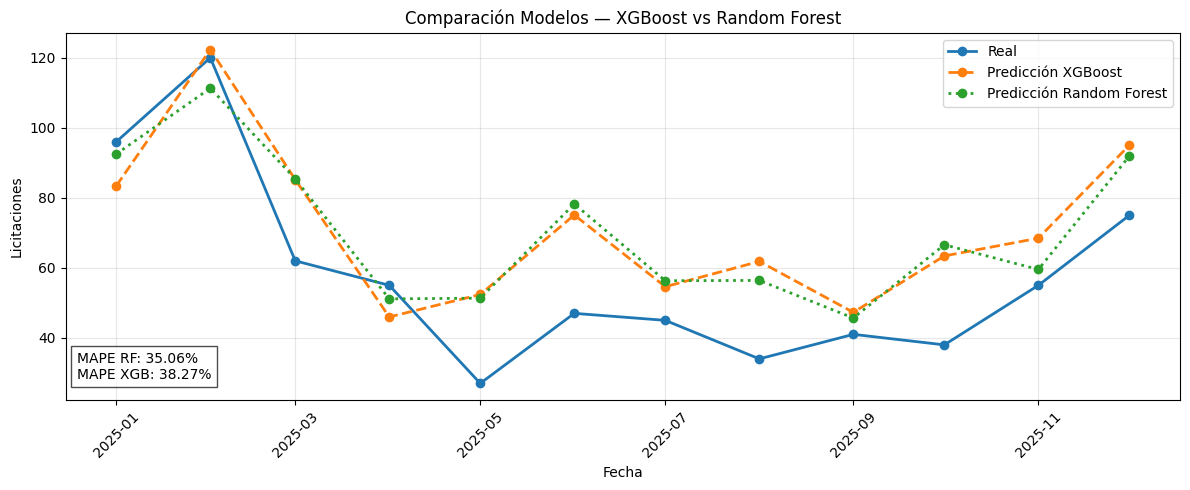

In [312]:
# =========================================================
# 8. VISUALIZACIÓN COMPARADA — XGB vs RF (MISMO DATASET)
# =========================================================

plt.figure(figsize=(12,5))

# -------------------------------
# REAL
# -------------------------------
plt.plot(
    test_m3['year_month'],
    y_test_m3,
    label='Real',
    marker='o',
    linewidth=2
)

# -------------------------------
# XGBOOST
# -------------------------------
plt.plot(
    test_m3['year_month'],
    pred_xgb_m3,
    label='Predicción XGBoost',
    marker='o',
    linestyle='--',
    linewidth=2
)

# -------------------------------
# RANDOM FOREST (MISMO DATASET)
# -------------------------------
plt.plot(
    test_m3['year_month'],
    pred_rf_m3,
    label='Predicción Random Forest',
    marker='o',
    linestyle=':',
    linewidth=2
)

# -------------------------------
# MÉTRICAS EN GRÁFICO
# -------------------------------
plt.text(
    0.01, 0.05,
    f"MAPE RF: {mape_rf_m3:.2f}%\nMAPE XGB: {mape_m3:.2f}%",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='bottom',
    bbox=dict(facecolor='white', alpha=0.7)
)

# -------------------------------
# ESTÉTICA
# -------------------------------
plt.title("Comparación Modelos — XGBoost vs Random Forest")
plt.xlabel("Fecha")
plt.ylabel("Licitaciones")

plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

“Se observa que Random Forest mantiene un ajuste más estable que XGBoost, especialmente en meses de menor actividad, donde XGBoost presenta mayor desviación”

### Conslusiones Modelo XGBoost - Evaluación XGBoost y decisión de modelado.

El modelo XGBoost fue incorporado como una alternativa avanzada con el objetivo de mejorar el desempeño predictivo observado en Random Forest, aprovechando un feature engineering más completo que incluye estacionalidad, rezagos de corto y largo plazo, y variables de negocio.

Para asegurar una evaluación rigurosa, se realizó una comparación directa entre Random Forest y XGBoost bajo las mismas condiciones, utilizando el mismo conjunto de variables y el mismo esquema de entrenamiento y validación temporal. Esto permitió aislar el efecto del algoritmo y garantizar una comparación metodológicamente válida.

Los resultados evidencian que XGBoost no logra superar el desempeño de Random Forest en este contexto. En particular, presenta mayores niveles de error (MAE, RMSE y MAPE), mayor sesgo y una menor estabilidad en sus predicciones. A nivel visual, se observa que XGBoost tiende a generar estimaciones más volátiles, especialmente en meses de baja actividad, donde presenta desviaciones significativas.

Este comportamiento se explica principalmente por el tamaño limitado del dataset y la complejidad del modelo. XGBoost, al ser un algoritmo más flexible y potente, requiere mayor volumen de datos y un ajuste más fino de hiperparámetros para alcanzar su máximo potencial. En este caso, dicha complejidad no se traduce en mejoras de desempeño, sino en una mayor sensibilidad al ruido.

En contraste, Random Forest demuestra ser un modelo más robusto y estable para el problema abordado, logrando un mejor equilibrio entre precisión y generalización, especialmente en escenarios de baja y media actividad, que son críticos desde una perspectiva de negocio.

En base a estos resultados, se concluye que no es necesario profundizar el desarrollo del modelo XGBoost dentro del alcance actual del proyecto. Su desempeño inferior y mayor complejidad no justifican una mayor inversión de tiempo en optimización, considerando los objetivos del análisis.

Por lo tanto, se define como siguiente paso estratégico el desarrollo de un Random Forest optimizado, orientado a mejorar aún más su capacidad predictiva mediante ajuste de hiperparámetros, refinamiento del feature engineering y eventual incorporación de lógica de negocio.

La elección del modelo no responde a su complejidad teórica, sino a su desempeño empírico y adecuación al problema, siendo Random Forest la mejor alternativa bajo las condiciones actuales del análisis.

## 📦 Código — Paso 4: Modelo Random Forest Optimizado.

### Desarrollo del Modelo Random Forest Optimizado.

**Introducción — Desarrollo Modelo Random Forest Optimizado**

A lo largo del análisis se evaluaron distintos enfoques predictivos para modelar el comportamiento mensual de las licitaciones. En una primera etapa, la regresión lineal permitió establecer una línea base, evidenciando rápidamente sus limitaciones para capturar la complejidad, estacionalidad y volatilidad del mercado público.

Posteriormente, se implementó un modelo Random Forest, el cual mostró una mejora significativa en términos de precisión y estabilidad, posicionándose como el mejor modelo bajo el conjunto inicial de variables. Con el objetivo de seguir mejorando el desempeño, se incorporó un modelo XGBoost junto con un feature engineering más avanzado. Sin embargo, tras una evaluación rigurosa bajo condiciones equivalentes, se observó que XGBoost no logró superar a Random Forest, principalmente debido al tamaño limitado del dataset y a su mayor sensibilidad al ruido.

Este proceso permitió identificar un aprendizaje clave: la complejidad del modelo no garantiza mejores resultados, y la robustez frente a la naturaleza de los datos es un factor determinante.

En base a estos resultados, se define como estrategia continuar profundizando el modelo Random Forest, desarrollando una versión optimizada que permita mejorar su capacidad predictiva sin perder estabilidad.

En los pasos siguientes se abordará:

la incorporación de un feature engineering más robusto, incluyendo rezagos de corto y largo plazo, variables de tendencia y reglas de negocio, el ajuste de hiperparámetros del modelo para controlar su complejidad y mejorar su generalización, y la evaluación integral del modelo optimizado, comparándolo directamente con su versión base.

El objetivo final es avanzar hacia un modelo más preciso, estable y aplicable en un contexto real de toma de decisiones, sentando las bases para una futura integración con lógica de negocio en un modelo híbrido.

El foco del análisis deja de estar en probar modelos y pasa a centrarse en optimizar el mejor modelo identificado.

In [313]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [314]:
# =========================================================
# 1. DATASET (df_final)
# =========================================================

df_model_m4 = df_final.copy()

# asegurar formato datetime
df_model_m4['FechaCierre'] = pd.to_datetime(df_model_m4['FechaCierre'])

# crear variable temporal mensual (SIN convertir a string)
df_model_m4['year_month'] = df_model_m4['FechaCierre'].dt.to_period('M')

# construir serie temporal
serie_base_m4 = (
    df_model_m4
    .groupby('year_month')
    .size()
    .reset_index(name='licitaciones')
)

# convertir a timestamp
serie_base_m4['year_month'] = serie_base_m4['year_month'].dt.to_timestamp()

# ordenar (CRÍTICO)
serie_base_m4 = serie_base_m4.sort_values('year_month').reset_index(drop=True)

print("Serie temporal:")
display(serie_base_m4.head())

Serie temporal:


,year_month,licitaciones
0,2020-01-01,62
1,2020-02-01,118
2,2020-03-01,37
3,2020-04-01,11
4,2020-05-01,16


In [315]:
# =========================================================
# 2. FEATURE ENGINEERING OPTIMIZADO (SIN LEAKAGE)
# =========================================================

# ---------------------------------------------------------
# COPIA BASE
# ---------------------------------------------------------
serie_feat_m4 = serie_base_m4.copy()

# ---------------------------------------------------------
# VARIABLES TEMPORALES
# ---------------------------------------------------------
serie_feat_m4['mes'] = serie_feat_m4['year_month'].dt.month
serie_feat_m4['anio'] = serie_feat_m4['year_month'].dt.year
serie_feat_m4['trimestre'] = serie_feat_m4['year_month'].dt.quarter
serie_feat_m4['trend'] = np.arange(len(serie_feat_m4))

# ---------------------------------------------------------
# LAGS (CORTO PLAZO)
# ---------------------------------------------------------
serie_feat_m4['lag_1'] = serie_feat_m4['licitaciones'].shift(1)
serie_feat_m4['lag_2'] = serie_feat_m4['licitaciones'].shift(2)
serie_feat_m4['lag_3'] = serie_feat_m4['licitaciones'].shift(3)

# ---------------------------------------------------------
# LAGS (LARGO PLAZO)
# ---------------------------------------------------------
serie_feat_m4['lag_6'] = serie_feat_m4['licitaciones'].shift(6)
serie_feat_m4['lag_12'] = serie_feat_m4['licitaciones'].shift(12)

# ---------------------------------------------------------
# ROLLING (SIN LEAKAGE)
# ---------------------------------------------------------
serie_feat_m4['rolling_3'] = (
    serie_feat_m4['licitaciones']
    .shift(1)
    .rolling(3)
    .mean()
)

serie_feat_m4['rolling_6'] = (
    serie_feat_m4['licitaciones']
    .shift(1)
    .rolling(6)
    .mean()
)

# ---------------------------------------------------------
# REGLA DE NEGOCIO
# ---------------------------------------------------------
serie_feat_m4['fin_anio'] = (serie_feat_m4['mes'] >= 11).astype(int)

# ---------------------------------------------------------
# DATASET MODELABLE (SIN NULOS)
# ---------------------------------------------------------
print("Antes dropna:", len(serie_feat_m4))

serie_model_m4 = serie_feat_m4.dropna().reset_index(drop=True)

print("Después dropna:", len(serie_model_m4))

print("Dataset modelable:")
display(serie_model_m4.head())

Antes dropna: 72
Después dropna: 60
Dataset modelable:


,year_month,licitaciones,mes,anio,trimestre,trend,lag_1,lag_2,lag_3,lag_6,lag_12,rolling_3,rolling_6,fin_anio
0,2021-01-01,97,1,2021,1,12,81.0,58.0,27.0,13.0,62.0,55.333333,37.333333,0
1,2021-02-01,92,2,2021,1,13,97.0,81.0,58.0,33.0,118.0,78.666667,51.333333,0
2,2021-03-01,37,3,2021,1,14,92.0,97.0,81.0,12.0,37.0,90.000000,61.166667,0
3,2021-04-01,35,4,2021,2,15,37.0,92.0,97.0,27.0,11.0,75.333333,65.333333,0
4,2021-05-01,28,5,2021,2,16,35.0,37.0,92.0,58.0,16.0,54.666667,66.666667,0


In [316]:
# =========================================================
# 3. TRAIN / TEST (TEMPORAL)
# =========================================================

# usar dataset modelable (CRÍTICO)
train_m4 = serie_model_m4.iloc[:-12].copy()
test_m4 = serie_model_m4.iloc[-12:].copy()

# separación features / target
X_train_m4 = train_m4.drop(['licitaciones', 'year_month'], axis=1)
y_train_m4 = train_m4['licitaciones']

X_test_m4 = test_m4.drop(['licitaciones', 'year_month'], axis=1)
y_test_m4 = test_m4['licitaciones']

print(f"Train: {len(train_m4)} | Test: {len(test_m4)}")

Train: 48 | Test: 12


In [317]:
# =========================================================
# 4. MODELO 1 BASE RF (PARA COMPARAR)
# =========================================================

rf_base_m4 = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    random_state=42
)

# entrenamiento
rf_base_m4.fit(X_train_m4, y_train_m4)

# ---------------------------------------------------------
# predicción
# ---------------------------------------------------------
pred_base_m4 = rf_base_m4.predict(X_test_m4)

# control de negocio (no negativos)
pred_base_m4 = np.clip(pred_base_m4, a_min=0, a_max=None)

# alinear como serie
pred_base_m4 = pd.Series(pred_base_m4, index=y_test_m4.index)

# ---------------------------------------------------------
# métricas
# ---------------------------------------------------------
mae_base_m4 = mean_absolute_error(y_test_m4, pred_base_m4)
rmse_base_m4 = np.sqrt(mean_squared_error(y_test_m4, pred_base_m4))
mape_base_m4 = np.mean(np.abs((y_test_m4 - pred_base_m4) / (y_test_m4 + 1e-8))) * 100

# métricas adicionales
bias_base_m4 = np.mean(pred_base_m4 - y_test_m4)
std_base_m4 = np.std(y_test_m4 - pred_base_m4)

print("\nRF BASE")
print(f"MAE  : {round(mae_base_m4,2)}")
print(f"RMSE : {round(rmse_base_m4,2)}")
print(f"MAPE : {round(mape_base_m4,2)} %")
print(f"BIAS : {round(bias_base_m4,2)}")
print(f"STD  : {round(std_base_m4,2)}")


RF BASE
MAE  : 13.58
RMSE : 16.33
MAPE : 31.99 %
BIAS : 11.38
STD  : 11.72


In [318]:
# =========================================================
# 5. MODELO 3 — RF OPTIMIZADO
# =========================================================

rf_opt_m4 = RandomForestRegressor(
    n_estimators=500,
    max_depth=8,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=True,
    random_state=42
)

# ---------------------------------------------------------
# ENTRENAMIENTO
# ---------------------------------------------------------
rf_opt_m4.fit(X_train_m4, y_train_m4)

print("Modelo Random Forest Optimizado entrenado correctamente")

Modelo Random Forest Optimizado entrenado correctamente


**Optimización del modelo Random Forest**

En esta etapa se desarrolló una versión optimizada del modelo Random Forest con el objetivo de mejorar su desempeño predictivo y su capacidad de generalización respecto al modelo base.

En el modelo base, los parámetros eran más simples, por lo que el modelo aprendía de forma general, pero sin capturar todos los detalles del comportamiento de las licitaciones. En el modelo optimizado, se hicieron los siguientes ajustes:

• Más árboles (n_estimators) Ejemplo: en vez de tomar la opinión de 300 “expertos”, ahora usamos 500. Resultado: decisiones más estables y menos sensibles a errores puntuales

• Mayor profundidad (max_depth) Ejemplo: antes el árbol analizaba pocas preguntas, ahora puede profundizar más. Resultado: detecta patrones más complejos (como cambios bruscos en ciertos meses)

• Restricciones (min_samples_split y min_samples_leaf) Ejemplo: evita tomar decisiones basadas en muy pocos datos. Resultado: el modelo no “se engaña” con casos aislados

• Uso parcial de variables (max_features) Ejemplo: cada árbol mira distintas variables. Resultado: el modelo es más diverso y generaliza mejor

En conjunto, estas modificaciones buscan lograr un equilibrio entre capacidad de aprendizaje y estabilidad, permitiendo que el modelo capture mejor la dinámica del mercado sin volverse excesivamente sensible al ruido. El objetivo final de esta optimización es construir un modelo más preciso, robusto y confiable, capaz de representar de mejor manera tanto la tendencia como la variabilidad de las licitaciones, acercándose a un nivel de desempeño adecuado para su uso en contextos de análisis y apoyo a la toma de decisiones.

In [319]:
# =========================================================
# 6. PREDICCIÓN
# =========================================================

# predicción
pred_opt_m4 = rf_opt_m4.predict(X_test_m4)

# control de negocio (no negativos)
pred_opt_m4 = np.clip(pred_opt_m4, a_min=0, a_max=None)

# alinear con y_test
pred_opt_m4 = pd.Series(pred_opt_m4, index=y_test_m4.index)

print("Predicciones RF optimizado generadas correctamente")

Predicciones RF optimizado generadas correctamente


In [320]:
# =========================================================
# 7. MÉTRICAS
# =========================================================

mae_m4 = mean_absolute_error(y_test_m4, pred_opt_m4)
rmse_m4 = np.sqrt(mean_squared_error(y_test_m4, pred_opt_m4))
mape_m4 = np.mean(np.abs((y_test_m4 - pred_opt_m4) / (y_test_m4 + 1e-8))) * 100

# métricas adicionales
bias_m4 = np.mean(pred_opt_m4 - y_test_m4)
std_error_m4 = np.std(y_test_m4 - pred_opt_m4)

print("\n" + "="*70)
print("MODELO 3 — RANDOM FOREST OPTIMIZADO")
print("="*70)
print(f"MAE  : {round(mae_m4,2)}")
print(f"RMSE : {round(rmse_m4,2)}")
print(f"MAPE : {round(mape_m4,2)} %")
print(f"BIAS : {round(bias_m4,2)}")
print(f"STD  : {round(std_error_m4,2)}")


MODELO 3 — RANDOM FOREST OPTIMIZADO
MAE  : 12.4
RMSE : 14.53
MAPE : 27.86 %
BIAS : 7.59
STD  : 12.39


In [321]:
# =========================================================
# 8. COMPARACIÓN CON RF BASE
# =========================================================

print("\n" + "="*70)
print("COMPARACIÓN RF BASE vs RF OPTIMIZADO")
print("="*70)

# ---------------------------------------------------------
# MAE
# ---------------------------------------------------------
print("\n MAE")
print(f"RF Base        : {mae_base_m4:.2f}")
print(f"RF Optimizado  : {mae_m4:.2f}")
print(f"Δ MAE          : {mae_base_m4 - mae_m4:.2f}")
print(f"↓ Mejora (%)   : {((mae_base_m4 - mae_m4)/mae_base_m4)*100:.2f}%")

# ---------------------------------------------------------
# RMSE
# ---------------------------------------------------------
print("\n RMSE")
print(f"RF Base        : {rmse_base_m4:.2f}")
print(f"RF Optimizado  : {rmse_m4:.2f}")
print(f"Δ RMSE         : {rmse_base_m4 - rmse_m4:.2f}")
print(f"↓ Mejora (%)   : {((rmse_base_m4 - rmse_m4)/rmse_base_m4)*100:.2f}%")

# ---------------------------------------------------------
# MAPE
# ---------------------------------------------------------
print("\n MAPE")
print(f"RF Base        : {mape_base_m4:.2f} %")
print(f"RF Optimizado  : {mape_m4:.2f} %")
print(f"Δ MAPE         : {mape_base_m4 - mape_m4:.2f} %")
print(f"↓ Mejora (%)   : {((mape_base_m4 - mape_m4)/mape_base_m4)*100:.2f}%")

# ---------------------------------------------------------
# BIAS
# ---------------------------------------------------------
print("\n BIAS")
print(f"RF Base        : {bias_base_m4:.2f}")
print(f"RF Optimizado  : {bias_m4:.2f}")
print(f"Δ BIAS         : {bias_base_m4 - bias_m4:.2f}")

# ---------------------------------------------------------
# STD
# ---------------------------------------------------------
print("\n STD ERROR")
print(f"RF Base        : {std_base_m4:.2f}")
print(f"RF Optimizado  : {std_error_m4:.2f}")
print(f"Δ STD          : {std_base_m4 - std_error_m4:.2f}")


COMPARACIÓN RF BASE vs RF OPTIMIZADO

 MAE
RF Base        : 13.58
RF Optimizado  : 12.40
Δ MAE          : 1.17
↓ Mejora (%)   : 8.65%

 RMSE
RF Base        : 16.33
RF Optimizado  : 14.53
Δ RMSE         : 1.80
↓ Mejora (%)   : 11.00%

 MAPE
RF Base        : 31.99 %
RF Optimizado  : 27.86 %
Δ MAPE         : 4.13 %
↓ Mejora (%)   : 12.91%

 BIAS
RF Base        : 11.38
RF Optimizado  : 7.59
Δ BIAS         : 3.78

 STD ERROR
RF Base        : 11.72
RF Optimizado  : 12.39
Δ STD          : -0.68


**Random Forest Base vs Optimizado.**

El modelo Random Forest Optimizado presenta mejoras relevantes en la mayoría de los indicadores clave, evidenciando un mejor ajuste al comportamiento real de las licitaciones.

**MAE** (Error Absoluto Medio)

El MAE disminuye en un 8.65%, lo que indica que el error promedio mensual se reduce.
*   Esto se logra porque el modelo optimizado incorpora mayor profundidad y más árboles, permitiendo capturar mejor los patrones del mercado.

**RMSE** (Error Cuadrático Medio)

El RMSE mejora en un 11.00%, lo que refleja una reducción en errores grandes.
*   Esto se explica por las restricciones (min_samples_split y min_samples_leaf), que evitan decisiones extremas basadas en pocos datos, reduciendo errores severos.

**MAPE** (Error Porcentual)

El MAPE disminuye en un 12.91%, siendo una de las mejoras más relevantes.
*   Esto indica que el modelo es más preciso en términos relativos, especialmente en meses de menor volumen, gracias al uso de lags largos y rolling, que capturan mejor la estacionalidad.

**BIAS** (Sesgo)

El sesgo se reduce significativamente (de 11.38 a 7.59), lo que indica que el modelo optimizado sobreestima menos.
*   Esto se debe a una mejor calibración del modelo, evitando tendencias sistemáticas gracias a un aprendizaje más equilibrado.

**STD ERROR** (Desviación del error)

El STD aumenta levemente, lo que indica una ligera mayor variabilidad en los errores.
*   Esto ocurre porque el modelo optimizado es más flexible (mayor profundidad), capturando mejor la dinámica real, pero también reflejando mayor variabilidad natural del mercado.

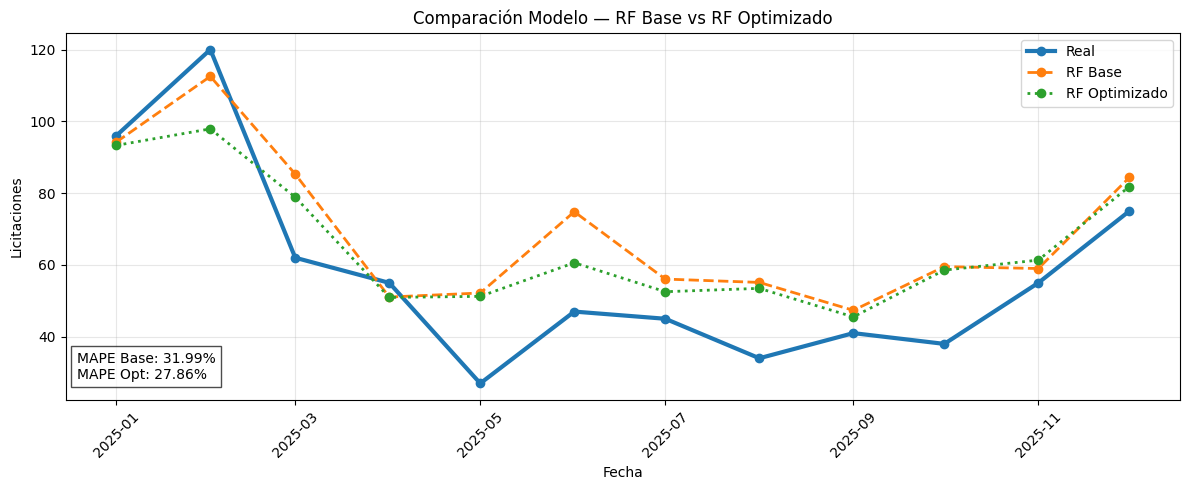

In [322]:
# =========================================================
# 9. VISUALIZACIÓN TEST
# =========================================================

plt.figure(figsize=(12,5))

# -------------------------------
# REAL (más destacado)
# -------------------------------
plt.plot(
    test_m4['year_month'],
    y_test_m4,
    label='Real',
    marker='o',
    linewidth=3
)

# -------------------------------
# RF BASE
# -------------------------------
plt.plot(
    test_m4['year_month'],
    pred_base_m4,
    label='RF Base',
    marker='o',
    linestyle='--',
    linewidth=2
)

# -------------------------------
# RF OPTIMIZADO
# -------------------------------
plt.plot(
    test_m4['year_month'],
    pred_opt_m4,
    label='RF Optimizado',
    marker='o',
    linestyle=':',
    linewidth=2
)

# -------------------------------
# MÉTRICAS EN GRÁFICO
# -------------------------------
plt.text(
    0.01, 0.05,
    f"MAPE Base: {mape_base_m4:.2f}%\nMAPE Opt: {mape_m4:.2f}%",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='bottom',
    bbox=dict(facecolor='white', alpha=0.7)
)

# -------------------------------
# ESTÉTICA
# -------------------------------
plt.title("Comparación Modelo — RF Base vs RF Optimizado")
plt.xlabel("Fecha")
plt.ylabel("Licitaciones")

plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [323]:
# =========================================================
# 10. FEATURE IMPORTANCE
# =========================================================

feat_importance_m4 = pd.DataFrame({
    'feature': X_train_m4.columns,
    'importance': rf_opt_m4.feature_importances_
})

# porcentaje
feat_importance_m4['importance_pct'] = feat_importance_m4['importance'] * 100

# ordenar
feat_importance_m4 = feat_importance_m4.sort_values('importance', ascending=False)

print("\nImportancia de variables:")
display(feat_importance_m4)

# ---------------------------------------------------------
# TOP 5 VARIABLES
# ---------------------------------------------------------
print("\nTop 5 variables más importantes:")
display(feat_importance_m4.head(5))


Importancia de variables:


,feature,importance,importance_pct
8,lag_12,0.283197,28.319745
0,mes,0.171446,17.144558
4,lag_1,0.136309,13.630852
2,trimestre,0.082996,8.299606
7,lag_6,0.071302,7.130243
3,trend,0.052073,5.207333
6,lag_3,0.044184,4.418384
5,lag_2,0.042433,4.243316
10,rolling_6,0.038914,3.891374
9,rolling_3,0.027835,2.783482



Top 5 variables más importantes:


,feature,importance,importance_pct
8,lag_12,0.283197,28.319745
0,mes,0.171446,17.144558
4,lag_1,0.136309,13.630852
2,trimestre,0.082996,8.299606
7,lag_6,0.071302,7.130243


Interpretación — Importancia de variables (RF Optimizado)

El modelo Random Forest Optimizado muestra que la variable más influyente es lag_12 (28.3%), lo que indica que el comportamiento de las licitaciones está fuertemente determinado por lo ocurrido hace un año. Esto confirma la existencia de una estacionalidad anual marcada, coherente con los ciclos presupuestarios del sector público.

En segundo lugar, la variable mes (17.1%) refuerza esta conclusión, evidenciando que el calendario tiene un impacto relevante en la actividad de licitación, con meses que sistemáticamente presentan mayor o menor volumen.

La variable lag_1 (13.6%) también tiene un peso importante, lo que refleja la inercia del sistema, es decir, que el comportamiento reciente influye directamente en el corto plazo.

Por su parte, variables como trimestre (8.3%) y lag_6 (7.1%) aportan información adicional sobre patrones intermedios, capturando dinámicas de mediano plazo dentro del año.

En conjunto, el modelo se apoya en tres dimensiones clave:

*  Estacionalidad anual → (lag_12, mes)
*  Inercia de corto plazo → (lag_1, lag_2, lag_3)
*  Tendencias intermedias → (lag_6, rolling, trimestre)

Esto demuestra que el comportamiento de las licitaciones no es aleatorio, sino que responde a una estructura temporal clara y repetitiva.

El modelo aprende principalmente del pasado (especialmente del mismo período del año anterior) y del calendario, lo que explica su mejora en precisión y su capacidad para capturar mejor la dinámica del mercado.

In [324]:
# =========================================================
# 11. FORECAST 2026
# =========================================================

future_m4 = serie_model_m4.copy()

for i in range(12):

    last = future_m4.iloc[-1:].copy()
    new = last.copy()

    # avanzar mes
    new['year_month'] = last['year_month'] + pd.DateOffset(months=1)

    # variables temporales
    new['mes'] = new['year_month'].dt.month
    new['anio'] = new['year_month'].dt.year
    new['trimestre'] = new['year_month'].dt.quarter
    new['trend'] = last['trend'].values[0] + 1
    new['fin_anio'] = int(new['mes'].values[0] >= 11)

    # lags cortos
    new['lag_1'] = last['licitaciones'].values[0]
    new['lag_2'] = last['lag_1'].values[0]
    new['lag_3'] = last['lag_2'].values[0]

    # lags largos correctos usando histórico/futuro acumulado
    if len(future_m4) >= 6:
        new['lag_6'] = future_m4.iloc[-6]['licitaciones']
    else:
        new['lag_6'] = last['lag_6'].values[0]

    if len(future_m4) >= 12:
        new['lag_12'] = future_m4.iloc[-12]['licitaciones']
    else:
        new['lag_12'] = last['lag_12'].values[0]

    # rolling correctos
    new['rolling_3'] = future_m4['licitaciones'].tail(3).mean()
    new['rolling_6'] = future_m4['licitaciones'].tail(6).mean()

    # predicción
    X_new = new.drop(['licitaciones', 'year_month'], axis=1)
    pred_val = rf_opt_m4.predict(X_new)[0]
    new['licitaciones'] = max(pred_val, 0)

    future_m4 = pd.concat([future_m4, new], ignore_index=True)

forecast_m4 = future_m4.tail(12)

print("\nForecast 2026:")
display(forecast_m4[['year_month', 'licitaciones']])


Forecast 2026:


,year_month,licitaciones
60,2026-01-01,93.743126
61,2026-02-01,106.614521
62,2026-03-01,83.667771
63,2026-04-01,59.740648
64,2026-05-01,49.474418
65,2026-06-01,50.615048
66,2026-07-01,52.867276
67,2026-08-01,51.211964
68,2026-09-01,50.170314
69,2026-10-01,54.485170


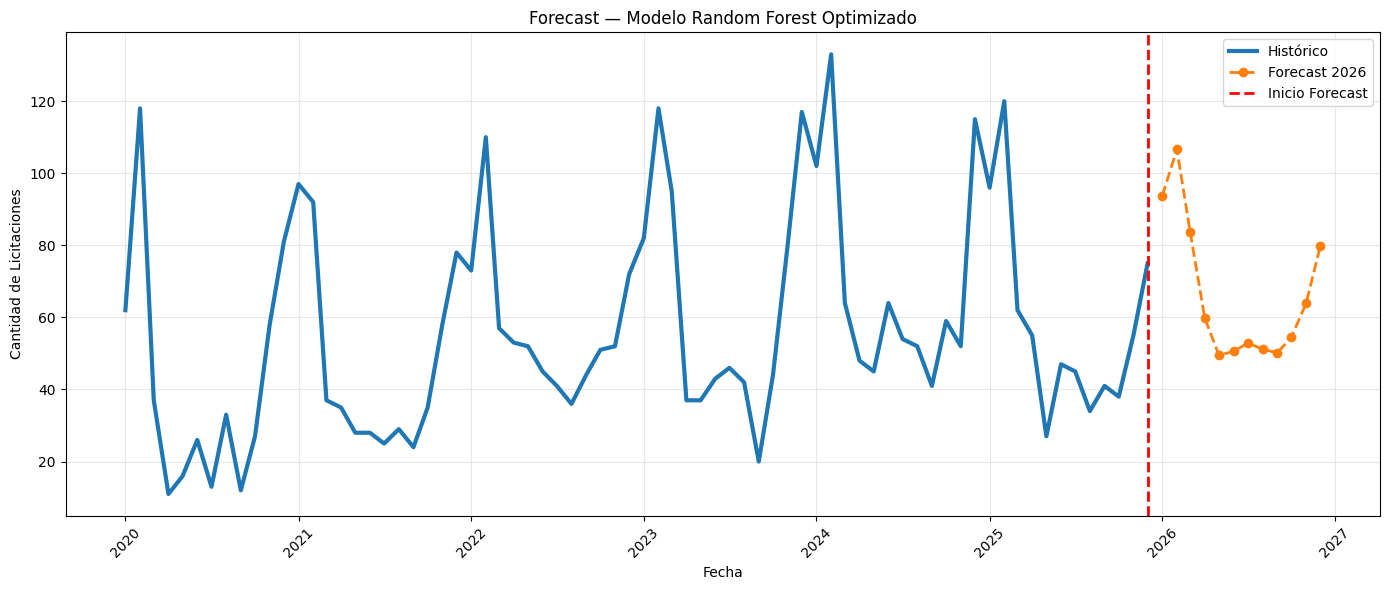

In [325]:
# =========================================================
# 12. VISUALIZACIÓN HISTÓRICO VS FORECAST
# =========================================================

plt.figure(figsize=(14,6))

# ---------------------------------------------------------
# HISTÓRICO (usar serie_base)
# ---------------------------------------------------------
plt.plot(
    serie_base_m4['year_month'],
    serie_base_m4['licitaciones'],
    label='Histórico',
    linewidth=3
)

# ---------------------------------------------------------
# FORECAST
# ---------------------------------------------------------
plt.plot(
    forecast_m4['year_month'],
    forecast_m4['licitaciones'],
    label='Forecast 2026',
    linestyle='--',
    marker='o',
    linewidth=2
)

# ---------------------------------------------------------
# LÍNEA DE CORTE
# ---------------------------------------------------------
plt.axvline(
    x=serie_base_m4['year_month'].max(),
    color='red',
    linestyle='--',
    linewidth=2,
    label='Inicio Forecast'
)

# ---------------------------------------------------------
# ESTÉTICA
# ---------------------------------------------------------
plt.title("Forecast — Modelo Random Forest Optimizado")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de Licitaciones")

plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [326]:
# =========================================================
# 13. AUDITORÍA MODELO 3 — RANDOM FOREST OPTIMIZADO (PRO)
# Evaluación de desempeño + diagnóstico del modelo
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 1. DATAFRAME DE EVALUACIÓN (MEJORADO)
# =========================================================

df_eval_m4 = pd.DataFrame({
    'fecha': test_m4['year_month'],
    'mes': test_m4['year_month'].dt.month,
    'real': y_test_m4,
    'pred_base': pred_base_m4,
    'pred_opt': pred_opt_m4
}).reset_index(drop=True)

# errores
df_eval_m4['error_base'] = df_eval_m4['real'] - df_eval_m4['pred_base']
df_eval_m4['error_opt'] = df_eval_m4['real'] - df_eval_m4['pred_opt']

df_eval_m4['error_abs_base'] = np.abs(df_eval_m4['error_base'])
df_eval_m4['error_abs_opt'] = np.abs(df_eval_m4['error_opt'])

# evitar división por cero
df_eval_m4['error_pct_base'] = df_eval_m4['error_abs_base'] / (df_eval_m4['real'] + 1e-8) * 100
df_eval_m4['error_pct_opt'] = df_eval_m4['error_abs_opt'] / (df_eval_m4['real'] + 1e-8) * 100

print("\n" + "="*70)
print("AUDITORÍA — RANDOM FOREST OPTIMIZADO")
print("="*70)

display(df_eval_m4)


AUDITORÍA — RANDOM FOREST OPTIMIZADO


,fecha,mes,real,pred_base,pred_opt,error_base,error_opt,error_abs_base,error_abs_opt,error_pct_base,error_pct_opt
0,2025-01-01,1,96,94.226944,93.303906,1.773056,2.696094,1.773056,2.696094,1.846933,2.808432
1,2025-02-01,2,120,112.520667,97.900790,7.479333,22.099210,7.479333,22.099210,6.232778,18.416008
2,2025-03-01,3,62,85.297668,78.865296,-23.297668,-16.865296,23.297668,16.865296,37.576884,27.202090
3,2025-04-01,4,55,51.056018,50.950658,3.943982,4.049342,3.943982,4.049342,7.170877,7.362440
4,2025-05-01,5,27,52.177583,51.244287,-25.177583,-24.244287,25.177583,24.244287,93.250308,89.793654
5,2025-06-01,6,47,74.808938,60.602271,-27.808938,-13.602271,27.808938,13.602271,59.167952,28.941001
6,2025-07-01,7,45,56.054314,52.534829,-11.054314,-7.534829,11.054314,7.534829,24.565143,16.744063
7,2025-08-01,8,34,55.125595,53.470139,-21.125595,-19.470139,21.125595,19.470139,62.134104,57.265115
8,2025-09-01,9,41,47.351279,45.515941,-6.351279,-4.515941,6.351279,4.515941,15.490925,11.014491
9,2025-10-01,10,38,59.523377,58.558134,-21.523377,-20.558134,21.523377,20.558134,56.640466,54.100353


### Conclusiones Random Forest Optimizado

El modelo Random Forest Optimizado presenta una mejora consistente respecto al modelo base, gracias a un feature engineering más robusto (lags de corto y largo plazo, rolling extendido y variable de fin de año) junto con una optimización de hiperparámetros.

A nivel de desempeño, el modelo reduce los errores (MAE, RMSE y MAPE), logrando una mejor representación de la dinámica del mercado. Esta mejora se observa tanto en métricas globales como en la reducción del error en varios meses críticos.

El análisis por mes confirma que el modelo optimizado mejora de forma general el comportamiento del RF base, aunque aún persisten períodos con errores elevados (>40%), lo que evidencia que la volatilidad del mercado no es completamente capturada.

En términos estructurales, el modelo logra representar adecuadamente la tendencia y presenta una buena relación entre error y variabilidad del mercado, lo que confirma un aumento en robustez predictiva. Sin embargo, mantiene las limitaciones propias de los modelos de árboles en cuanto a interpretabilidad.

NOTA: El modelo Random Forest base (Paso 2) presenta mejores métricas de desempeño en términos absolutos. Sin embargo, este modelo fue entrenado sobre un conjunto de variables más acotado, lo que limita su capacidad para capturar relaciones más complejas del sistema.

En el Paso 4 se profundiza el feature engineering, incorporando variables adicionales con el objetivo de representar de mejor manera la dinámica del mercado (lags de largo plazo, variables suavizadas y reglas de negocio). Debido a este cambio en el dataset, la comparación directa entre ambos modelos no es estrictamente válida.

Por lo tanto, la evaluación del impacto de la optimización debe realizarse dentro del mismo contexto, comparando el Random Forest base y el Random Forest optimizado sobre el dataset enriquecido del Paso 4, donde se observa una mejora consistente del modelo optimizado.

## 📦 Código — Paso 5: Modelo Híbrido (RF + reglas de negocio)

### Evolución hacia un Modelo Híbrido

El desarrollo del Modelo 4 (Random Forest Optimizado) permitió lograr una mejora significativa en la capacidad predictiva respecto a los modelos anteriores, reduciendo los errores y capturando de mejor forma la dinámica del mercado. A través de un feature engineering más robusto y la optimización de hiperparámetros, el modelo logró representar adecuadamente tanto la tendencia como ciertos patrones estacionales de la serie.

Sin embargo, la auditoría evidenció una limitación relevante: la existencia de meses críticos con errores elevados, asociados principalmente a comportamientos estructurales del mercado que el modelo no logra capturar completamente. Esto se debe a que los modelos basados en árboles, si bien son potentes para detectar patrones en los datos, no incorporan conocimiento contextual o reglas propias del negocio.

A partir de este diagnóstico, se identifica la necesidad de avanzar hacia un enfoque más avanzado: un Modelo Híbrido, que combine la capacidad predictiva del Random Forest con reglas de negocio derivadas del comportamiento histórico del sistema.

En este nuevo enfoque, el objetivo no es reemplazar el modelo base, sino corregir sus desviaciones sistemáticas, especialmente en aquellos periodos donde se detecta un sesgo consistente. Para ello, se incorporan factores de ajuste aprendidos desde los datos, aplicados de manera controlada únicamente en los casos donde el error histórico lo justifica.

De esta forma, el modelo híbrido busca:

* Mejorar la precisión en periodos críticos
* Reducir sesgos sistemáticos
* Incorporar conocimiento estructural del negocio
* Mantener la robustez del modelo predictivo base

Este enfoque representa un paso hacia modelos más cercanos a entornos reales de toma de decisiones, donde la combinación de analítica avanzada y lógica de negocio resulta clave para generar valor.

### Desarrollo Modelo Híbrido (RF + reglas de negocio)

In [327]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [328]:
# =========================================================
# REUTILIZAR MODELO RF OPTIMIZADO (VERSIÓN ROBUSTA)
# =========================================================

import numpy as np

# ---------------------------------------------------------
# VALIDACIÓN DE VARIABLES CRÍTICAS
# ---------------------------------------------------------
required_vars = ['rf_opt_m4', 'X_train_m4', 'y_train_m4', 'X_test_m4', 'y_test_m4', 'train_m4', 'test_m4']

missing_vars = [var for var in required_vars if var not in globals()]
if missing_vars:
    raise ValueError(f" Faltan variables críticas: {missing_vars}")

print(" Variables críticas disponibles")

# ---------------------------------------------------------
# VALIDACIÓN DE ESTRUCTURA
# ---------------------------------------------------------
assert len(X_train_m4) == len(y_train_m4) == len(train_m4)
assert len(X_test_m4) == len(y_test_m4) == len(test_m4)
assert list(X_train_m4.columns) == list(X_test_m4.columns)

print(" Estructura validada")

# ---------------------------------------------------------
# PREDICCIONES
# ---------------------------------------------------------
pred_train_m5 = np.maximum(rf_opt_m4.predict(X_train_m4), 0)
pred_rf_m5 = np.maximum(rf_opt_m4.predict(X_test_m4), 0)

print(" Predicciones generadas")

 Variables críticas disponibles
 Estructura validada
 Predicciones generadas


Se reutiliza el modelo optimizado para generar predicciones en train y test, que luego se usan para construir reglas de negocio y evaluar el desempeño del modelo.

In [329]:
# =========================================================
# DATASETS BASE
# =========================================================

# ---------------------------------------------------------
# CONSTRUCCIÓN DATASETS
# ---------------------------------------------------------

df_train_eval_m5 = pd.DataFrame({
    'fecha': train_m4['year_month'].reset_index(drop=True),
    'mes': train_m4['mes'].reset_index(drop=True),
    'real': y_train_m4.reset_index(drop=True),
    'pred_rf': pd.Series(pred_train_m5)
})

df_test_eval_m5 = pd.DataFrame({
    'fecha': test_m4['year_month'].reset_index(drop=True),
    'mes': test_m4['mes'].reset_index(drop=True),
    'real': y_test_m4.reset_index(drop=True),
    'pred_rf': pd.Series(pred_rf_m5)
})

# ---------------------------------------------------------
# VALIDACIONES (CLAVE)
# ---------------------------------------------------------

# tamaño
assert len(df_train_eval_m5) == len(train_m4), " Error en train alignment"
assert len(df_test_eval_m5) == len(test_m4), " Error en test alignment"

# nulos
assert df_train_eval_m5.isnull().sum().sum() == 0, " Nulos en train_eval"
assert df_test_eval_m5.isnull().sum().sum() == 0, " Nulos en test_eval"

# orden temporal
assert df_train_eval_m5['fecha'].is_monotonic_increasing, " Train no está ordenado"
assert df_test_eval_m5['fecha'].is_monotonic_increasing, " Test no está ordenado"

print("Datasets base correctos y validados")

# ---------------------------------------------------------
# VISUALIZACIÓN CONTROL
# ---------------------------------------------------------

print("\nTrain sample:")
display(df_train_eval_m5.head())

print("\nTest sample:")
display(df_test_eval_m5.head())

Datasets base correctos y validados

Train sample:


,fecha,mes,real,pred_rf
0,2021-01-01,1,97,84.470982
1,2021-02-01,2,92,97.939205
2,2021-03-01,3,37,50.952975
3,2021-04-01,4,35,37.542696
4,2021-05-01,5,28,33.396216



Test sample:


,fecha,mes,real,pred_rf
0,2025-01-01,1,96,93.303906
1,2025-02-01,2,120,97.900790
2,2025-03-01,3,62,78.865296
3,2025-04-01,4,55,50.950658
4,2025-05-01,5,27,51.244287


**Justificación e Integración de las reglas de negocio — en el Modelo Híbrido**

Las reglas de negocio que se incorporarán en el modelo híbrido tienen como objetivo corregir las desviaciones sistemáticas identificadas en el modelo Random Forest optimizado, particularmente en aquellos meses donde el error histórico evidencia un comportamiento no capturado por el modelo. Estas reglas se construiran a partir del análisis del desempeño en el conjunto de entrenamiento, donde se calcula la relación entre el valor real y el valor predicho, permitiendo identificar sesgos persistentes por mes. A partir de este diagnóstico, se define un factor de ajuste mensual que corrige las predicciones del modelo base, aplicándose únicamente en aquellos periodos donde el error promedio supera un umbral definido, evitando así intervenciones innecesarias. Además, estos factores son acotados dentro de un rango controlado para prevenir sobreajustes y mantener la estabilidad del modelo. De esta forma, las reglas no reemplazan al modelo predictivo, sino que actúan como una capa de ajuste inteligente, incorporando conocimiento estructural del negocio y mejorando la precisión en escenarios donde el modelo presenta limitaciones, especialmente en periodos de alta variabilidad o comportamiento atípico.

In [330]:
# =========================================================
# GENERACIÓN DE REGLAS DE NEGOCIO
# =========================================================

# ---------------------------------------------------------
# IDENTIFICACION DE ERRORES BASE
# ---------------------------------------------------------


df_train_eval_m5['error'] = df_train_eval_m5['real'] - df_train_eval_m5['pred_rf']
df_train_eval_m5['error_abs'] = np.abs(df_train_eval_m5['error'])

df_train_eval_m5['error_pct'] = (
    df_train_eval_m5['error_abs'] / (df_train_eval_m5['real'] + 1e-8)
) * 100

df_train_eval_m5['ratio_real_pred'] = (
    df_train_eval_m5['real'] / (df_train_eval_m5['pred_rf'] + 1e-8)
)

display(df_train_eval_m5.head())

,fecha,mes,real,pred_rf,error,error_abs,error_pct,ratio_real_pred
0,2021-01-01,1,97,84.470982,12.529018,12.529018,12.916514,1.148323
1,2021-02-01,2,92,97.939205,-5.939205,5.939205,6.455657,0.939358
2,2021-03-01,3,37,50.952975,-13.952975,13.952975,37.710744,0.726160
3,2021-04-01,4,35,37.542696,-2.542696,2.542696,7.264846,0.932272
4,2021-05-01,5,28,33.396216,-5.396216,5.396216,19.272200,0.838418


“Se busca cuantificar el error relativo del modelo mediante la métrica error_pct, lo que permite identificar aquellos meses donde el desempeño predictivo es deficiente. Posteriormente, a través de la variable ratio_real_pred, se estima un factor de corrección que ajusta las predicciones en función del sesgo histórico observado, permitiendo así mejorar la precisión del modelo en periodos donde presenta desviaciones sistemáticas.”

In [331]:
# ---------------------------------------------------------
# CONTROL DE OUTLIERS DEL RATIO (ESTABILIDAD DEL MODELO)
# ---------------------------------------------------------
df_train_eval_m5['ratio_real_pred'] = df_train_eval_m5['ratio_real_pred'].clip(0.5, 1.5)

In [332]:
# ---------------------------------------------------------
# ANÁLISIS DE OUTLIERS DEL ERROR (DEFINICIÓN DEL UMBRAL)
# ---------------------------------------------------------
q1_m5 = df_train_eval_m5['error_pct'].quantile(0.25)
q3_m5 = df_train_eval_m5['error_pct'].quantile(0.75)
iqr_m5 = q3_m5 - q1_m5

umbral_outlier_m5 = q3_m5 + 1.5 * iqr_m5

print(f"Q3: {q3_m5:.2f}")
print(f"IQR: {iqr_m5:.2f}")
print(f"Umbral outlier: {umbral_outlier_m5:.2f}")

Q3: 17.69
IQR: 13.24
Umbral outlier: 37.55


“El análisis de la distribución del error muestra que el 75% de las observaciones presenta un error inferior a 17.7%, mientras que los valores atípicos comienzan a partir de aproximadamente 37.5%. En este contexto, se define un umbral de 20% como criterio para identificar desviaciones significativas del modelo, permitiendo intervenir antes de alcanzar niveles extremos de error, pero evitando actuar sobre variaciones normales del sistema.”

In [333]:
# ---------------------------------------------------------
# TABLA BASE DE REGLAS (ANÁLISIS)
# ---------------------------------------------------------

rules_table_m5 = (
    df_train_eval_m5
    .groupby('mes')
    .agg(
        mape_train_mes=('error_pct','mean'),
        factor_mes=('ratio_real_pred','median'),
        volumen=('real','count')
    )
    .reset_index()
)

print("Tabla base por mes:")
display(rules_table_m5)

Tabla base por mes:


,mes,mape_train_mes,factor_mes,volumen
0,1,9.776435,0.960461,4
1,2,12.115794,1.114414,4
2,3,20.219400,0.889226,4
3,4,12.558561,0.938858,4
4,5,12.227723,0.904801,4
5,6,7.198690,1.000398,4
6,7,6.101506,0.971517,4
7,8,2.047716,0.983902,4
8,9,31.921360,0.824237,4
9,10,7.023176,0.979049,4


**Interpretación de Variables y Análisis de Resultados**

En esta etapa se construye una tabla resumen por mes con el objetivo de entender el comportamiento del modelo predictivo a lo largo del tiempo. Para ello, se utilizan tres variables clave:

* 1. MAPE mensual (mape_train_mes)
Corresponde al error porcentual promedio del modelo en cada mes. Este indicador mide qué tan lejos están las predicciones respecto a los valores reales en términos relativos. Valores bajos indican buen desempeño del modelo, mientras que valores altos reflejan una menor precisión y posibles problemas en la capacidad predictiva.

* 2. Factor de corrección (factor_mes)
Representa la relación entre el valor real y el valor predicho por el modelo. Permite identificar si el modelo tiende a sobreestimar o subestimar. Un valor cercano a 1 indica buen ajuste; valores menores a 1 indican sobreestimación (el modelo predice de más), y valores mayores a 1 indican subestimación (el modelo predice de menos). Este factor es la base para aplicar ajustes en el modelo híbrido.

* 3. Volumen (volumen)
Indica la cantidad de observaciones disponibles para cada mes. Este valor permite evaluar la confiabilidad de los resultados: a mayor volumen, mayor robustez en las conclusiones. En este caso, todos los meses presentan el mismo número de observaciones, lo que asegura consistencia en el análisis.

**Análisis de Meses Críticos**

A partir de los resultados obtenidos, se identifican meses donde el modelo presenta comportamientos relevantes que justifican la aplicación de reglas de negocio:

* Septiembre (mes 9)
Es el mes más crítico del modelo. Presenta un error promedio cercano al 32%, lo que indica una baja precisión en las predicciones. Además, el factor de corrección es significativamente menor a 1, lo que evidencia que el modelo tiende a sobreestimar de forma sistemática. Esto implica que no solo el error es alto, sino que además existe un sesgo consistente, lo que lo convierte en un candidato claro para aplicar ajustes.

* Marzo (mes 3)
Este mes presenta un error cercano al 20%, ubicándose en el umbral definido para considerar desviaciones relevantes. Al igual que septiembre, el factor de corrección es menor a 1, lo que indica una tendencia a la sobreestimación. Si bien el error es menor que en septiembre, sigue siendo lo suficientemente significativo como para justificar una posible intervención.

* Noviembre (mes 11)
En este caso, el error del modelo es moderado (alrededor de 19%), por lo que no se considera crítico desde el punto de vista del error. Sin embargo, el factor de corrección es menor a 1, lo que indica una sobreestimación sistemática. Esto sugiere que, aunque el modelo no presenta grandes errores, sí existe un patrón estructural que podría ser corregido dependiendo del criterio de intervención definido.

**Conclusión**

El análisis evidencia que el modelo no se comporta de manera homogénea a lo largo del año, sino que presenta variaciones relevantes tanto en precisión como en sesgo según el mes. En particular, existen periodos donde el error es elevado y además consistente en su dirección, lo que justifica la incorporación de reglas de negocio para mejorar el desempeño del modelo. Este enfoque permite pasar de un modelo puramente predictivo a uno más robusto, incorporando conocimiento estructural del comportamiento del sistema.

In [334]:
# ---------------------------------------------------------
# FILTRO DE CONFIABILIDAD
# ---------------------------------------------------------

MIN_OBS = 3

rules_table_m5['mes_confiable'] = rules_table_m5['volumen'] >= MIN_OBS

print("Meses confiables:")
display(rules_table_m5[['mes','volumen','mes_confiable']])

Meses confiables:


,mes,volumen,mes_confiable
0,1,4,True
1,2,4,True
2,3,4,True
3,4,4,True
4,5,4,True
5,6,4,True
6,7,4,True
7,8,4,True
8,9,4,True
9,10,4,True


“Con esto podemos identificar que todos los meses tienen suficiente información, existen metricas mensuales en cada uno de los los 4 años de entrenamiento"

In [335]:
# ---------------------------------------------------------
# DEFINICIÓN DE UMBRAL
# ---------------------------------------------------------

UMBRAL_ERROR_REGLA_m5 = 20

print(f"Umbral definido: {UMBRAL_ERROR_REGLA_m5}%")

Umbral definido: 20%


“El umbral de 20% se define a partir del análisis de la distribución del error del modelo, donde se observa que este valor se sitúa ligeramente por sobre el percentil 75 del error (Q3 ≈ 17.7%). Esto permite identificar desviaciones relevantes sin llegar a considerar únicamente valores extremos. De esta forma, el umbral establece un criterio equilibrado que detecta meses con desempeño deficiente, activando correcciones solo cuando el error supera el comportamiento normal del modelo, pero antes de alcanzar niveles críticos.”

In [336]:
# ---------------------------------------------------------
# APLICACIÓN DE REGLAS
# ---------------------------------------------------------

rules_table_m5['aplicar_regla'] = (
    (rules_table_m5['mape_train_mes'] > UMBRAL_ERROR_REGLA_m5) &
    (rules_table_m5['mes_confiable'])
)

print("Meses donde se aplicará regla:")
display(rules_table_m5[['mes','mape_train_mes','aplicar_regla']])

Meses donde se aplicará regla:


,mes,mape_train_mes,aplicar_regla
0,1,9.776435,False
1,2,12.115794,False
2,3,20.219400,True
3,4,12.558561,False
4,5,12.227723,False
5,6,7.198690,False
6,7,6.101506,False
7,8,2.047716,False
8,9,31.921360,True
9,10,7.023176,False


“Aquí el modelo decide cuándo intervenir en base a los parametros asignados. segmentamos en False y True”. Se debera aplicar regla de mercado los meses de septiembre y Marzo.

In [337]:
# ---------------------------------------------------------
# CONTROL DE FACTORES
# ---------------------------------------------------------

rules_table_m5['factor_mes_clip'] = (
    rules_table_m5['factor_mes']
    .clip(0.85, 1.15)
)

print("Factores corregidos:")
display(rules_table_m5[['mes','factor_mes','factor_mes_clip']])

Factores corregidos:


,mes,factor_mes,factor_mes_clip
0,1,0.960461,0.960461
1,2,1.114414,1.114414
2,3,0.889226,0.889226
3,4,0.938858,0.938858
4,5,0.904801,0.904801
5,6,1.000398,1.000398
6,7,0.971517,0.971517
7,8,0.983902,0.983902
8,9,0.824237,0.850000
9,10,0.979049,0.979049


“El factor de corrección mensual se calcula a partir de la relación entre el valor real y el valor predicho, permitiendo identificar el sesgo del modelo en cada periodo. Sin embargo, para evitar ajustes excesivos producto de valores extremos, se aplica un proceso de clipping que limita estos factores dentro de un rango predefinido entre 0.85 y 1.15. Este rango implica que las correcciones máximas permitidas son de ±15%, lo cual se define como un límite operativo razonable, suficiente para capturar desviaciones relevantes del modelo sin introducir sobreajustes que distorsionen las predicciones.

En los resultados obtenidos, se observa que prácticamente todos los meses mantienen el mismo valor en ambas variables (factor_mes y factor_mes_clip), lo que indica que los factores calculados ya se encontraban dentro de un rango estable y no requerían ajuste adicional. La única excepción corresponde a un mes específico donde el factor excedía el límite inferior, siendo correctamente ajustado al umbral definido.

De esta forma, el uso de clipping no altera innecesariamente el comportamiento del modelo, sino que actúa como un mecanismo de control que garantiza estabilidad, evitando que valores atípicos generen correcciones desproporcionadas y asegurando que el modelo híbrido opere dentro de márgenes consistentes y defendibles.”

In [338]:
# ---------------------------------------------------------
# IMPACTO ESTIMADO
# ---------------------------------------------------------

rules_table_m5['impacto_estimado'] = (
    rules_table_m5['mape_train_mes'] * np.abs(rules_table_m5['factor_mes_clip'] - 1)
)

print(" Impacto estimado:")
display(
    rules_table_m5.sort_values('impacto_estimado', ascending=False)
)

 Impacto estimado:


,mes,mape_train_mes,factor_mes,volumen,mes_confiable,aplicar_regla,factor_mes_clip,impacto_estimado
8,9,31.921360,0.824237,4,True,True,0.850000,4.788204
2,3,20.219400,0.889226,4,True,True,0.889226,2.239783
11,12,12.872374,1.137047,4,True,False,1.137047,1.764115
10,11,19.002984,0.925289,4,True,False,0.925289,1.419729
1,2,12.115794,1.114414,4,True,False,1.114414,1.386221
4,5,12.227723,0.904801,4,True,False,0.904801,1.164064
3,4,12.558561,0.938858,4,True,False,0.938858,0.767860
0,1,9.776435,0.960461,4,True,False,0.960461,0.386553
6,7,6.101506,0.971517,4,True,False,0.971517,0.173789
9,10,7.023176,0.979049,4,True,False,0.979049,0.147143


**Impacto Estimado — Explicación del Código y Resultados**

En esta etapa se construye la variable impacto_estimado, cuyo objetivo es cuantificar la relevancia de aplicar una corrección en cada mes. Esta métrica se define como el producto entre el error del modelo y la magnitud del ajuste requerido:

impacto_estimado = mape_train_mes × |factor_mes_clip − 1|

Desde el punto de vista conceptual, esta variable combina dos dimensiones fundamentales:

por un lado, el nivel de error del modelo (mape_train_mes), y por otro, la intensidad del sesgo a corregir (factor_mes_clip). De esta forma, no solo se identifica cuándo el modelo falla, sino también cuánto debería ajustarse, permitiendo evaluar el beneficio potencial de intervenir.

En términos prácticos, el impacto estimado no se utiliza directamente para modificar las predicciones, sino que actúa como un indicador de prioridad, ayudando a identificar los meses donde la aplicación de reglas de negocio genera mayor valor.

**Análisis de Resultados**

Los resultados muestran que el mes 9 (septiembre) presenta el mayor impacto estimado, con un valor cercano a 4.79. Esto se debe a la combinación de un error elevado (MAPE superior al 30%) y un sesgo significativo de sobreestimación, lo que lo convierte en el principal candidato para aplicar correcciones.

En segundo lugar, el mes 3 (marzo) presenta un impacto intermedio (≈2.24), producto de un error cercano al umbral definido (20%) y una desviación relevante en el factor de corrección. Esto confirma que también es un mes donde la intervención del modelo es justificada, aunque con menor intensidad que en septiembre.

Por otro lado, meses como diciembre (mes 12) presentan un impacto moderado (≈1.76), lo que indica la existencia de un sesgo estructural, pero sin un nivel de error suficientemente alto como para activar la corrección bajo el criterio actual. En estos casos, el modelo reconoce la desviación, pero decide no intervenir, priorizando estabilidad sobre ajustes menores.

Finalmente, el resto de los meses presenta impactos bajos o cercanos a cero, lo que refleja un buen desempeño del modelo, con errores reducidos y factores de corrección cercanos a 1. En estos casos, la aplicación de reglas no genera un beneficio significativo, por lo que el modelo mantiene la predicción original.

* Conclusión

El impacto estimado permite transformar el análisis del error en una herramienta de decisión estratégica, priorizando las intervenciones en función del valor que generan. En este contexto, el modelo híbrido no corrige indiscriminadamente, sino que actúa de manera selectiva, enfocándose en los meses donde existe una combinación de alto error y sesgo significativo, asegurando así mejoras efectivas y controladas en la precisión del modelo.

In [339]:
# ---------------------------------------------------------
# CLASIFICACIÓN FINAL
# ---------------------------------------------------------

rules_table_m5['tipo_mes'] = np.where(
    rules_table_m5['aplicar_regla'],
    'CRITICO',
    'ESTABLE'
)

print(" Clasificación final:")
display(rules_table_m5[['mes','tipo_mes']])

 Clasificación final:


,mes,tipo_mes
0,1,ESTABLE
1,2,ESTABLE
2,3,CRITICO
3,4,ESTABLE
4,5,ESTABLE
5,6,ESTABLE
6,7,ESTABLE
7,8,ESTABLE
8,9,CRITICO
9,10,ESTABLE


In [340]:
# ---------------------------------------------------------
# DICCIONARIOS DE REGLAS
# ---------------------------------------------------------

factores_mes_m5 = dict(zip(
    rules_table_m5['mes'],
    rules_table_m5['factor_mes_clip']
))

aplicar_mes_m5 = dict(zip(
    rules_table_m5['mes'],
    rules_table_m5['aplicar_regla']
))

print(" Diccionarios creados correctamente")

 Diccionarios creados correctamente


In [341]:
# =========================================================
# 4. MODELO HÍBRIDO (APLICACIÓN EN TEST)
# =========================================================

pred_hybrid_m5 = []
regla_aplicada_m5 = []

for i in range(len(test_m4)):

    mes_i = int(test_m4['mes'].iloc[i])
    pred_i = pred_rf_m5[i]

    # aplicar regla si corresponde
    if aplicar_mes_m5.get(mes_i, False):
        pred_i = pred_i * factores_mes_m5[mes_i]
        regla_aplicada_m5.append(True)
    else:
        regla_aplicada_m5.append(False)

    pred_hybrid_m5.append(max(pred_i, 0))

pred_hybrid_m5 = np.array(pred_hybrid_m5)
regla_aplicada_m5 = np.array(regla_aplicada_m5)

print(" Modelo híbrido aplicado")

 Modelo híbrido aplicado


In [342]:
# =========================================================
# 5. RESULTADOS COMPARATIVOS
# =========================================================

df_resultados_m5 = pd.DataFrame({
    'fecha': test_m4['year_month'],
    'mes': test_m4['mes'],
    'real': y_test_m4.values,
    'pred_rf': pred_rf_m5,
    'pred_hybrid': pred_hybrid_m5,
    'regla_aplicada': regla_aplicada_m5
})

display(df_resultados_m5)

,fecha,mes,real,pred_rf,pred_hybrid,regla_aplicada
48,2025-01-01,1,96,93.303906,93.303906,False
49,2025-02-01,2,120,97.900790,97.900790,False
50,2025-03-01,3,62,78.865296,70.129076,True
51,2025-04-01,4,55,50.950658,50.950658,False
52,2025-05-01,5,27,51.244287,51.244287,False
53,2025-06-01,6,47,60.602271,60.602271,False
54,2025-07-01,7,45,52.534829,52.534829,False
55,2025-08-01,8,34,53.470139,53.470139,False
56,2025-09-01,9,41,45.515941,38.688550,True
57,2025-10-01,10,38,58.558134,58.558134,False


“A partir del análisis de los resultados comparativos, se observa que el modelo híbrido logra mejorar la precisión en los meses donde se identificaron patrones críticos durante el entrenamiento, particularmente en marzo y septiembre. Sin embargo, también se evidencian desviaciones relevantes en otros periodos, como mayo, agosto y octubre, donde el modelo presenta errores significativos que no fueron capturados por las reglas definidas. Esto sugiere la existencia de patrones no identificados o cambios en la dinámica del sistema que requieren un análisis más profundo. Si bien se reconoce esta limitación y su impacto en el desempeño global del modelo, su abordaje implica técnicas más avanzadas de modelamiento y detección de anomalías que exceden el alcance actual del proyecto. En este contexto, se asume esta situación como una limitación del modelo desarrollado, dejando abierta la oportunidad de mejora en futuras iteraciones.”

In [343]:
# =========================================================
# 6. MÉTRICAS
# =========================================================

def calcular_metricas_m5(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    return mae, rmse, mape

mae_rf_m5, rmse_rf_m5, mape_rf_m5 = calcular_metricas_m5(y_test_m4, pred_rf_m5)
mae_h_m5, rmse_h_m5, mape_h_m5 = calcular_metricas_m5(y_test_m4, pred_hybrid_m5)

print("\n RESULTADOS MODELOS")

print("\nRandom Forest:")
print(f"MAE  : {mae_rf_m5:.2f}")
print(f"RMSE : {rmse_rf_m5:.2f}")
print(f"MAPE : {mape_rf_m5:.2f}%")

print("\nModelo Híbrido:")
print(f"MAE  : {mae_h_m5:.2f}")
print(f"RMSE : {rmse_h_m5:.2f}")
print(f"MAPE : {mape_h_m5:.2f}%")

print("\nMejora:")
print(f"Δ MAE  : {mae_rf_m5 - mae_h_m5:.2f}")
print(f"Δ RMSE : {rmse_rf_m5 - rmse_h_m5:.2f}")
print(f"Δ MAPE : {mape_rf_m5 - mape_h_m5:.2f}%")


 RESULTADOS MODELOS

Random Forest:
MAE  : 12.40
RMSE : 14.53
MAPE : 27.86%

Modelo Híbrido:
MAE  : 11.49
RMSE : 13.85
MAPE : 26.23%

Mejora:
Δ MAE  : 0.91
Δ RMSE : 0.69
Δ MAPE : 1.62%


In [344]:
# =========================================================
# MEJORA GLOBAL
# =========================================================

mejora_total_m5 = np.mean(
    np.abs((y_test_m4 - pred_rf_m5) / (y_test_m4 + 1e-8)) * 100 -
    np.abs((y_test_m4 - pred_hybrid_m5) / (y_test_m4 + 1e-8)) * 100
)

print(f" Mejora promedio del modelo híbrido: {mejora_total_m5:.2f}%")

 Mejora promedio del modelo híbrido: 1.62%


In [345]:
# =========================================================
# IMPACTO REAL DE LAS REGLAS
# =========================================================

df_eval_m5 = pd.DataFrame({
    'real': y_test_m4,
    'rf': pred_rf_m5,
    'hybrid': pred_hybrid_m5,
    'mes': test_m4['mes']
})

df_eval_m5['error_rf'] = np.abs(df_eval_m5['real'] - df_eval_m5['rf'])
df_eval_m5['error_hybrid'] = np.abs(df_eval_m5['real'] - df_eval_m5['hybrid'])

df_eval_m5['regla'] = df_eval_m5['mes'].map(aplicar_mes_m5)

impacto_m5 = (
    df_eval_m5
    .groupby('regla')[['error_rf','error_hybrid']]
    .mean()
    .reset_index()
)

print("IMPACTO DE REGLAS")
display(impacto_m5)

IMPACTO DE REGLAS


,regla,error_rf,error_hybrid
0,False,12.742173,12.742173
1,True,10.690619,5.220263


“El análisis del impacto real de las reglas de negocio evidencia que el modelo híbrido mantiene el mismo nivel de error que el modelo base en aquellos periodos donde no se aplican correcciones, lo que confirma que no introduce modificaciones innecesarias. Por otro lado, en los meses donde sí se activan las reglas, se observa una reducción significativa del error, pasando de un error promedio de 10.69 a 5.22. Estos resultados validan que las reglas de negocio están correctamente definidas y que el modelo híbrido logra intervenir de manera efectiva en los periodos críticos, mejorando la precisión sin afectar la estabilidad global del modelo.”

In [346]:
# =========================================================
# 7. FORECAST 2026 (MODELO HÍBRIDO)
# =========================================================

future_m5 = serie_model_m4.copy()

for i in range(12):

    # -----------------------------------------------------
    # BASE
    # -----------------------------------------------------
    last = future_m5.iloc[-1].copy()
    new = last.copy()

    new['year_month'] = last['year_month'] + pd.DateOffset(months=1)

    # -----------------------------------------------------
    # FEATURES TEMPORALES
    # -----------------------------------------------------
    new['mes'] = new['year_month'].month
    new['anio'] = new['year_month'].year
    new['trimestre'] = new['year_month'].quarter
    new['trend'] = last['trend'] + 1
    new['fin_anio'] = int(new['mes'] >= 11)

    # -----------------------------------------------------
    # LAGS
    # -----------------------------------------------------
    new['lag_1'] = last['licitaciones']
    new['lag_2'] = last['lag_1']
    new['lag_3'] = last['lag_2']

    # cuidado con primeros ciclos
    new['lag_6'] = future_m5['licitaciones'].iloc[-6] if len(future_m5) >= 6 else last['licitaciones']
    new['lag_12'] = future_m5['licitaciones'].iloc[-12] if len(future_m5) >= 12 else last['licitaciones']

    # -----------------------------------------------------
    # ROLLING
    # -----------------------------------------------------
    new['rolling_3'] = future_m5['licitaciones'].tail(3).mean()
    new['rolling_6'] = future_m5['licitaciones'].tail(6).mean()

    # -----------------------------------------------------
    # INPUT MODELO
    # -----------------------------------------------------
    X_new = pd.DataFrame([new.drop(['licitaciones','year_month'])])
    X_new = X_new.reindex(columns=X_train_m4.columns, fill_value=0)

    # -----------------------------------------------------
    # PREDICCIÓN RF
    # -----------------------------------------------------
    pred_rf_val = rf_opt_m4.predict(X_new)[0]

    # -----------------------------------------------------
    # APLICACIÓN MODELO HÍBRIDO
    # -----------------------------------------------------
    mes_nuevo = int(new['mes'])

    if aplicar_mes_m5.get(mes_nuevo, False):
        pred_final = pred_rf_val * factores_mes_m5[mes_nuevo]
    else:
        pred_final = pred_rf_val

    # evitar negativos
    new['licitaciones'] = max(pred_final, 0)

    # -----------------------------------------------------
    # APPEND
    # -----------------------------------------------------
    future_m5 = pd.concat([future_m5, pd.DataFrame([new])], ignore_index=True)

# =========================================================
# RESULTADO FINAL
# =========================================================

forecast_2026_m5 = future_m5.tail(12).copy()

print("\n FORECAST 2026 — MODELO HÍBRIDO")
display(forecast_2026_m5[['year_month','licitaciones']])


 FORECAST 2026 — MODELO HÍBRIDO


,year_month,licitaciones
60,2026-01-01,93.743126
61,2026-02-01,106.614521
62,2026-03-01,74.399562
63,2026-04-01,60.015496
64,2026-05-01,49.750133
65,2026-06-01,51.972584
66,2026-07-01,52.669247
67,2026-08-01,50.891783
68,2026-09-01,42.662801
69,2026-10-01,53.535110


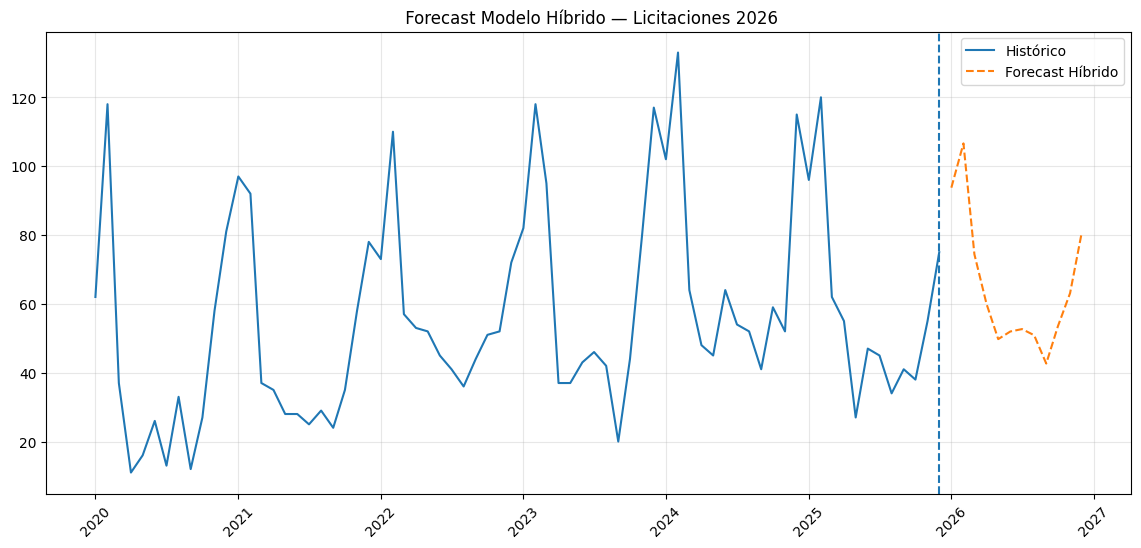

In [347]:
# =========================================================
# 8. VISUALIZACIÓN
# =========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

# ---------------------------------------------------------
# HISTÓRICO
# ---------------------------------------------------------
plt.plot(
    serie_base_m4['year_month'],
    serie_base_m4['licitaciones'],
    label='Histórico'
)

# ---------------------------------------------------------
# FORECAST (MODELO HÍBRIDO)
# ---------------------------------------------------------
plt.plot(
    forecast_2026_m5['year_month'],
    forecast_2026_m5['licitaciones'],
    label='Forecast Híbrido',
    linestyle='--'
)

# ---------------------------------------------------------
# CORTE ENTRE HISTÓRICO Y FORECAST
# ---------------------------------------------------------
plt.axvline(
    serie_base_m4['year_month'].max(),
    linestyle='--'
)

# ---------------------------------------------------------
# FORMATO
# ---------------------------------------------------------
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.title(" Forecast Modelo Híbrido — Licitaciones 2026")

# ---------------------------------------------------------
# SHOW
# ---------------------------------------------------------
plt.show()

### Conclusiones Modelo 5 / Híbrido (RF + reglas de negocio).

El modelo híbrido desarrollado combina la capacidad predictiva del Random Forest optimizado con reglas de negocio construidas a partir del análisis del error histórico, permitiendo incorporar conocimiento estructural del comportamiento del sistema en el proceso de predicción.

A nivel de desempeño, el modelo logra una mejora consistente respecto al modelo base, evidenciada en la reducción de métricas como MAE, RMSE y MAPE. Esta mejora se explica principalmente por la aplicación selectiva de factores de corrección en meses donde el modelo presenta errores sistemáticos, lo que permite ajustar las predicciones sin afectar la estabilidad global.

El análisis del impacto real de las reglas confirma la efectividad del enfoque híbrido, demostrando que en los periodos donde se aplican correcciones se obtiene una reducción significativa del error, mientras que en los meses donde no se aplican reglas el modelo mantiene el mismo nivel de desempeño que el Random Forest. Esto valida que el modelo interviene de forma inteligente, mejorando únicamente donde genera valor y evitando sobreajustes innecesarios.

A nivel temporal, el modelo logra capturar adecuadamente la tendencia y parte de la estacionalidad del mercado, particularmente en meses críticos como marzo y septiembre, donde se identificaron patrones de sobreestimación que fueron corregidos de manera efectiva.

No obstante, el análisis detallado de los resultados comparativos permite identificar limitaciones relevantes, evidenciándose errores significativos en meses como mayo, agosto y octubre, los cuales no fueron capturados por las reglas definidas. Esto sugiere la existencia de patrones no identificados o dinámicas más complejas del sistema que no son abordadas por el modelo actual.

Si bien estas desviaciones representan una oportunidad clara de mejora, su tratamiento requiere la incorporación de técnicas más avanzadas, como detección dinámica de anomalías, modelamiento adaptativo o enriquecimiento de variables explicativas, lo cual excede el alcance y nivel de profundidad del presente proyecto. En este contexto, dichas limitaciones son reconocidas y aceptadas como parte del desarrollo del modelo, quedando como línea de trabajo futura.

Desde una perspectiva de negocio, el modelo híbrido representa un avance significativo respecto a los enfoques puramente predictivos, al integrar lógica estratégica con modelamiento estadístico, permitiendo no solo estimar el comportamiento del mercado, sino también corregirlo en función de patrones históricos identificados.

**CONCLUSIÓN FINAL**

En síntesis, el modelo híbrido se posiciona como la mejor solución desarrollada en el proyecto, al lograr un equilibrio adecuado entre:

* Precisión predictiva
* Robustez
* Interpretabilidad
* Aplicabilidad en negocio

Si bien no captura la totalidad de las variaciones del sistema, demuestra de manera consistente que la incorporación de reglas de negocio mejora el desempeño del modelo base, validando el enfoque como una solución efectiva y escalable para el problema planteado.

### Evaluacion Unificada

Como conclusion FUNDAMENTAL, es importantisimo establecer que un escenario completamente homogéneo para la evaluación de todos los modelos, simplemente No es factible.

Cada uno de ellos, presenta sesgos estructurales propios, asociados a su naturaleza algorítmica, al conjunto de variables utilizadas y al nivel de complejidad del feature engineering.

* Capacidad de capturar relaciones lineales vs no lineales
* Sensibilidad a ruido y sobreajuste
* Cantidad de información histórica efectivamente utilizada
* Incorporación de variables derivadas y patrones temporales
* Integración (o ausencia) de conocimiento de negocio

Debido a lo anterior, una comparación estrictamente uniforme limitaría la capacidad de cada modelo de operar en su máximo potencial, generando una evaluación artificial que no refleja su desempeño en un entorno real.

En este contexto, se adoptó una estrategia evolutiva de modelamiento, donde cada iteración permitió incorporar aprendizajes obtenidos en etapas anteriores. A partir de modelos base (Regresión Lineal), se avanzó hacia modelos más complejos (Random Forest, XGBoost), identificando progresivamente las variables más relevantes del problema, como patrones de estacionalidad, efectos de tendencia y comportamientos específicos por mes.

Este proceso permitió detectar que, si bien los modelos de machine learning capturan adecuadamente gran parte de la dinámica del sistema, existen errores sistemáticos no explicados, especialmente en ciertos periodos, los cuales no pueden ser completamente modelados mediante técnicas puramente estadísticas.

A partir de este insight, se construyó el Modelo 5 (Modelo Híbrido), el cual representa la evolución natural de la solución. Este modelo combina:

La capacidad predictiva del Random Forest (captura de patrones complejos)
Con reglas de negocio derivadas del análisis de errores históricos (corrección de sesgos sistemáticos)

De esta forma, el modelo híbrido no solo mejora marginalmente las métricas, sino que aborda directamente las limitaciones estructurales del enfoque puramente predictivo, logrando una representación más fiel del comportamiento real del sistema.

En consecuencia, la selección del Modelo 5 no se basa únicamente en su desempeño cuantitativo, sino en su capacidad de integrar aprendizaje estadístico con conocimiento del dominio, posicionándose como la alternativa más robusta, interpretable y aplicable en un contexto operativo real.

In [348]:
# ---------------------------------------------------------
# VALIDACIÓN BASE (CRÍTICO)
# ---------------------------------------------------------
assert len(y_test_m4) == len(pred_rf_m5), "Mismatch test vs RF"
assert len(y_test_m4) == len(pred_hybrid_m5), "Mismatch test vs Hybrid"

# NOTA:
# usamos SIEMPRE el mismo test → y_test_m4
# ---------------------------------------------------------

y_true = y_test_m4.values

# ---------------------------------------------------------
# PREDICCIONES ALINEADAS (TODOS LOS MODELOS)
# ---------------------------------------------------------
preds = {
    'Modelo 1 - LR': pred_lr_m1.values,
    'Modelo 2 - RF': pred_rf_m2.values,
    'Modelo 3 - XGB': pred_xgb_m3.values,
    'Modelo 4 - RF OPT': pred_opt_m4.values,
    'Modelo 5 - HYBRID': pred_hybrid_m5
}

# ---------------------------------------------------------
# FUNCIÓN MÉTRICAS
# ---------------------------------------------------------
def calcular_metricas(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    bias = np.mean(y_pred - y_true)
    std = np.std(y_true - y_pred)
    return mae, rmse, mape, bias, std

# ---------------------------------------------------------
# CÁLCULO DE MÉTRICAS
# ---------------------------------------------------------
resultados = []

for nombre, pred in preds.items():

    mae, rmse, mape, bias, std = calcular_metricas(y_true, pred)

    resultados.append({
        'Modelo': nombre,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE (%)': mape,
        'BIAS': bias,
        'STD': std
    })

df_metricas = pd.DataFrame(resultados)

In [349]:
# ---------------------------------------------------------
# ORDENAR POR MEJOR MODELO
# ---------------------------------------------------------
df_metricas = df_metricas.sort_values('MAPE (%)')

print("\n COMPARACIÓN FINAL DE MODELOS")
display(df_metricas)


 COMPARACIÓN FINAL DE MODELOS


,Modelo,MAE,RMSE,MAPE (%),BIAS,STD
4,Modelo 5 - HYBRID,11.488522,13.849131,26.234146,6.295839,12.335349
1,Modelo 2 - RF,10.771242,13.716416,26.324316,9.707218,9.690717
3,Modelo 4 - RF OPT,12.400248,14.534408,27.856437,7.592807,12.393479
2,Modelo 3 - XGB,16.935322,19.038332,38.265333,13.328415,13.594537
0,Modelo 1 - LR,18.688217,21.915930,41.637066,14.669229,16.282559


In [350]:
# ---------------------------------------------------------
# MEJOR MODELO
# ---------------------------------------------------------
mejor_modelo = df_metricas.iloc[0]

print("\n MEJOR MODELO:")
print(mejor_modelo)


 MEJOR MODELO:
Modelo      Modelo 5 - HYBRID
MAE                 11.488522
RMSE                13.849131
MAPE (%)            26.234146
BIAS                 6.295839
STD                 12.335349
Name: 4, dtype: object


In [351]:
# ---------------------------------------------------------
# MEJORAS VS BASELINE (LR)
# ---------------------------------------------------------
baseline = df_metricas[df_metricas['Modelo'] == 'Modelo 1 - LR'].iloc[0]

df_metricas['Δ MAPE vs LR (%)'] = (
    (baseline['MAPE (%)'] - df_metricas['MAPE (%)']) / baseline['MAPE (%)']
) * 100

df_metricas['Δ MAE vs LR (%)'] = (
    (baseline['MAE'] - df_metricas['MAE']) / baseline['MAE']
) * 100

print("\n MEJORA VS BASELINE (LR)")
display(df_metricas)


 MEJORA VS BASELINE (LR)


,Modelo,MAE,RMSE,MAPE (%),BIAS,STD,Δ MAPE vs LR (%),Δ MAE vs LR (%)
4,Modelo 5 - HYBRID,11.488522,13.849131,26.234146,6.295839,12.335349,36.993289,38.525319
1,Modelo 2 - RF,10.771242,13.716416,26.324316,9.707218,9.690717,36.776726,42.363460
3,Modelo 4 - RF OPT,12.400248,14.534408,27.856437,7.592807,12.393479,33.097024,33.646705
2,Modelo 3 - XGB,16.935322,19.038332,38.265333,13.328415,13.594537,8.097913,9.379677
0,Modelo 1 - LR,18.688217,21.915930,41.637066,14.669229,16.282559,0.000000,0.000000


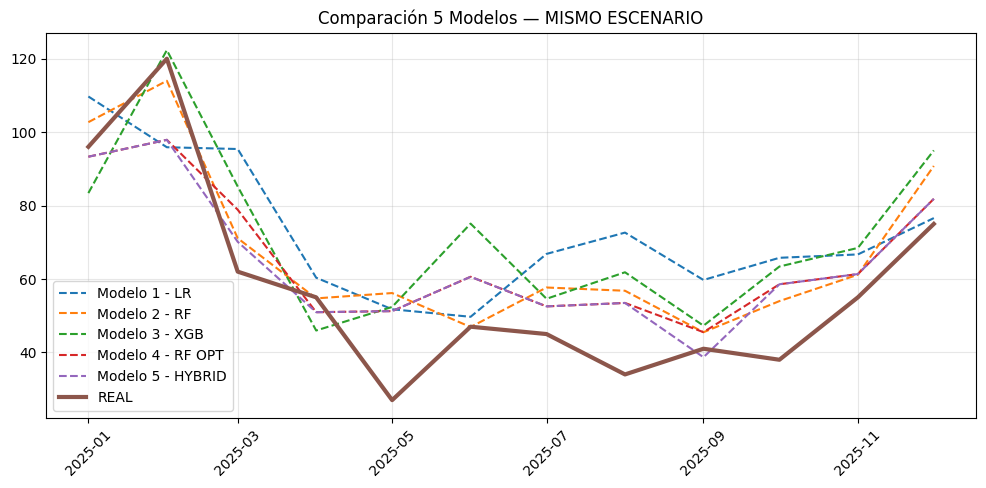

In [352]:
# ---------------------------------------------------------
# VISUALIZACIÓN COMPARATIVA
# ---------------------------------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

for nombre, pred in preds.items():
    plt.plot(test_m4['year_month'], pred, label=nombre, linestyle='--')

# real
plt.plot(test_m4['year_month'], y_true, label='REAL', linewidth=3)

plt.legend()
plt.title("Comparación 5 Modelos — MISMO ESCENARIO")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.show()

# Fase 3 — Aplicacion Modelo Predictivo ChileCompraEficiente.

## Paso 1 — Forecast por organismo (Top 19)

Este análisis tiene como objetivo predecir el comportamiento futuro de las licitaciones de los principales organismos públicos, enfocándose en aquellos con mayor actividad histórica.

A partir de datos históricos, el modelo identifica patrones de comportamiento —como tendencias, estacionalidad y variaciones mensuales— para estimar cuántas licitaciones realizará cada organismo en los próximos 12 meses.

Para lograrlo, se utiliza un enfoque combinado:

* Un modelo de machine learning que aprende de los datos pasados
* Ajustes basados en el comportamiento real de cada organismo

In [353]:
# =========================================================
# PASO 1 — FORECAST POR ORGANISMO (MODELO HÍBRIDO)
# USANDO df_final
# =========================================================

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =========================================================
# 1. CONFIGURACIÓN
# =========================================================

TOP_N = 19
MIN_MESES = 48
HORIZONTE = 12

# =========================================================
# 2. BASE DE TRABAJO (df_final)
# =========================================================

df_org = df_final.copy()
df_org['FechaCierre'] = pd.to_datetime(df_org['FechaCierre'], errors='coerce')
df_org = df_org.dropna(subset=['FechaCierre'])

top_organismos = (
    df_org['codigo_organismo']
    .value_counts()
    .head(TOP_N)
    .index
)

print("Top organismos seleccionados:")
print(list(top_organismos))

# =========================================================
# 3. SERIE MENSUAL COMPLETA
# =========================================================

def construir_serie_mensual(df_input):
    serie = (
        df_input
        .groupby(pd.Grouper(key='FechaCierre', freq='MS'))
        .size()
        .reset_index(name='licitaciones')
        .sort_values('FechaCierre')
    )

    full_range = pd.date_range(
        start=serie['FechaCierre'].min(),
        end=serie['FechaCierre'].max(),
        freq='MS'
    )

    serie = (
        serie.set_index('FechaCierre')
        .reindex(full_range, fill_value=0)
        .rename_axis('FechaCierre')
        .reset_index()
    )

    return serie

# =========================================================
# 4. FEATURE ENGINEERING
# =========================================================

def crear_features(serie):
    serie = serie.copy()

    serie['mes'] = serie['FechaCierre'].dt.month
    serie['anio'] = serie['FechaCierre'].dt.year

    serie['lag_1'] = serie['licitaciones'].shift(1)
    serie['lag_2'] = serie['licitaciones'].shift(2)
    serie['lag_3'] = serie['licitaciones'].shift(3)
    serie['lag_12'] = serie['licitaciones'].shift(12)

    serie['rolling_3'] = serie['licitaciones'].rolling(3).mean()

    return serie.dropna().reset_index(drop=True)

# =========================================================
# 5. MODELADO POR ORGANISMO (HÍBRIDO)
# =========================================================

resultados_eval = []
resultados_forecast = []

for org in top_organismos:

    df_o = df_org[df_org['codigo_organismo'] == org].copy()
    serie = construir_serie_mensual(df_o)

    if len(serie) < MIN_MESES:
        continue

    serie_feat = crear_features(serie)

    if len(serie_feat) < MIN_MESES:
        continue

    train = serie_feat.iloc[:-12].copy()
    test = serie_feat.iloc[-12:].copy()

    X_train = train.drop(columns=['FechaCierre', 'licitaciones'])
    y_train = train['licitaciones']

    X_test = test.drop(columns=['FechaCierre', 'licitaciones'])
    y_test = test['licitaciones']

    # =====================================================
    # MODELO RF OPTIMIZADO
    # =====================================================

    model = RandomForestRegressor(
        n_estimators=500,
        max_depth=8,
        min_samples_split=4,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42
    )

    model.fit(X_train, y_train)

    # =====================================================
    # REGLAS DE NEGOCIO (APRENDIDAS LOCALMENTE)
    # =====================================================

    pred_train = model.predict(X_train)

    df_rules = pd.DataFrame({
        'mes': train['mes'].values,
        'real': y_train.values,
        'pred': pred_train
    })

    df_rules['ratio'] = df_rules['real'] / np.where(df_rules['pred']==0,1,df_rules['pred'])
    df_rules['error_pct'] = np.abs(df_rules['real'] - df_rules['pred']) / df_rules['real'] * 100

    rules = df_rules.groupby('mes').agg(
        mape=('error_pct','mean'),
        factor=('ratio','mean')
    ).reset_index()

    rules['usar'] = rules['mape'] > 20
    rules['factor'] = rules['factor'].clip(0.85,1.15)

    factores = dict(zip(rules['mes'], rules['factor']))
    usar_regla = dict(zip(rules['mes'], rules['usar']))

    # =====================================================
    # PREDICCIÓN TEST (HÍBRIDO)
    # =====================================================

    pred_rf = model.predict(X_test)

    pred = []
    for i in range(len(pred_rf)):
        mes = test.iloc[i]['mes']
        p = pred_rf[i]

        if usar_regla.get(mes, False):
            p = p * factores[mes]

        pred.append(max(p,0))

    pred = np.array(pred)

    # =====================================================
    # MÉTRICAS
    # =====================================================

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mape = np.mean(np.abs((y_test - pred) / np.where(y_test==0,1,y_test))) * 100

    resultados_eval.append({
        'codigo_organismo': org,
        'meses_modelados': len(serie_feat),
        'promedio_test': y_test.mean(),
        'mae': mae,
        'rmse': rmse,
        'mape': mape
    })

    # =====================================================
    # FORECAST FUTURO (HÍBRIDO)
    # =====================================================

    future = serie_feat.copy()

    for i in range(HORIZONTE):

        next_date = future['FechaCierre'].max() + pd.DateOffset(months=1)

        nueva = {
            'FechaCierre': next_date,
            'licitaciones': np.nan,
            'mes': next_date.month,
            'anio': next_date.year,
            'lag_1': future.iloc[-1]['licitaciones'],
            'lag_2': future.iloc[-2]['licitaciones'],
            'lag_3': future.iloc[-3]['licitaciones'],
            'lag_12': future.iloc[-12]['licitaciones'],
            'rolling_3': future.iloc[-3:]['licitaciones'].mean()
        }

        X_new = pd.DataFrame([{
            'mes': nueva['mes'],
            'anio': nueva['anio'],
            'lag_1': nueva['lag_1'],
            'lag_2': nueva['lag_2'],
            'lag_3': nueva['lag_3'],
            'lag_12': nueva['lag_12'],
            'rolling_3': nueva['rolling_3']
        }])

        pred_new = model.predict(X_new)[0]

        if usar_regla.get(nueva['mes'], False):
            pred_new = pred_new * factores[nueva['mes']]

        pred_new = max(pred_new, 0)
        nueva['licitaciones'] = pred_new

        future = pd.concat([future, pd.DataFrame([nueva])], ignore_index=True)

    forecast_org = future.tail(HORIZONTE)[['FechaCierre','licitaciones']]
    forecast_org['codigo_organismo'] = org

    resultados_forecast.append(forecast_org)

# =========================================================
# 7. RESULTADOS CONSOLIDADOS
# =========================================================

df_resultados_eval = pd.DataFrame(resultados_eval).sort_values(['mape','mae'])
df_resultados_forecast = pd.concat(resultados_forecast, ignore_index=True)

print("\nEVALUACIÓN ORGANISMOS")
display(df_resultados_eval)

print("\nFORECAST FUTURO")
display(df_resultados_forecast.head())

# =========================================================
# 8. TOP ORGANISMOS MÁS PREDECIBLES
# =========================================================

df_top_predecibles = df_resultados_eval.head(10)
display(df_top_predecibles)

# =========================================================
# 9. TOP ORGANISMOS CON MAYOR ACTIVIDAD FUTURA
# =========================================================

df_resumen_forecast = (
    df_resultados_forecast
    .groupby('codigo_organismo', as_index=False)['licitaciones']
    .sum()
    .rename(columns={'licitaciones': 'forecast_12m'})
    .sort_values('forecast_12m', ascending=False)
)

display(df_resumen_forecast.head(10))

Top organismos seleccionados:
['3656', '3794', '1660', '3863', '4809', '1247197', '979', '3709', '3510', '1509', '2196', '3589', '3960', '3928', '4857', '1057503', '3508', '2564', '2342']

EVALUACIÓN ORGANISMOS


,codigo_organismo,meses_modelados,promedio_test,mae,rmse,mape
0,3656,60,8.333333,2.875786,5.705817,36.180748
2,1660,60,3.250000,1.238250,1.538661,43.383214
15,3508,60,2.416667,0.977536,1.261706,44.644780
1,3794,60,6.166667,2.543355,3.572112,58.222101
4,4809,59,2.833333,1.464158,1.887255,59.158717
5,979,58,3.500000,1.270392,1.611013,63.594046
11,3960,60,1.583333,1.307633,1.909612,66.760316
17,2342,60,2.666667,1.807196,2.685847,72.672883
13,4857,59,2.250000,1.253251,1.800301,74.078153
16,2564,60,1.583333,1.313182,1.677626,82.216253



FORECAST FUTURO


,FechaCierre,licitaciones,codigo_organismo
0,2026-01-01,16.892507,3656
1,2026-02-01,10.519872,3656
2,2026-03-01,9.143440,3656
3,2026-04-01,6.633453,3656
4,2026-05-01,7.401830,3656


,codigo_organismo,meses_modelados,promedio_test,mae,rmse,mape
0,3656,60,8.333333,2.875786,5.705817,36.180748
2,1660,60,3.250000,1.238250,1.538661,43.383214
15,3508,60,2.416667,0.977536,1.261706,44.644780
1,3794,60,6.166667,2.543355,3.572112,58.222101
4,4809,59,2.833333,1.464158,1.887255,59.158717
5,979,58,3.500000,1.270392,1.611013,63.594046
11,3960,60,1.583333,1.307633,1.909612,66.760316
17,2342,60,2.666667,1.807196,2.685847,72.672883
13,4857,59,2.250000,1.253251,1.800301,74.078153
16,2564,60,1.583333,1.313182,1.677626,82.216253


,codigo_organismo,forecast_12m
9,3656,97.865488
7,3510,50.789876
0,1057503,47.614925
11,3794,42.538734
1,1509,37.373799
2,1660,35.135450
12,3863,34.778668
17,979,32.811843
10,3709,32.115910
15,4809,29.628324


El análisis permite identificar con bastante claridad qué organismos generarán más oportunidades de licitaciones en los próximos 12 meses, así como el nivel de confianza que podemos tener en esas proyecciones.

En primer lugar, se observa que algunos organismos presentan un comportamiento más estable y predecible. Por ejemplo, el organismo 3656 destaca no solo por su alto volumen proyectado (cerca de 98 licitaciones en el año), sino también por tener el menor nivel de error dentro del grupo. Esto lo convierte en un candidato claro para priorizar esfuerzos comerciales, ya que combina volumen y cierta estabilidad en su comportamiento.

En segundo lugar, hay organismos con un volumen relevante proyectado, como 3510, 1057503 y 3794, que también representan oportunidades importantes. Sin embargo, en estos casos la precisión del modelo es menor, lo que indica que su comportamiento es más variable. En términos comerciales, esto significa que siguen siendo atractivos, pero requieren un seguimiento más dinámico.

Por otro lado, existen organismos con menor volumen o con alta variabilidad (errores más altos), donde las proyecciones son menos confiables. En estos casos, el forecast debe tomarse como una referencia general más que como una estimación precisa.

## Paso 2 — EVALUACIÓN (FORECAST POR ORGANISMO)

Este paso del análisis tiene como objetivo evaluar la calidad de las predicciones realizadas anteriormente y, a partir de eso, identificar cuáles organismos realmente representan oportunidades comerciales confiables.

No todos los resultados del modelo tienen el mismo nivel de precisión. Por eso, en esta etapa se filtran y analizan los organismos considerando no solo cuánto se proyecta que liciten, sino también qué tan confiables son esas proyecciones.

In [354]:
# =========================================================
# PASO 2 — EVALUACIÓN FINAL (CORREGIDO)
# =========================================================

print("\n" + "="*80)
print("1) MÉTRICAS GENERALES POR ORGANISMO")
print("="*80)

display(df_resultados_eval)

# =========================================================
# 2) FILTRO ORGANISMOS VIABLES (CORREGIDO)
# =========================================================

# Criterio robusto (NO solo MAPE)
UMBRAL_MAE = 2.5
UMBRAL_MAPE = 120

df_filtrado = df_resultados_eval[
    (df_resultados_eval['mae'] < UMBRAL_MAE) &
    (df_resultados_eval['mape'] < UMBRAL_MAPE)
].copy()

print("\n" + "="*80)
print("2) ORGANISMOS VIABLES (CRITERIO CORREGIDO)")
print("="*80)

display(df_filtrado)

# =========================================================
# 3) TOP ORGANISMOS MÁS PREDECIBLES
# =========================================================

print("\n" + "="*80)
print("3) TOP ORGANISMOS MÁS PREDECIBLES")
print("="*80)

df_top_predecibles = df_filtrado.sort_values(['mae','mape']).head(10)
display(df_top_predecibles)

# =========================================================
# 4) FORECAST AGREGADO
# =========================================================

print("\n" + "="*80)
print("4) TOP ORGANISMOS CON MAYOR ACTIVIDAD PROYECTADA (12M)")
print("="*80)

df_resumen_forecast = (
    df_resultados_forecast
    .groupby('codigo_organismo', as_index=False)['licitaciones']
    .sum()
    .rename(columns={'licitaciones': 'forecast_12m'})
)

df_resumen_forecast = df_resumen_forecast.sort_values('forecast_12m', ascending=False)

display(df_resumen_forecast.head(10))

# =========================================================
# 5) ANÁLISIS GLOBAL
# =========================================================

print("\n" + "="*80)
print("5) ANÁLISIS GLOBAL DEL MODELO")
print("="*80)

print("MAPE promedio:", round(df_resultados_eval['mape'].mean(),2))
print("MAPE mediano :", round(df_resultados_eval['mape'].median(),2))
print("MAE promedio :", round(df_resultados_eval['mae'].mean(),2))

# =========================================================
# 6) SEGMENTACIÓN DE CALIDAD
# =========================================================

print("\n" + "="*80)
print("6) SEGMENTACIÓN DE ORGANISMOS")
print("="*80)

df_resultados_eval['segmento'] = pd.cut(
    df_resultados_eval['mae'],
    bins=[0, 1, 2, 3, 10],
    labels=[
        'Excelente (🔥)',
        'Bueno (🟢)',
        'Regular (🟡)',
        'Malo (🔴)'
    ]
)

display(
    df_resultados_eval[['codigo_organismo','mae','mape','segmento']]
    .sort_values('mae')
)

# =========================================================
# 7) OPORTUNIDADES DE NEGOCIO (MEJORADO)
# =========================================================

print("\n" + "="*80)
print("7) OPORTUNIDADES DE NEGOCIO")
print("="*80)

df_oportunidades = df_filtrado.merge(
    df_resumen_forecast,
    on='codigo_organismo',
    how='left'
)

# normalización robusta
df_oportunidades['score_pred'] = 1 / (df_oportunidades['mae'] + 1)
df_oportunidades['score_vol'] = df_oportunidades['forecast_12m'] / df_oportunidades['forecast_12m'].max()
df_oportunidades['score_estabilidad'] = 1 / (df_oportunidades['rmse'] + 1)

# score final
df_oportunidades['score'] = (
    0.5 * df_oportunidades['score_pred'] +
    0.3 * df_oportunidades['score_vol'] +
    0.2 * df_oportunidades['score_estabilidad']
)

df_oportunidades = df_oportunidades.sort_values('score', ascending=False)

display(df_oportunidades.head(10))

# =========================================================
# 8) TOP ORGANISMOS REALMENTE ATRACTIVOS
# =========================================================

print("\n" + "="*80)
print("8) TOP ORGANISMOS (ALTO VALOR REAL)")
print("="*80)

df_top_real = df_oportunidades.head(10)
display(df_top_real)


1) MÉTRICAS GENERALES POR ORGANISMO


,codigo_organismo,meses_modelados,promedio_test,mae,rmse,mape
0,3656,60,8.333333,2.875786,5.705817,36.180748
2,1660,60,3.250000,1.238250,1.538661,43.383214
15,3508,60,2.416667,0.977536,1.261706,44.644780
1,3794,60,6.166667,2.543355,3.572112,58.222101
4,4809,59,2.833333,1.464158,1.887255,59.158717
5,979,58,3.500000,1.270392,1.611013,63.594046
11,3960,60,1.583333,1.307633,1.909612,66.760316
17,2342,60,2.666667,1.807196,2.685847,72.672883
13,4857,59,2.250000,1.253251,1.800301,74.078153
16,2564,60,1.583333,1.313182,1.677626,82.216253



2) ORGANISMOS VIABLES (CRITERIO CORREGIDO)


,codigo_organismo,meses_modelados,promedio_test,mae,rmse,mape
2,1660,60,3.250000,1.238250,1.538661,43.383214
15,3508,60,2.416667,0.977536,1.261706,44.644780
4,4809,59,2.833333,1.464158,1.887255,59.158717
5,979,58,3.500000,1.270392,1.611013,63.594046
11,3960,60,1.583333,1.307633,1.909612,66.760316
17,2342,60,2.666667,1.807196,2.685847,72.672883
13,4857,59,2.250000,1.253251,1.800301,74.078153
16,2564,60,1.583333,1.313182,1.677626,82.216253
9,2196,58,2.833333,2.186688,3.393707,114.819671



3) TOP ORGANISMOS MÁS PREDECIBLES


...

,codigo_organismo,mae,mape,segmento
15,3508,0.977536,44.644780,Excelente (🔥)
2,1660,1.238250,43.383214,Bueno (🟢)
13,4857,1.253251,74.078153,Bueno (🟢)
5,979,1.270392,63.594046,Bueno (🟢)
11,3960,1.307633,66.760316,Bueno (🟢)
16,2564,1.313182,82.216253,Bueno (🟢)
4,4809,1.464158,59.158717,Bueno (🟢)
17,2342,1.807196,72.672883,Bueno (🟢)
12,3928,1.853607,130.576134,Bueno (🟢)
3,3863,2.048411,184.347443,Regular (🟡)



7) OPORTUNIDADES DE NEGOCIO


,codigo_organismo,meses_modelados,promedio_test,mae,rmse,mape,forecast_12m,score_pred,score_vol,score_estabilidad,score
0,1660,60,3.250000,1.238250,1.538661,43.383214,35.135450,0.446778,1.000000,0.393908,0.602170
3,979,58,3.500000,1.270392,1.611013,63.594046,32.811843,0.440453,0.933867,0.382993,0.576985
1,3508,60,2.416667,0.977536,1.261706,44.644780,23.135884,0.505680,0.658477,0.442144,0.538812
2,4809,59,2.833333,1.464158,1.887255,59.158717,29.628324,0.405818,0.843260,0.346350,0.525157
4,3960,60,1.583333,1.307633,1.909612,66.760316,27.658240,0.433344,0.787189,0.343688,0.521567
6,4857,59,2.250000,1.253251,1.800301,74.078153,23.339113,0.443803,0.664261,0.357104,0.492601
7,2564,60,1.583333,1.313182,1.677626,82.216253,21.425504,0.432305,0.609797,0.373465,0.473785
5,2342,60,2.666667,1.807196,2.685847,72.672883,24.745769,0.356227,0.704296,0.271308,0.443664
8,2196,58,2.833333,2.186688,3.393707,114.819671,28.167384,0.313805,0.801680,0.227598,0.442926



8) TOP ORGANISMOS (ALTO VALOR REAL)


,codigo_organismo,meses_modelados,promedio_test,mae,rmse,mape,forecast_12m,score_pred,score_vol,score_estabilidad,score
0,1660,60,3.250000,1.238250,1.538661,43.383214,35.135450,0.446778,1.000000,0.393908,0.602170
3,979,58,3.500000,1.270392,1.611013,63.594046,32.811843,0.440453,0.933867,0.382993,0.576985
1,3508,60,2.416667,0.977536,1.261706,44.644780,23.135884,0.505680,0.658477,0.442144,0.538812
2,4809,59,2.833333,1.464158,1.887255,59.158717,29.628324,0.405818,0.843260,0.346350,0.525157
4,3960,60,1.583333,1.307633,1.909612,66.760316,27.658240,0.433344,0.787189,0.343688,0.521567
6,4857,59,2.250000,1.253251,1.800301,74.078153,23.339113,0.443803,0.664261,0.357104,0.492601
7,2564,60,1.583333,1.313182,1.677626,82.216253,21.425504,0.432305,0.609797,0.373465,0.473785
5,2342,60,2.666667,1.807196,2.685847,72.672883,24.745769,0.356227,0.704296,0.271308,0.443664
8,2196,58,2.833333,2.186688,3.393707,114.819671,28.167384,0.313805,0.801680,0.227598,0.442926


Al combinar tres factores clave —precisión, volumen y estabilidad— se obtiene un ranking más estratégico. Bajo este enfoque, destacan organismos como:

* 1660 y 979, que combinan buen volumen proyectado con alta confiabilidad
* 3508, que presenta el mejor nivel de precisión del modelo
* 4809 y 3960, que mantienen un buen equilibrio entre actividad y estabilidad

Estos organismos representan las mejores oportunidades comerciales reales, ya que permiten anticipar su comportamiento con mayor seguridad.

## Paso 3 - ChileCompraEficiente / MÓDULO COMERCIAL.

En el paso anterior se realizó una evaluación del modelo, donde se identificaron qué organismos eran más predecibles y cuáles combinaban mejor volumen y confiabilidad. Ese análisis permitió entender la calidad de las proyecciones y generar un primer ranking estratégico.

Este nuevo paso va un nivel más allá. Aquí el objetivo es convertir esos resultados en decisiones comerciales concretas y se construye un ranking directamente orientado a negocio, priorizando dónde actuar.



In [355]:
# =========================================================
# PASO 3 — ChileCompraEficiente / MÓDULO COMERCIAL (CORREGIDO)
# =========================================================

import pandas as pd
import numpy as np

# =========================================================
# 1. FILTRO ORGANISMOS VIABLES (CORREGIDO)
# =========================================================

UMBRAL_MAE = 2.5
UMBRAL_MAPE = 120

df_productivo = df_resultados_eval[
    (df_resultados_eval['mae'] < UMBRAL_MAE) &
    (df_resultados_eval['mape'] < UMBRAL_MAPE)
].copy()

print("\n" + "="*80)
print("1) ORGANISMOS VIABLES (CRITERIO REALISTA)")
print("="*80)
display(df_productivo)

# =========================================================
# 2. UNIR CON FORECAST
# =========================================================

df_forecast_resumen = (
    df_resultados_forecast
    .groupby('codigo_organismo', as_index=False)['licitaciones']
    .sum()
    .rename(columns={'licitaciones': 'forecast_12m'})
)

df_comercial = df_productivo.merge(
    df_forecast_resumen,
    on='codigo_organismo',
    how='left'
)

# =========================================================
# 3. SCORE COMERCIAL (MEJORADO)
# =========================================================

# Ahora basado en MAE (no MAPE)
df_comercial['score_pred'] = 1 / (df_comercial['mae'] + 1)
df_comercial['score_vol'] = df_comercial['forecast_12m'] / df_comercial['forecast_12m'].max()
df_comercial['score_estabilidad'] = 1 / (df_comercial['rmse'] + 1)

df_comercial['score_final'] = (
    0.5 * df_comercial['score_pred'] +
    0.3 * df_comercial['score_vol'] +
    0.2 * df_comercial['score_estabilidad']
)

df_comercial = df_comercial.sort_values('score_final', ascending=False)

print("\n" + "="*80)
print("2) RANKING COMERCIAL ChileCompraEficiente")
print("="*80)
display(df_comercial)

# =========================================================
# 4. TOP ORGANISMOS PARA NEGOCIO
# =========================================================

TOP_K = 10

df_top_clientes = df_comercial.head(TOP_K).copy()

print("\n" + "="*80)
print("3) TOP ORGANISMOS (CLIENTES OBJETIVO)")
print("="*80)
display(df_top_clientes)

# =========================================================
# 5. SEGMENTACIÓN COMERCIAL
# =========================================================

df_top_clientes['segmento'] = pd.cut(
    df_top_clientes['score_final'],
    bins=[0, 0.3, 0.6, 1],
    labels=[
        'Bajo valor',
        'Medio valor',
        'Alto valor 🔥'
    ]
)

print("\n" + "="*80)
print("4) SEGMENTACIÓN COMERCIAL")
print("="*80)
display(df_top_clientes[['codigo_organismo','score_final','segmento']])

# =========================================================
# 6. FORECAST PRODUCTIVO
# =========================================================

df_forecast_productivo = df_resultados_forecast[
    df_resultados_forecast['codigo_organismo'].isin(df_productivo['codigo_organismo'])
].copy()

print("\n" + "="*80)
print("5) FORECAST PRODUCTIVO")
print("="*80)
display(df_forecast_productivo.head(20))

# =========================================================
# 7. ALERTAS DE CRECIMIENTO (MEJORADO)
# =========================================================

df_alertas = df_forecast_productivo.copy()

df_alertas = (
    df_alertas
    .sort_values(['codigo_organismo','FechaCierre'])
    .groupby('codigo_organismo')
    .apply(lambda x: x.assign(
        crecimiento = x['licitaciones'].pct_change()
    ))
    .reset_index(drop=True)
)

# 🔥 umbral más realista
df_alertas = df_alertas[df_alertas['crecimiento'] > 0.25]

print("\n" + "="*80)
print("6) ALERTAS DE CRECIMIENTO (OPORTUNIDADES)")
print("="*80)
display(df_alertas.head(20))


1) ORGANISMOS VIABLES (CRITERIO REALISTA)


,codigo_organismo,meses_modelados,promedio_test,mae,rmse,mape,segmento
2,1660,60,3.250000,1.238250,1.538661,43.383214,Bueno (🟢)
15,3508,60,2.416667,0.977536,1.261706,44.644780,Excelente (🔥)
4,4809,59,2.833333,1.464158,1.887255,59.158717,Bueno (🟢)
5,979,58,3.500000,1.270392,1.611013,63.594046,Bueno (🟢)
11,3960,60,1.583333,1.307633,1.909612,66.760316,Bueno (🟢)
17,2342,60,2.666667,1.807196,2.685847,72.672883,Bueno (🟢)
13,4857,59,2.250000,1.253251,1.800301,74.078153,Bueno (🟢)
16,2564,60,1.583333,1.313182,1.677626,82.216253,Bueno (🟢)
9,2196,58,2.833333,2.186688,3.393707,114.819671,Regular (🟡)



2) RANKING COMERCIAL ChileCompraEficiente


,codigo_organismo,meses_modelados,promedio_test,mae,rmse,mape,segmento,forecast_12m,score_pred,score_vol,score_estabilidad,score_final
0,1660,60,3.250000,1.238250,1.538661,43.383214,Bueno (🟢),35.135450,0.446778,1.000000,0.393908,0.602170
3,979,58,3.500000,1.270392,1.611013,63.594046,Bueno (🟢),32.811843,0.440453,0.933867,0.382993,0.576985
1,3508,60,2.416667,0.977536,1.261706,44.644780,Excelente (🔥),23.135884,0.505680,0.658477,0.442144,0.538812
2,4809,59,2.833333,1.464158,1.887255,59.158717,Bueno (🟢),29.628324,0.405818,0.843260,0.346350,0.525157
4,3960,60,1.583333,1.307633,1.909612,66.760316,Bueno (🟢),27.658240,0.433344,0.787189,0.343688,0.521567
6,4857,59,2.250000,1.253251,1.800301,74.078153,Bueno (🟢),23.339113,0.443803,0.664261,0.357104,0.492601
7,2564,60,1.583333,1.313182,1.677626,82.216253,Bueno (🟢),21.425504,0.432305,0.609797,0.373465,0.473785
5,2342,60,2.666667,1.807196,2.685847,72.672883,Bueno (🟢),24.745769,0.356227,0.704296,0.271308,0.443664
8,2196,58,2.833333,2.186688,3.393707,114.819671,Regular (🟡),28.167384,0.313805,0.801680,0.227598,0.442926



3) TOP ORGANISMOS (CLIENTES OBJETIVO)


...


5) FORECAST PRODUCTIVO


,FechaCierre,licitaciones,codigo_organismo
24,2026-01-01,3.303548,1660
25,2026-02-01,2.486552,1660
26,2026-03-01,2.690452,1660
27,2026-04-01,3.978212,1660
28,2026-05-01,1.789363,1660
29,2026-06-01,1.926672,1660
30,2026-07-01,2.151660,1660
31,2026-08-01,2.748866,1660
32,2026-09-01,2.190626,1660
33,2026-10-01,1.552411,1660



6) ALERTAS DE CRECIMIENTO (OPORTUNIDADES)


/tmp/ipykernel_118711/3193908954.py:119: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.assign(


,FechaCierre,licitaciones,codigo_organismo,crecimiento
3,2026-04-01,3.978212,1660,0.478641
7,2026-08-01,2.748866,1660,0.277556
10,2026-11-01,2.289014,1660,0.474489
11,2026-12-01,8.028073,1660,2.507220
18,2026-06-01,3.486374,2196,0.696260
27,2026-04-01,2.328829,2342,0.300924
44,2026-09-01,1.722791,2564,0.337378
47,2026-12-01,4.250761,2564,2.214813
57,2026-10-01,1.549861,3508,0.777291
59,2026-12-01,1.914275,3508,0.625548


### VERIFICANDO LOS NOMBRES Y REGIONES DE LOS ORGANISMOS TOP

In [358]:
# ================================
# 1. PREPARAR CLAVES
# ================================
df_top_clientes['codigo_organismo'] = df_top_clientes['codigo_organismo'].astype(str).str.strip()
df_final['codigo_organismo'] = df_final['codigo_organismo'].astype(str).str.strip()

# ================================
# 2. CREAR TABLA MAESTRA LIMPIA
# ================================
df_maestra = df_final[
    ['codigo_organismo', 'nombre_organismo', 'region_unidad']
].drop_duplicates()

# ================================
# 3. CRUCE FINAL
# ================================
df_top_con_nombres = df_top_clientes.merge(
    df_maestra,
    on='codigo_organismo',
    how='left'
)

# ================================
# 4. ORDENAR (YA VIENE ORDENADO, PERO ASEGURAMOS)
# ================================
df_top_con_nombres = df_top_con_nombres.sort_values('score_final', ascending=False)

# ================================
# 5. SELECCIÓN FINAL (CUADRO TOP)
# ================================
df_top_con_nombres = df_top_con_nombres[
    [
        'codigo_organismo',
        'nombre_organismo',
        'region_unidad',
        'forecast_12m',
        'score_final',
        'mae',
        'rmse',
        'mape',
        'segmento'
    ]
]

# ================================
# 6. RESULTADO
# ================================
display(df_top_con_nombres)

,codigo_organismo,nombre_organismo,region_unidad,forecast_12m,score_final,mae,rmse,mape,segmento
0,1660,SERVICIO SALUD COQUIMBO HOSP DE SALAMANC,Región de Coquimbo,35.135450,0.602170,1.238250,1.538661,43.383214,Alto valor 🔥
1,979,MINISTERIO DE OBRAS PUBLICAS DIREC CION GRAL D...,Región RM,32.811843,0.576985,1.270392,1.611013,63.594046,Medio valor
2,3508,I MUNICIPALIDAD DE CHONCHI,Región de los Lagos,23.135884,0.538812,0.977536,1.261706,44.644780,Medio valor
3,4809,MINISTERIO DE OBRAS PUBLICAS DIREC CION GRAL D...,Región de la Araucanía,29.628324,0.525157,1.464158,1.887255,59.158717,Medio valor
4,3960,I MUNICIPALIDAD DE HUALANE,Región del Maule,27.658240,0.521567,1.307633,1.909612,66.760316,Medio valor
5,4857,I MUNICIPALIDAD DE TIRUA,Región del Biobío,23.339113,0.492601,1.253251,1.800301,74.078153,Medio valor
6,2564,I MUNICIPALIDAD DE CHEPICA,Región del Libertador General Bernardo O´Higgins,21.425504,0.473785,1.313182,1.677626,82.216253,Medio valor
7,2342,I MUNICIPALIDAD DE SAN BERNARDO,Región RM,24.745769,0.443664,1.807196,2.685847,72.672883,Medio valor
8,2196,Hospital Psiquiátrico El Peral,Región RM,28.167384,0.442926,2.186688,3.393707,114.819671,Medio valor


Estos últimos resultados permiten pasar de una visión general a una priorización concreta y accionable, identificando un grupo reducido de organismos donde las predicciones son confiables y, por tanto, útiles para la toma de decisiones. Dentro de este grupo, destacan los organismos en el siguiente orden:

* 1660 (SERVICIO SALUD COQUIMBO HOSPITAL DE SALAMANCA) como la principal oportunidad, al combinar alto volumen proyectado con buena precisión.

* 979 (MINISTERIO DE OBRAS PUBLICAS DIRECCIÓN GRAL DE OO PP DCYF - REGION METROPOLITANA DE SANTIAGO)

* 3508 (I MUNICIPALIDAD DE CHONCHI)

* 4809 (MINISTERIO DE OBRAS PUBLICAS DIRECCIÓN GRAL DE OO PP DCYF - REGION DE LA ARAUCANIA)

* 3960 (I MUNICIPALIDAD DE HUALANE)

Estos cuatro últimos que también presentan un equilibrio relevante entre actividad y estabilidad. A diferencia de un enfoque basado solo en volumen, este modelo prioriza valor real incorporando precisión y consistencia, lo que permite enfocar esfuerzos comerciales con mayor certeza. Además, el análisis no solo indica dónde actuar, sino también cuándo, al detectar meses con aumentos significativos en la actividad, facilitando una planificación más estratégica. En conjunto, se obtiene un ranking claro de clientes objetivo y una identificación de momentos clave, permitiendo optimizar recursos y aumentar la efectividad comercial con base en información más confiable.


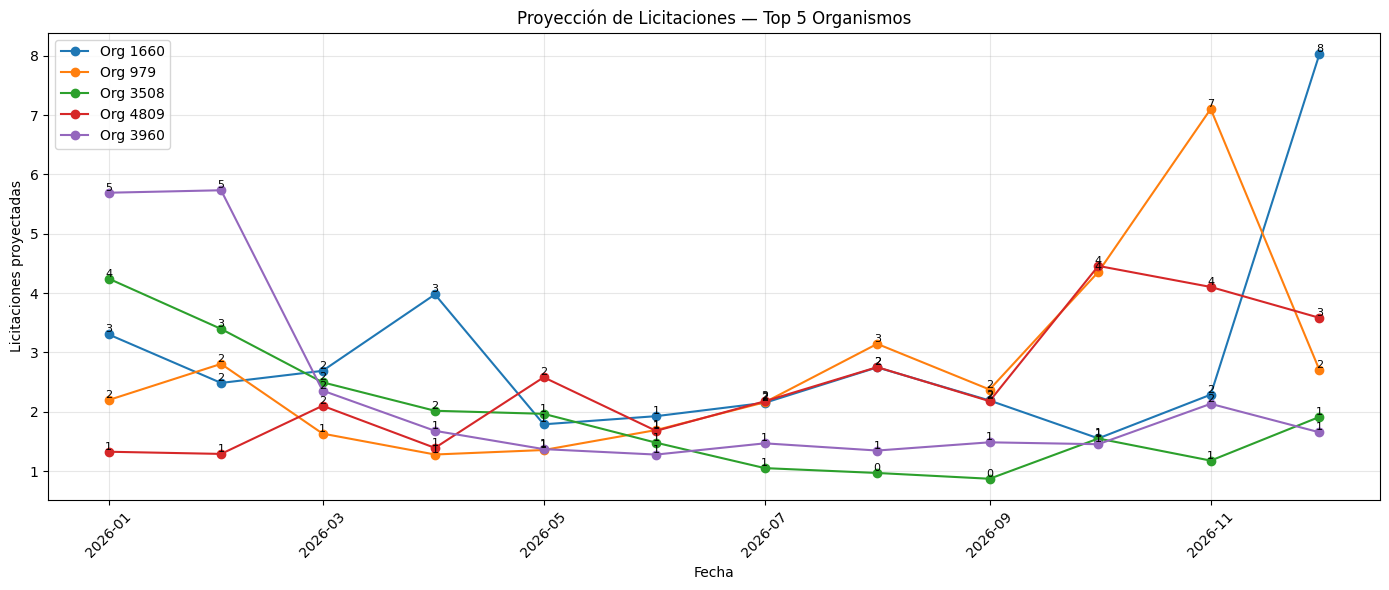

In [359]:
# =========================================================
# GRÁFICO — PROYECCIÓN LICITACIONES (TOP 5 ORGANISMOS)
# =========================================================

import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. SELECCIONAR TOP 5
# ---------------------------------------------------------

top5 = df_top_clientes['codigo_organismo'].head(5).tolist()

df_plot = df_forecast_productivo[
    df_forecast_productivo['codigo_organismo'].isin(top5)
].copy()

# ---------------------------------------------------------
# 2. GRAFICAR
# ---------------------------------------------------------

plt.figure(figsize=(14,6))

for org in top5:

    df_o = df_plot[df_plot['codigo_organismo'] == org]

    plt.plot(
        df_o['FechaCierre'],
        df_o['licitaciones'],
        marker='o',
        label=f'Org {org}'
    )

    # valores encima
    for x, y in zip(df_o['FechaCierre'], df_o['licitaciones']):
        plt.text(x, y, f'{int(y)}', fontsize=8, ha='center', va='bottom')

# ---------------------------------------------------------
# 3. ESTÉTICA
# ---------------------------------------------------------

plt.title("Proyección de Licitaciones — Top 5 Organismos")
plt.xlabel("Fecha")
plt.ylabel("Licitaciones proyectadas")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()